# Matching

The purpose of this file is to do one set of matching: **treatment matching**, to match those who graduated from the program against those that did not graduate from the program. 

We will match to examine the following:

-Graduation effect for **earnings** (income)

-Graduation effect for **employment**

-Graduation effect for **criminal justice interaction** (as measured by arrests)

-Graduation effect for **recidivism** (as measured by offenses)

This will be followed (in future analysis) by intent to treat matching of TIP participants with similar non-participants, which we expect will be particularly relevant for criminal justice and recidivism outcomes. 


# Preparation

In [1]:
#Import necessary packages

import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import tqdm
##!pip install linearmodels
from linearmodels import PanelOLS
import statsmodels.api as sm
from statsmodels.genmod.generalized_estimating_equations import GEE
from statsmodels.genmod.families import Binomial
from statsmodels.genmod.cov_struct import Exchangeable

In [2]:
#Import necessary files

#Student datafile, data up to December 2025 
tip_clean = pd.read_csv(r'TIP_clean.csv', parse_dates=['CreatedDate','DoB', 'Interviewed Only Date', 'InterviewedDate','StartDate','EndDate'])

#Demographic datafile, data up to December 2024
tip_demos = pd.read_csv(r'tip_cohort_demographics_rg.csv')

#Sentencing datafile, data up to December 2024
tip_sentencing = pd.read_csv(r'convictions_matched_to_tip_final.csv', parse_dates = ['DOB', 'GraduatedDate', 'InterviewedDate', 'StartDate','EndDate', 'DOF', 'DOS'])

#Arrests datafile, data up to December 2024
tip_arrests = pd.read_csv(r'arrest_data.csv', parse_dates = ['CaseFiledDate', 'ArrestDate', 'DefendantDOB', 'OffenseDate','OffenseDispositionDate','CaseDispositionDate','InterviewedDate','Orientation Date', 'GraduatedDate', 'CreatedDate','StartDate','EndDate'])

#Earnings datafile, data up to December 2024
tip_earnings = pd.read_csv(r'tip_cohort_uiearnings.csv')

#Deflation information to deflate earnings data
df_inflation = pd.read_csv(r'inflation_data.csv')

#DHS datafile for non-participants
df_dhs = pd.read_csv(r'DHS_demographics.csv')

#full_pcs data
full_pcs = pd.read_csv(r'full_pcs.txt')

#full_earnings data
full_earnings = pd.read_csv(r'ui_earnings.txt')

C:\Users\13429\AppData\Local\Temp\ipykernel_27752\2219236522.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  tip_arrests = pd.read_csv(r'arrest_data.csv', parse_dates = ['CaseFiledDate', 'ArrestDate', 'DefendantDOB', 'OffenseDate','OffenseDispositionDate','CaseDispositionDate','InterviewedDate','Orientation Date', 'GraduatedDate', 'CreatedDate','StartDate','EndDate'])
C:\Users\13429\AppData\Local\Temp\ipykernel_27752\2219236522.py:16: DtypeWarning: Columns (3,6,7,8,9,10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  tip_earnings = pd.read_csv(r'tip_cohort_uiearnings.csv')
C:\Users\13429\AppData\Local\Temp\ipykernel_27752\2219236522.py:25: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  full_pcs = pd.read_csv(r'full_pcs.txt')
C:\Users\13429\AppData\Local\Te

In [3]:
#Clean student datafile column names

all_tip_students = tip_clean.rename(columns={
    'participant_id' : 'tip_id',
    'DoB' : 'DOB',
    'Status' : 'tip_status',
})

all_tip_students.drop(columns=['Unnamed: 25', 'Unnamed: 26'], inplace=True)

#Define statuses as "Graduated" or "Non Graduated" - for the purposes of this matched analysis, we do not care about individuals who do not fall into these statuses

def status(row):
    ts = str(row['tip_status'])
    if ("Graduate" in ts) or ("DNF" in ts and "Orientation" not in ts):
        return 'Participant'
    else:
        return 'Non Participant'

all_tip_students['Status'] = all_tip_students.apply(status, axis=1)
all_tip_students.Status.value_counts()

Status
Participant        1442
Non Participant    1281
Name: count, dtype: int64

In [4]:
# Clean tip_sentencing datafile column names and status
tip_sentencing = tip_sentencing.rename(columns={
    'PCS_OFF_ID': 'pcs_off_id',
    'Status': 'tip_status'
})
tip_sentencing['Status'] = tip_sentencing.apply(status, axis=1)

In [5]:
# -----------------------------
# 1. Create df_participant
# -----------------------------
df_participant = all_tip_students[all_tip_students["Status"] == "Participant"].copy()

# Optional: if you also want the non-participant students from all_tip_students itself
df_non_participant_students = all_tip_students[all_tip_students["Status"] == "Non Participant"].copy()


# -----------------------------
# 2. Check unique non-null pcs_off_id in tip_sentencing
# -----------------------------
tip_pcs_ids = tip_sentencing["pcs_off_id"].dropna().unique()

print("Number of unique non-null pcs_off_id in tip_sentencing:", len(tip_pcs_ids))


# -----------------------------
# 3. Check whether these pcs_off_id have corresponding tip_id
#    (row-level check within tip_sentencing)
# -----------------------------
pcs_tip_check = (
    tip_sentencing.loc[tip_sentencing["pcs_off_id"].notna(), ["pcs_off_id", "tip_id"]]
    .drop_duplicates()
)

# pcs_off_id with at least one non-null tip_id
pcs_with_tip_id = pcs_tip_check.loc[pcs_tip_check["tip_id"].notna(), "pcs_off_id"].unique()

# pcs_off_id that appear but do NOT have any valid tip_id
pcs_without_tip_id = set(tip_pcs_ids) - set(pcs_with_tip_id)

print("Number of unique pcs_off_id with at least one corresponding non-null tip_id:", len(pcs_with_tip_id))
print("Number of unique pcs_off_id without a corresponding non-null tip_id:", len(pcs_without_tip_id))

if len(pcs_without_tip_id) > 0:
    print("pcs_off_id without corresponding tip_id:")
    print(pcs_without_tip_id)
else:
    print("All unique non-null pcs_off_id in tip_sentencing have at least one corresponding non-null tip_id.")


# -----------------------------
# 4. Remove from df_dhs all pcs_off_id that appear in tip_sentencing
#    and create df_non_participant, keep only unique pcs_off_id in df_non_participant
# -----------------------------
df_non_participant = df_dhs[~df_dhs["pcs_off_id"].isin(tip_pcs_ids)].copy()
df_non_participant.drop_duplicates(subset=["pcs_off_id"], inplace=True)

print("Original df_dhs shape:", df_dhs.shape)
print("df_non_participant shape:", df_non_participant.shape)

Number of unique non-null pcs_off_id in tip_sentencing: 1480
Number of unique pcs_off_id with at least one corresponding non-null tip_id: 1480
Number of unique pcs_off_id without a corresponding non-null tip_id: 0
All unique non-null pcs_off_id in tip_sentencing have at least one corresponding non-null tip_id.
Original df_dhs shape: (126232, 6)
df_non_participant shape: (123434, 6)


In [6]:
date_cols = ['DOB', 'StartDate', 'EndDate', 'InterviewedDate', 'Interviewed Only Date']
for col in date_cols:
    if col in df_participant.columns:
        df_participant[col] = pd.to_datetime(df_participant[col], errors = 'coerce')

#Keep only participants with startdate between 2018-01-01 and 2024-09-30
df_participant = df_participant[
    (df_participant['StartDate'] >= '2018-01-01') &
    (df_participant['StartDate'] <= '2024-09-30')
]

#Add an indicator for cohort based on StartDate
cutoff = pd.Timestamp("2022-01-01")
df_participant["cohort_2022"] = np.where(
    df_participant["StartDate"].notna(),
    np.where(df_participant["StartDate"] >= cutoff, 1, 0),
    np.nan
)

df_participant["cohort_2022"] = pd.to_numeric(df_participant["cohort_2022"], errors = "coerce")

#Drop anyone with nonsensical ages (under 16)
df_participant = df_participant[df_participant['Age_at_start'] >= 16]

#Add age band based on age at start

def assign_age_band(age):
    if pd.isna(age):
        return np.nan
    elif 18 <= age <= 24:
        return '<=24'
    elif 25 <= age <= 34:
        return '25-34'
    elif age >= 35:
        return '35+'
    else:
        return np.nan

df_participant['age_band'] = df_participant['Age_at_start'].apply(assign_age_band)

df_participant.head()

,tip_id,CreatedDate,DOB,tip_status,Course,StartDate,EndDate,InterviewedDate,Interviewed Only Date,DriversLicense,...,EndInternet,AccessResume,EndResume,License To Thrive,Workforce Housing,SNAP Assistance,Age_at_start,Status,cohort_2022,age_band
0,1,2018-07-11 00:00:00+00:00,1992-08-26,DNF: Dropped Out,Introduction to Masonry,2018-07-12,2018-08-01 00:00:00+00:00,NaT,NaT,No,...,NaN,NaN,NaN,NaN,NaN,NaN,25.840055,Participant,0.0,25-34
1,2,2018-07-11 00:00:00+00:00,1997-01-27,DNF: Asked to Leave,Introduction to Masonry,2018-07-12,NaT,NaT,NaT,No,...,NaN,NaN,NaN,NaN,NaN,NaN,21.424470,Participant,0.0,<=24
2,3,2018-07-11 00:00:00+00:00,1999-05-04,DNF: Asked to Leave,Introduction to Masonry,2018-07-23,NaT,NaT,NaT,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,19.193438,Participant,0.0,<=24
10,11,2018-07-12 00:00:00+00:00,1989-09-02,Graduated-Employed,Introduction to Masonry,2018-01-01,2018-01-02 00:00:00+00:00,NaT,NaT,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,28.292550,Participant,0.0,25-34
209,210,2018-07-12 00:00:00+00:00,1977-06-20,DNF: Asked to Leave,Introduction to Masonry,2020-07-27,2020-10-30 00:00:00+00:00,2020-07-21 00:00:00+00:00,NaT,Yes,...,NaN,NaN,NaN,NaN,NaN,NaN,43.043062,Participant,0.0,35+


In [7]:
#Merge with demographics

tip_demos['tip_id'] = pd.to_numeric(tip_demos['tip_id'], errors='coerce')
df_participant['tip_id'] = pd.to_numeric(df_participant['tip_id'], errors='coerce')

df_participant = df_participant.merge(
    tip_demos,
    on = 'tip_id',
    how = 'left'
)

In [8]:
# Prepare sentencing data
tip_sentencing['DOB'] = pd.to_datetime(tip_sentencing['DOB'], errors='coerce').dt.tz_localize(None)
tip_sentencing['DOF'] = pd.to_datetime(tip_sentencing['DOF'], errors='coerce').dt.tz_localize(None)
tip_sentencing['DOS'] = pd.to_datetime(tip_sentencing['DOS'], errors='coerce').dt.tz_localize(None)
tip_sentencing['StartDate'] = pd.to_datetime(tip_sentencing['StartDate'], errors='coerce').dt.tz_localize(None)
tip_sentencing['EndDate'] = pd.to_datetime(tip_sentencing['EndDate'], errors='coerce').dt.tz_localize(None)
tip_sentencing['tip_id'] = pd.to_numeric(tip_sentencing['tip_id'], errors='coerce')
tip_sentencing['OGS'] = pd.to_numeric(tip_sentencing['OGS'], errors='coerce')

tip_sentencing['age_at_sentencing'] = (
    (tip_sentencing['DOS'] - tip_sentencing['DOB']).dt.days // 365
)

tip_sentencing['age_at_offense'] = (
    (tip_sentencing['DOF'] - tip_sentencing['DOB']).dt.days // 365
)

# merge student StartDate for consistent baseline cutoff
tip_sentencing = tip_sentencing.merge(
    df_participant[['tip_id', 'StartDate']],
    on='tip_id',
    how='left',
    suffixes=('', '_student')
)

if 'StartDate_student' in tip_sentencing.columns:
    tip_sentencing['StartDate'] = tip_sentencing['StartDate_student'].combine_first(tip_sentencing['StartDate'])
    tip_sentencing = tip_sentencing.drop(columns=['StartDate_student'])

# before TIP start: sentencing-based summary
sent_before = tip_sentencing[
    tip_sentencing['DOS'].notna() &
    tip_sentencing['StartDate'].notna() &
    (tip_sentencing['DOS'] < tip_sentencing['StartDate'])
].copy()

sent_summary = sent_before.groupby('tip_id').agg(
    num_sentences_before_start=('DOS', 'count'),
    any_sentence_before_start=('DOS', lambda x: 1 if len(x) > 0 else 0),
    min_age_at_sentencing_before_start=('age_at_sentencing', 'min'),
    max_ogs_before_start=('OGS', 'max'),
    any_high_ogs_before_start=('OGS', lambda x: 1 if (x > 5).any() else 0)
).reset_index()

# create wide table
sent_wide = tip_sentencing[['tip_id', 'age_at_sentencing']].drop_duplicates()
sent_wide['value'] = 1
sent_wide = sent_wide.pivot(index='tip_id', columns='age_at_sentencing', values='value').fillna(0)
sent_wide = sent_wide.reset_index().rename_axis(None, axis=1)

drop_cols = [np.nan]
for column in sent_wide.columns[2:]:
    column = int(column)
    new_col = f'{column}_sentencing_age'
    sent_wide[new_col] = sent_wide[column]
    drop_cols.append(column)

sent_wide = sent_wide.drop(columns=drop_cols)

# create a high OGS table
high_tip_ogs = tip_sentencing[tip_sentencing['OGS'] > 5]
high_tip_ogs_wide = high_tip_ogs[['tip_id', 'age_at_sentencing']].drop_duplicates().dropna()
high_tip_ogs_wide['value'] = 1
high_tip_ogs_wide = high_tip_ogs_wide.pivot(index='tip_id', columns='age_at_sentencing', values='value').fillna(0)
high_tip_ogs_wide = high_tip_ogs_wide.reset_index().rename_axis(None, axis=1)

drop_cols = []
for column in high_tip_ogs_wide.columns[1:]:
    column = int(column)
    new_col = f'{column}_sentencing_age_high_ogs'
    high_tip_ogs_wide[new_col] = high_tip_ogs_wide[column]
    drop_cols.append(column)

high_tip_ogs_wide = high_tip_ogs_wide.drop(columns=drop_cols)

# merge both wide tables together
sent_wide = sent_wide.merge(
    high_tip_ogs_wide,
    on='tip_id',
    how='left'
).fillna(0)

sent_wide.head()

,tip_id,16_sentencing_age,17_sentencing_age,18_sentencing_age,19_sentencing_age,20_sentencing_age,21_sentencing_age,22_sentencing_age,23_sentencing_age,24_sentencing_age,...,43_sentencing_age_high_ogs,44_sentencing_age_high_ogs,45_sentencing_age_high_ogs,46_sentencing_age_high_ogs,47_sentencing_age_high_ogs,48_sentencing_age_high_ogs,49_sentencing_age_high_ogs,51_sentencing_age_high_ogs,52_sentencing_age_high_ogs,58_sentencing_age_high_ogs
0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
# Build combined offense-date table using sentencing DOF + arrests OffenseDate
tip_arrests['tip_id'] = pd.to_numeric(tip_arrests['tip_id'], errors='coerce')

# parse mixed-format OffenseDate
tip_arrests['OffenseDate'] = (
    tip_arrests['OffenseDate']
    .astype(str)
    .str.strip()
    .replace({'': np.nan, 'nan': np.nan, 'NaT': np.nan})
)

tip_arrests['OffenseDate'] = pd.to_datetime(
    tip_arrests['OffenseDate'],
    errors='coerce',
    format='mixed'
).dt.tz_localize(None)

# merge participant DOB and StartDate onto arrests
tip_arrests = tip_arrests.merge(
    df_participant[['tip_id', 'DOB', 'StartDate']],
    on='tip_id',
    how='left',
    suffixes=('', '_student')
)

if 'StartDate_student' in tip_arrests.columns:
    tip_arrests['StartDate'] = tip_arrests['StartDate_student'].combine_first(tip_arrests['StartDate'])
    tip_arrests = tip_arrests.drop(columns=['StartDate_student'])

tip_arrests['DOB'] = pd.to_datetime(tip_arrests['DOB'], errors='coerce').dt.tz_localize(None)
tip_arrests['StartDate'] = pd.to_datetime(tip_arrests['StartDate'], errors='coerce').dt.tz_localize(None)

# offense dates already present in sentencing
sent_offense_dates = (
    tip_sentencing[['tip_id', 'DOF', 'DOB', 'StartDate']]
    .dropna(subset=['tip_id', 'DOF'])
    .drop_duplicates()
    .rename(columns={'DOF': 'offense_date'})
)

sent_offense_dates['source'] = 'sentencing'

# offense dates from arrests
arrest_offense_dates = (
    tip_arrests[['tip_id', 'OffenseDate', 'DOB', 'StartDate']]
    .dropna(subset=['tip_id', 'OffenseDate'])
    .drop_duplicates()
    .rename(columns={'OffenseDate': 'offense_date'})
)

arrest_offense_dates['source'] = 'arrest'

# append and deduplicate, keeping sentencing source first if both exist
combined_offense_dates = pd.concat(
    [sent_offense_dates, arrest_offense_dates],
    ignore_index=True
)

combined_offense_dates['source_rank'] = combined_offense_dates['source'].map({
    'sentencing': 0,
    'arrest': 1
})

combined_offense_dates = (
    combined_offense_dates
    .sort_values(['tip_id', 'offense_date', 'source_rank'])
    .drop_duplicates(subset=['tip_id', 'offense_date'], keep='first')
    .drop(columns=['source_rank'])
    .reset_index(drop=True)
)

combined_offense_dates['age_at_offense'] = (
    (combined_offense_dates['offense_date'] - combined_offense_dates['DOB']).dt.days // 365
)

combined_offense_dates.head()

,tip_id,offense_date,DOB,StartDate,source,age_at_offense
0,1.0,2001-09-16,1992-08-26,2018-07-12,arrest,9.0
1,1.0,2016-01-09,1992-08-26,2018-07-12,sentencing,23.0
2,2.0,2010-11-16,1997-01-27,2018-07-12,arrest,13.0
3,2.0,2017-05-02,1997-01-27,2018-07-12,sentencing,20.0
4,3.0,2018-09-14,1999-05-04,2018-07-23,arrest,19.0


In [10]:
# Offense summary before TIP start using combined offense dates
off_before = combined_offense_dates[
    combined_offense_dates['offense_date'].notna() &
    combined_offense_dates['StartDate'].notna() &
    (combined_offense_dates['offense_date'] < combined_offense_dates['StartDate'])
].copy()

off_summary = off_before.groupby('tip_id').agg(
    num_offenses_before_start=('offense_date', 'count'),
    any_offense_before_start=('offense_date', lambda x: 1 if x.count() > 0 else 0),
    age_of_first_offense=('age_at_offense', 'min')
).reset_index()

off_summary.head()

,tip_id,num_offenses_before_start,any_offense_before_start,age_of_first_offense
0,1.0,2,1,9.0
1,2.0,2,1,13.0
2,7.0,1,1,19.0
3,8.0,2,1,20.0
4,10.0,3,1,18.0


In [11]:
# Prepare arrests data
tip_arrests['ArrestDate'] = pd.to_datetime(tip_arrests['ArrestDate'], errors='coerce').dt.tz_localize(None)
tip_arrests['tip_id'] = pd.to_numeric(tip_arrests['tip_id'], errors='coerce')

tip_arrests = tip_arrests.merge(
    df_participant[['tip_id', 'DOB', 'StartDate']],
    on='tip_id',
    how='left',
    suffixes=('', '_student')
)

if 'StartDate_student' in tip_arrests.columns:
    tip_arrests['StartDate'] = tip_arrests['StartDate_student'].combine_first(tip_arrests['StartDate'])
    tip_arrests = tip_arrests.drop(columns=['StartDate_student'])

tip_arrests['age_at_arrest'] = (
    (tip_arrests['ArrestDate'] - tip_arrests['DOB']).dt.days // 365
)

arrests_before = tip_arrests[
    tip_arrests['ArrestDate'].notna() &
    tip_arrests['StartDate'].notna() &
    (tip_arrests['ArrestDate'] < tip_arrests['StartDate'])
].copy()

arrest_summary = arrests_before.groupby('tip_id').agg(
    num_arrests_before_start=('ArrestDate', 'count'),
    any_arrest_before_start=('ArrestDate', lambda x: 1 if len(x) > 0 else 0),
    min_age_at_arrest_before_start=('age_at_arrest', 'min')
).reset_index()

# pivot wider
arrests_wide = tip_arrests[['tip_id', 'age_at_arrest']].drop_duplicates()
arrests_wide['value'] = 1
arrests_wide = arrests_wide.pivot(index='tip_id', columns='age_at_arrest', values='value').fillna(0).reset_index().rename_axis(None, axis=1)

drop_cols = [np.nan]
for column in arrests_wide.columns[2:]:
    column = int(column)
    new_col = f'{column}_arrest_age'
    arrests_wide[new_col] = arrests_wide[column]
    drop_cols.append(column)

arrests_wide = arrests_wide.drop(columns=drop_cols)

# add YearsSinceTIP to long df for later outcome analysis
tip_arrests['YearsSinceTIP'] = (tip_arrests['ArrestDate'] - tip_arrests['StartDate']).dt.days / 365

In [12]:
#Prepare earnings data

# process quarter to datetime
q_str = tip_earnings["quarter"].astype(str).str.strip()

tip_earnings["year"] = q_str.str[:4].astype(int)
tip_earnings["qnum"] = q_str.str[-1].astype(int)  # 1-4

# map to calendar quarter end month/day
# Q1 -> 03/31
# Q2 -> 06/30
# Q3 -> 09/30
# Q4 -> 12/31 

#Nikki: This was slightly different in your code. I matched it to what we did for the midterm analysis.
month_map = {1: 3, 2: 6, 3: 9, 4: 12}
day_map   = {1: 31, 2: 30, 3: 30, 4: 31}

tip_earnings["cal_end_year"] = tip_earnings["year"]
tip_earnings["cal_end_month"] = tip_earnings["qnum"].map(month_map)
tip_earnings["cal_end_day"] = tip_earnings["qnum"].map(day_map)

tip_earnings["year_quarter_dt"] = pd.to_datetime(
    dict(
        year=tip_earnings["cal_end_year"],
        month=tip_earnings["cal_end_month"],
        day=tip_earnings["cal_end_day"],
    ),
    errors="coerce",
)

tip_earnings["year_month"] = tip_earnings["year_quarter_dt"].dt.to_period("M")
tip_earnings.drop(columns=["Unnamed: 0", "qnum", "cal_end_year", "cal_end_month", "cal_end_day"], errors="ignore", inplace=True)

In [13]:
#Adjust earnings data for inflation (deflate the data)
df_inflation.drop(columns=['HALF1', 'HALF2'], inplace=True)
df_inflation = df_inflation.melt(id_vars='Year', var_name='Month', value_name='CPI')

month_map = {'Jan':'01','Feb':'02','Mar':'03','Apr':'04','May':'05','Jun':'06',
             'Jul':'07','Aug':'08','Sep':'09','Oct':'10','Nov':'11','Dec':'12'}
df_inflation["year_month"] = (
    df_inflation["Year"].astype(str) + "-" + df_inflation["Month"].map(month_map)
)
# sort by date to ensure that the latest CPI value is at the end of the DataFrame
df_inflation = df_inflation.sort_values("year_month").reset_index(drop=True)
latest_cpi = df_inflation.loc[df_inflation["year_month"] == "2025-12", "CPI"].iloc[0]

tip_earnings["year_month"] = tip_earnings["year_month"].astype(str)

cpi_map = df_inflation.drop_duplicates("year_month").set_index("year_month")["CPI"]
tip_earnings["CPI"] = tip_earnings["year_month"].map(cpi_map)

tip_earnings["adjusted_earnings"] = tip_earnings["earnings"] * (latest_cpi / tip_earnings["CPI"])

In [14]:
##create adjusted earnings that is ready for log
tip_earnings["adjusted_earnings_plus_one"] = tip_earnings["adjusted_earnings"] + 1

#Calculate earnings 1 year and 2 years pre-TIP for match
tip_earnings = pd.merge(
    tip_earnings,
    df_participant[['tip_id', 'StartDate']].drop_duplicates(),
    on='tip_id',
    how = 'left'
)
    
# keep non-missing earnings, but DO NOT drop zeros
tip_earnings = tip_earnings.dropna(subset=['earnings', 'StartDate']).copy()

# time distance relative to TIP start
tip_earnings['quarters_from_start'] = (
    (tip_earnings['year_quarter_dt'].dt.year - tip_earnings['StartDate'].dt.year) * 4
    + (tip_earnings['year_quarter_dt'].dt.quarter - tip_earnings['StartDate'].dt.quarter)
)

tip_earnings.head()

#aggregate 1-year pre-TIP earnings (quarters -1 through -4)
earnings_1yr_pre = (
    tip_earnings[tip_earnings['quarters_from_start'].between(-4, -1)]
    .groupby('tip_id')['adjusted_earnings']
    .sum()
    .reset_index()
    .rename(columns={'adjusted_earnings': 'earnings_1yr_preTIP'})
)
##Consider cumulative - double check this isn't what the previous team was doing
#2-year pre-TIP earnings (quarters -5 through -8)
earnings_2yr_pre = (
    tip_earnings[tip_earnings['quarters_from_start'].between(-8, -5)]
    .groupby('tip_id')['adjusted_earnings']
    .sum()
    .reset_index()
    .rename(columns={'adjusted_earnings': 'earnings_2yr_preTIP'})
)

earnings_2yr_pre.head()

,tip_id,earnings_2yr_preTIP
0,1,410.102835
1,2,8049.772420
2,210,3436.631229
3,216,1467.860077
4,501,5132.064194


In [15]:
#Summarize employment immediately pre-TIP using earnings data (just checks for existence of any earnings in the year immediately prior to TIP
job_right_before = (
    tip_earnings[tip_earnings['quarters_from_start'].between(-4, -1)]  #Nikki I adjusted this to quarters 1-4 instead of just quarter 1
    .groupby('tip_id')['adjusted_earnings']
    .apply(lambda x: 1 if (x > 0).any() else 0)
    .reset_index(name='job_right_before_tip')
)

In [16]:
#Calculate age at point of each earnings record and pivot wide

tip_dob = df_participant[['tip_id', 'DOB']].drop_duplicates()
tip_earnings = pd.merge(
    tip_earnings,
    tip_dob,
    on='tip_id',
    how='left'
)

tip_earnings['age'] = (tip_earnings['year_quarter_dt']-tip_earnings['DOB']).dt.days//365

#pivot wider
earnings_wide = tip_earnings[['tip_id','age', 'adjusted_earnings']].copy()
earnings_wide = earnings_wide.groupby(['tip_id', 'age'])['adjusted_earnings'].sum().reset_index()
earnings_wide = earnings_wide.pivot(index='tip_id', columns='age', values='adjusted_earnings').fillna(0)
earnings_wide = earnings_wide.reset_index().rename_axis(None, axis=1)
earnings_wide.rename(columns={col: f'{col}_earnings' for col in earnings_wide.columns[1:]}, inplace=True)

##Note: Some records are for individuals that were apparently 10-13 at the time of the earnings record. Maybe a mismatch. For safety we've removed nonsensical ages from the dataframe based on age at start.
earnings_wide.head()

#add YearsSinceTIP to long df for later outcome analysis
tip_earnings['YearsSinceTIP'] = (tip_earnings['year_quarter_dt'] - tip_earnings['StartDate']).dt.days / 365

In [17]:
tip_earnings[tip_earnings['age'] < 16][['tip_id', 'DOB', 'year_quarter_dt', 'adjusted_earnings', 'age']].head()

,tip_id,DOB,year_quarter_dt,adjusted_earnings,age
17,1292,2002-02-19,2017-12-31,1263.227491,15
18,1292,2002-02-19,2017-12-31,946.434749,15
20,1641,2002-10-11,2017-12-31,10437.072090,15
21,1641,2002-10-11,2017-12-31,1635.228927,15
22,2246,2002-03-17,2017-12-31,8294.448979,15


In [18]:
#Create one wide dataframe

all_tip_data = pd.merge(
    df_participant,
    sent_wide.fillna(0),
    on = 'tip_id',
    how = 'left'
)

all_tip_data = pd.merge(
    all_tip_data,
    arrests_wide.fillna(0),
    on = 'tip_id',
    how = 'left'
)

all_tip_data = pd.merge(
    all_tip_data,
    earnings_wide.fillna(0),
    on = 'tip_id',
    how = 'left'
)

In [19]:
#fill remaining NAs (for unmatched IDs) with 0s
all_tip_data[sent_wide.columns] = all_tip_data[sent_wide.columns].fillna(0)
all_tip_data[arrests_wide.columns] = all_tip_data[arrests_wide.columns].fillna(0)
all_tip_data[earnings_wide.columns] = all_tip_data[earnings_wide.columns].fillna(0)
all_tip_data[tip_demos.columns] = all_tip_data[tip_demos.columns].fillna(0)

all_tip_data.head()

,tip_id,CreatedDate,DOB,tip_status,Course,StartDate,EndDate,InterviewedDate,Interviewed Only Date,DriversLicense,...,52_earnings,53_earnings,54_earnings,55_earnings,56_earnings,57_earnings,58_earnings,59_earnings,60_earnings,61_earnings
0,1,2018-07-11 00:00:00+00:00,1992-08-26,DNF: Dropped Out,Introduction to Masonry,2018-07-12,2018-08-01 00:00:00+00:00,NaT,NaT,No,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,2018-07-11 00:00:00+00:00,1997-01-27,DNF: Asked to Leave,Introduction to Masonry,2018-07-12,NaT,NaT,NaT,No,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,2018-07-11 00:00:00+00:00,1999-05-04,DNF: Asked to Leave,Introduction to Masonry,2018-07-23,NaT,NaT,NaT,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,11,2018-07-12 00:00:00+00:00,1989-09-02,Graduated-Employed,Introduction to Masonry,2018-01-01,2018-01-02 00:00:00+00:00,NaT,NaT,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,210,2018-07-12 00:00:00+00:00,1977-06-20,DNF: Asked to Leave,Introduction to Masonry,2020-07-27,2020-10-30 00:00:00+00:00,2020-07-21 00:00:00+00:00,NaT,Yes,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [20]:
#combine with summary data for matching
all_tip_data = pd.merge(
    all_tip_data,
    sent_summary, 
    on='tip_id', 
    how='left'
)

all_tip_data = pd.merge(
    all_tip_data,
    arrest_summary, 
    on='tip_id', 
    how='left'
)

all_tip_data = pd.merge(
    all_tip_data,
    earnings_1yr_pre, 
    on='tip_id', 
    how='left'
)

all_tip_data = pd.merge(
    all_tip_data,
    earnings_2yr_pre, 
    on='tip_id', 
    how='left'
)

all_tip_data = pd.merge(
    all_tip_data,
    job_right_before, 
    on='tip_id', 
    how='left'
)

all_tip_data = pd.merge(
    all_tip_data,
    off_summary,
    on='tip_id',
    how='left'
)

tip_fill_zero_cols = [
    'num_sentences_before_start',
    'any_sentence_before_start',
    'max_ogs_before_start',
    'any_high_ogs_before_start',
    'num_offenses_before_start',
    'any_offense_before_start',
    'num_arrests_before_start',
    'any_arrest_before_start',
    'earnings_1yr_preTIP',
    'earnings_2yr_preTIP',
    'job_right_before_tip'
]

for col in tip_fill_zero_cols:
    if col in all_tip_data.columns:
        all_tip_data[col] = all_tip_data[col].fillna(0)

In [21]:
tip_arrests['tip_id'].nunique()

1098

In [22]:
all_tip_data["age_of_first_offense"].notna().value_counts()

age_of_first_offense
False    411
True     384
Name: count, dtype: int64

In [23]:
print("all_tip_data shape:", all_tip_data.shape)
print("\nTIP missingness summary:")
print(
    all_tip_data[
        [
            'tip_id', 'DOB', 'StartDate', 'EndDate','Status', 'cohort_2022',
            'Age_at_start', 'age_band', 'gender', 'race', 'census_tract',
            'num_sentences_before_start', 'any_sentence_before_start',
            'max_ogs_before_start', 'any_high_ogs_before_start', 
            'num_offenses_before_start', 'any_offense_before_start', 'age_of_first_offense', 
            'num_arrests_before_start', 'any_arrest_before_start',
            'earnings_1yr_preTIP', 'earnings_2yr_preTIP',
            'job_right_before_tip'
        ]
    ].isna().sum()
)

all_tip_data shape: (795, 221)

TIP missingness summary:
tip_id                          0
DOB                             0
StartDate                       0
EndDate                        14
Status                          0
cohort_2022                     0
Age_at_start                    0
age_band                       68
gender                          0
race                            0
census_tract                    0
num_sentences_before_start      0
any_sentence_before_start       0
max_ogs_before_start            0
any_high_ogs_before_start       0
num_offenses_before_start       0
any_offense_before_start        0
age_of_first_offense          411
num_arrests_before_start        0
any_arrest_before_start         0
earnings_1yr_preTIP             0
earnings_2yr_preTIP             0
job_right_before_tip            0
dtype: int64


## Non Participant

In [24]:
# --------------------------------------------------
# Block 1: Standardize source tables
# --------------------------------------------------

# Standardize ids
df_non_participant["pcs_off_id"] = pd.to_numeric(df_non_participant["pcs_off_id"], errors="coerce")
full_pcs["PCS_OFF_ID"] = pd.to_numeric(full_pcs["PCS_OFF_ID"], errors="coerce")
full_earnings["pcs_off_id"] = pd.to_numeric(full_earnings["pcs_off_id"], errors="coerce")

# Standardize dates in PCS
full_pcs["DOB"] = pd.to_datetime(full_pcs["DOB"], errors="coerce")
full_pcs["DOF"] = pd.to_datetime(full_pcs["DOF"], errors="coerce")
full_pcs["DOS"] = pd.to_datetime(full_pcs["DOS"], errors="coerce")

# Standardize year variables in df_non_participant
if "year_of_birth" in df_non_participant.columns:
    df_non_participant["year_of_birth"] = pd.to_numeric(df_non_participant["year_of_birth"], errors="coerce")

if "year_of_death" in df_non_participant.columns:
    df_non_participant["year_of_death"] = pd.to_numeric(df_non_participant["year_of_death"], errors="coerce")

# Restrict PCS / earnings to ids in non-participant pool
non_participant_ids = df_non_participant["pcs_off_id"].dropna().unique()

pcs_np = full_pcs[full_pcs["PCS_OFF_ID"].isin(non_participant_ids)].copy()
earnings_np = full_earnings[full_earnings["pcs_off_id"].isin(non_participant_ids)].copy()

print("Non-participant unique ids in df_non_participant:", df_non_participant["pcs_off_id"].nunique())
print("Matched unique ids in full_pcs:", pcs_np["PCS_OFF_ID"].nunique())
print("Matched unique ids in full_earnings:", earnings_np["pcs_off_id"].nunique())

Non-participant unique ids in df_non_participant: 123433
Matched unique ids in full_pcs: 123433
Matched unique ids in full_earnings: 103625


In [25]:
# --------------------------------------------------
# Block 2: Build static person-level base table for exact matching
# --------------------------------------------------

def first_nonnull(series):
    s = series.dropna()
    return s.iloc[0] if len(s) > 0 else np.nan

# First offense information from PCS
first_offense_info = (
    pcs_np[pcs_np["DOF"].notna()]
    .sort_values(["PCS_OFF_ID", "DOF"])
    .groupby("PCS_OFF_ID", as_index=False)
    .first()[["PCS_OFF_ID", "DOF", "DOB"]]
    .rename(columns={
        "PCS_OFF_ID": "pcs_off_id",
        "DOF": "first_offense_date",
        "DOB": "dob_from_first_offense_record"
    })
)

# Static summary from PCS
pcs_person_static = (
    pcs_np.groupby("PCS_OFF_ID", as_index=False)
    .agg(
        dob_from_pcs=("DOB", "min"),
        off_race_from_pcs=("OFF_RACE", first_nonnull),
        off_sex_from_pcs=("OFF_SEX", first_nonnull),
        total_offense_records=("DOF", lambda x: x.notna().sum()),   # row count, not unique DOF
        total_sentencing_records=("DOS", lambda x: x.notna().sum()),
        max_ogs_observed=("OGS", "max"),
        any_high_ogs_observed=("OGS", lambda x: 1 if (pd.to_numeric(x, errors="coerce") > 5).any() else 0),
        first_observed_dof=("DOF", "min"),
        last_observed_dof=("DOF", "max"),
        first_observed_dos=("DOS", "min"),
        last_observed_dos=("DOS", "max"),
    )
    .rename(columns={"PCS_OFF_ID": "pcs_off_id"})
)

# Merge into non-participant base
np_static_base = df_non_participant.merge(
    pcs_person_static,
    on="pcs_off_id",
    how="left"
).merge(
    first_offense_info,
    on="pcs_off_id",
    how="left"
)

# Final DOB: prefer PCS DOB
np_static_base["DOB"] = np_static_base["dob_from_pcs"]

# Fallback DOB from year_of_birth if needed
np_static_base["DOB_fallback"] = pd.to_datetime(
    np.where(
        np_static_base["DOB"].isna() & np_static_base["year_of_birth"].notna(),
        np_static_base["year_of_birth"].astype("Int64").astype(str) + "-01-01",
        pd.NaT
    ),
    errors="coerce"
)

np_static_base["DOB_final"] = np_static_base["DOB"].combine_first(np_static_base["DOB_fallback"])

# Final year_of_birth
np_static_base["year_of_birth_final"] = np.where(
    np_static_base["DOB_final"].notna(),
    np_static_base["DOB_final"].dt.year,
    np_static_base["year_of_birth"]
)

# Calendar age of first offense
np_static_base["age_of_first_offense"] = (
    (np_static_base["first_offense_date"] - np_static_base["DOB_final"]).dt.days // 365
)

# Keep clean columns
np_static_base = np_static_base.drop(
    columns=["dob_from_pcs", "DOB", "DOB_fallback", "dob_from_first_offense_record"],
    errors="ignore"
).rename(columns={"DOB_final": "DOB"})

print("np_static_base shape:", np_static_base.shape)
np_static_base[[
    "pcs_off_id", "DOB", "year_of_birth_final", "first_offense_date",
    "age_of_first_offense", "gender", "race"
]].head()

np_static_base shape: (123434, 20)


,pcs_off_id,DOB,year_of_birth_final,first_offense_date,age_of_first_offense,gender,race
0,879948.0,1989-10-02,1989.0,2018-07-27,28.0,Female,Other
1,885404.0,1995-12-02,1995.0,2019-02-01,23.0,Female,White
2,1191002.0,1951-05-13,1951.0,NaT,NaN,Female,White
3,1315519.0,1975-02-07,1975.0,2000-11-25,25.0,Male,White
4,495537.0,1989-03-07,1989.0,2018-02-18,28.0,Male,NaN


In [26]:
# --------------------------------------------------
# Block 3: Build PCS long table for later dynamic calculations
# --------------------------------------------------

pcs_long_np = pcs_np.copy().rename(columns={"PCS_OFF_ID": "pcs_off_id"})

keep_cols = [
    "pcs_off_id", "DOB", "DOF", "DOS", "OGS", "INCMIN", "OFF_RACE", "OFF_SEX"
]
pcs_long_np = pcs_long_np[[col for col in keep_cols if col in pcs_long_np.columns]].copy()

# numeric OGS
if "OGS" in pcs_long_np.columns:
    pcs_long_np["OGS"] = pd.to_numeric(pcs_long_np["OGS"], errors="coerce")

# Merge cleaned DOB
pcs_long_np = pcs_long_np.merge(
    np_static_base[["pcs_off_id", "DOB"]].drop_duplicates(),
    on="pcs_off_id",
    how="left",
    suffixes=("", "_base")
)

if "DOB_base" in pcs_long_np.columns:
    pcs_long_np["DOB"] = pcs_long_np["DOB_base"].combine_first(pcs_long_np["DOB"])
    pcs_long_np = pcs_long_np.drop(columns=["DOB_base"], errors="ignore")

# Add age variables
pcs_long_np["age_at_offense"] = (
    (pcs_long_np["DOF"] - pcs_long_np["DOB"]).dt.days // 365
)
pcs_long_np["age_at_sentencing"] = (
    (pcs_long_np["DOS"] - pcs_long_np["DOB"]).dt.days // 365
)

# Helper flags
pcs_long_np["has_offense_record"] = np.where(pcs_long_np["DOF"].notna(), 1, 0)
pcs_long_np["has_sentencing_record"] = np.where(pcs_long_np["DOS"].notna(), 1, 0)
pcs_long_np["high_ogs_flag"] = np.where(pcs_long_np["OGS"] > 5, 1, 0)

# Sort for later anchor-based calculations
pcs_long_np = pcs_long_np.sort_values(["pcs_off_id", "DOF", "DOS"]).reset_index(drop=True)

print("pcs_long_np shape:", pcs_long_np.shape)
pcs_long_np.head()

pcs_long_np shape: (348019, 13)


,pcs_off_id,DOB,DOF,DOS,OGS,INCMIN,OFF_RACE,OFF_SEX,age_at_offense,age_at_sentencing,has_offense_record,has_sentencing_record,high_ogs_flag
0,115.0,1966-02-03,2019-01-29,2022-10-26,5.0,NaN,White,M,53.0,56,1,1,0
1,209.0,1962-05-03,2019-04-16,2020-01-02,1.0,NaN,White,M,56.0,57,1,1,0
2,209.0,1962-05-03,2019-04-16,2020-01-02,1.0,0.197368,White,M,56.0,57,1,1,0
3,328.0,1982-02-02,2022-02-15,2022-09-21,1.0,NaN,White,M,40.0,40,1,1,0
4,423.0,1963-01-12,2021-12-27,2022-10-24,5.0,NaN,White,M,58.0,59,1,1,0


In [27]:
# --------------------------------------------------
# Block 4: Build earnings long table
# --------------------------------------------------

q_str = earnings_np["quarter"].astype(str).str.strip()

earnings_np["year"] = q_str.str[:4].astype(int)
earnings_np["qnum"] = q_str.str[-1].astype(int)

month_map = {1: 3, 2: 6, 3: 9, 4: 12}
day_map = {1: 31, 2: 30, 3: 30, 4: 31}

earnings_np["year_quarter_dt"] = pd.to_datetime(
    dict(
        year=earnings_np["year"],
        month=earnings_np["qnum"].map(month_map),
        day=earnings_np["qnum"].map(day_map),
    ),
    errors="coerce"
)

earnings_np["year_month"] = earnings_np["year_quarter_dt"].dt.to_period("M").astype(str)

earnings_long_np = earnings_np.copy()
earnings_long_np["CPI"] = earnings_long_np["year_month"].map(cpi_map)
earnings_long_np["adjusted_earnings"] = earnings_long_np["earnings"] * (latest_cpi / earnings_long_np["CPI"])
earnings_long_np["adjusted_earnings_plus_one"] = earnings_long_np["adjusted_earnings"] + 1

# Merge cleaned DOB
earnings_long_np = earnings_long_np.merge(
    np_static_base[["pcs_off_id", "DOB"]].drop_duplicates(),
    on="pcs_off_id",
    how="left"
)

earnings_long_np["age_at_earnings"] = (
    (earnings_long_np["year_quarter_dt"] - earnings_long_np["DOB"]).dt.days // 365
)

earnings_long_np = earnings_long_np.sort_values(["pcs_off_id", "year_quarter_dt"]).reset_index(drop=True)

print("earnings_long_np shape:", earnings_long_np.shape)
earnings_long_np.head()

earnings_long_np shape: (2973176, 20)


,pcs_off_id,quarter,employer_legal_name,earnings,naics_code,naics_sector_2017,naics_subsector_2017,naics_industry_2017,naics_sector_2022,naics_subsector_2022,naics_industry_2022,year,qnum,year_quarter_dt,year_month,CPI,adjusted_earnings,adjusted_earnings_plus_one,DOB,age_at_earnings
0,115.0,20173,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017,3,2017-09-30,2017-09,246.819,0.0,1.0,1966-02-03,51
1,115.0,20174,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017,4,2017-12-31,2017-12,246.524,0.0,1.0,1966-02-03,51
2,115.0,20181,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018,1,2018-03-31,2018-03,249.554,0.0,1.0,1966-02-03,52
3,115.0,20182,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018,2,2018-06-30,2018-06,251.989,0.0,1.0,1966-02-03,52
4,115.0,20183,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018,3,2018-09-30,2018-09,252.439,0.0,1.0,1966-02-03,52


In [28]:
# --------------------------------------------------
# Block 5: Build static earnings coverage summary
# --------------------------------------------------

earnings_coverage_np = (
    earnings_long_np.groupby("pcs_off_id", as_index=False)
    .agg(
        first_earnings_dt=("year_quarter_dt", "min"),
        last_earnings_dt=("year_quarter_dt", "max"),
        total_earnings_records=("year_quarter_dt", "count"),
        total_observed_earnings=("adjusted_earnings", "sum"),
        ever_positive_earnings=("adjusted_earnings", lambda x: 1 if (x > 0).any() else 0)
    )
)

np_static_base = np_static_base.merge(
    earnings_coverage_np,
    on="pcs_off_id",
    how="left"
)

print("np_static_base shape after earnings coverage merge:", np_static_base.shape)

np_static_base shape after earnings coverage merge: (123434, 25)


In [29]:
# --------------------------------------------------
# Block 6: Final objects for matching
# --------------------------------------------------

# Static exact-match base
nonparticipant_static_base = np_static_base.copy()

# Long PCS records for dynamic pre-start and post-start calculations
nonparticipant_pcs_long = pcs_long_np.copy()

# Long earnings records for dynamic pre-start and post-start calculations
nonparticipant_earnings_long = earnings_long_np.copy()

print("nonparticipant_static_base:", nonparticipant_static_base.shape)
print("nonparticipant_pcs_long:", nonparticipant_pcs_long.shape)
print("nonparticipant_earnings_long:", nonparticipant_earnings_long.shape)

nonparticipant_static_base: (123434, 25)
nonparticipant_pcs_long: (348019, 13)
nonparticipant_earnings_long: (2973176, 20)


In [30]:
# --------------------------------------------------
# Block 7: Quick checks for exact-match variables
# --------------------------------------------------

print("\nMissing DOB:")
print(nonparticipant_static_base["DOB"].isna().sum())

print("\nMissing year_of_birth_final:")
print(nonparticipant_static_base["year_of_birth_final"].isna().sum())

print("\nMissing first_offense_date:")
print(nonparticipant_static_base["first_offense_date"].isna().sum())

print("\nMissing age_of_first_offense:")
print(nonparticipant_static_base["age_of_first_offense"].isna().sum())

print("\nGender distribution:")
print(nonparticipant_static_base["gender"].value_counts(dropna=False).head(10))

print("\nRace distribution:")
print(nonparticipant_static_base["race"].value_counts(dropna=False).head(10))

print("\nAge of first offense distribution:")
print(nonparticipant_static_base["age_of_first_offense"].describe())

print("\nTotal offense records distribution:")
print(nonparticipant_static_base["total_offense_records"].describe())

nonparticipant_static_base[[
    "pcs_off_id", "gender", "race", "year_of_birth_final",
    "first_offense_date", "age_of_first_offense", "total_offense_records"
]].head()


Missing DOB:
0

Missing year_of_birth_final:
0

Missing first_offense_date:
26

Missing age_of_first_offense:
26

Gender distribution:
gender
Male      93022
Female    30189
NaN         223
Name: count, dtype: int64

Race distribution:
race
White    78052
Black    42183
NaN       2579
Other      620
Name: count, dtype: int64

Age of first offense distribution:
count    123408.000000
mean         33.534803
std          11.685535
min         -24.000000
25%          24.000000
50%          31.000000
75%          41.000000
max          90.000000
Name: age_of_first_offense, dtype: float64

Total offense records distribution:
count    123433.000000
mean          2.816880
std           3.029715
min           0.000000
25%           1.000000
50%           2.000000
75%           3.000000
max          68.000000
Name: total_offense_records, dtype: float64


,pcs_off_id,gender,race,year_of_birth_final,first_offense_date,age_of_first_offense,total_offense_records
0,879948.0,Female,Other,1989.0,2018-07-27,28.0,3.0
1,885404.0,Female,White,1995.0,2019-02-01,23.0,1.0
2,1191002.0,Female,White,1951.0,NaT,NaN,0.0
3,1315519.0,Male,White,1975.0,2000-11-25,25.0,6.0
4,495537.0,Male,NaN,1989.0,2018-02-18,28.0,1.0


# Exact Matching

To construct the participant–non-participant comparison sample, we first apply exact matching on static characteristics that are defined prior to treatment and do not depend on the matched anchor date.

### Exact-Match Variables

We exact-match each TIP participant to non-participant candidates on:

- **gender**
- **race**
- **year of birth**
- **calendar age of first offense**

For participants:

- `gender` and `race` come from `all_tip_data`
- `year_of_birth` comes from the participant demographic fields
- `age_of_first_offense` is defined as the calendar age at the participant’s earliest observed offense date

For non-participants:

- `gender` and `race` come from `nonparticipant_static_base`
- `year_of_birth_final` is used as the final birth-year variable
- `age_of_first_offense` is defined as the calendar age at the person’s earliest observed offense date in PCS

### Purpose of Exact Matching

This step creates a candidate control pool that is tightly aligned with the participant on core demographic characteristics and baseline justice-system timing.

Only after this exact-match restriction do we assign the matched participant’s `StartDate`, `start_year`, and `cohort_2022` to the non-participant candidates and compute the dynamic pre-start variables used for propensity score matching.

### Matching Ratio

The exact-matching stage is designed to support **1:10 matching**, meaning that each participant may be matched to up to 10 non-participant candidates, subject to availability within the exact-match cell.

If fewer than 10 candidates are available in a given exact-match stratum, the participant remains matched to the available candidates only.

In [31]:
# --------------------------------------------------
# Block 1: Prepare participant exact-match base
# --------------------------------------------------

participant_exact_base = all_tip_data.copy()

# keep only rows with valid exact-match information
participant_exact_base["DOB"] = pd.to_datetime(participant_exact_base["DOB"], errors="coerce")
participant_exact_base["StartDate"] = pd.to_datetime(participant_exact_base["StartDate"], errors="coerce")

participant_exact_base["year_of_birth"] = pd.to_numeric(
    participant_exact_base["year_of_birth"], errors="coerce"
)

participant_exact_base["age_of_first_offense"] = pd.to_numeric(
    participant_exact_base["age_of_first_offense"], errors="coerce"
)

participant_exact_base["gender"] = participant_exact_base["gender"].fillna("Unknown").replace(0, "Unknown")
participant_exact_base["race"] = participant_exact_base["race"].fillna("Unknown").replace(0, "Unknown")

participant_exact_base = participant_exact_base[
    participant_exact_base["gender"].notna() &
    participant_exact_base["race"].notna() &
    participant_exact_base["year_of_birth"].notna() &
    (
        participant_exact_base["age_of_first_offense"].isna() |
        (participant_exact_base["age_of_first_offense"] >= 16)
    )
].copy()

print("participant_exact_base shape:", participant_exact_base.shape)
participant_exact_base[[
    "tip_id", "gender", "race", "year_of_birth", "age_of_first_offense",
    "StartDate", "cohort_2022"
]].head()

participant_exact_base shape: (660, 221)


,tip_id,gender,race,year_of_birth,age_of_first_offense,StartDate,cohort_2022
2,3,Male,Black,1999.0,NaN,2018-07-23,0.0
3,11,Unknown,Unknown,0.0,NaN,2018-01-01,0.0
4,210,Male,Black,1984.0,26.0,2020-07-27,0.0
5,216,Male,Black,1987.0,NaN,2020-10-05,0.0
7,503,Male,White,1989.0,NaN,2024-02-05,1.0


In [32]:
# --------------------------------------------------
# Block 2: Prepare non-participant exact-match base
# --------------------------------------------------

control_exact_base = nonparticipant_static_base.copy()

control_exact_base["year_of_birth_final"] = pd.to_numeric(
    control_exact_base["year_of_birth_final"], errors="coerce"
)

control_exact_base["age_of_first_offense"] = pd.to_numeric(
    control_exact_base["age_of_first_offense"], errors="coerce"
)

control_exact_base["gender"] = control_exact_base["gender"].fillna("Unknown").replace(0, "Unknown")
control_exact_base["race"] = control_exact_base["race"].fillna("Unknown").replace(0, "Unknown")

control_exact_base = control_exact_base[
    control_exact_base["gender"].notna() &
    control_exact_base["race"].notna() &
    control_exact_base["year_of_birth_final"].notna() &
    (
        control_exact_base["age_of_first_offense"].isna() |
        (control_exact_base["age_of_first_offense"] >= 16)
    )
].copy()

print("control_exact_base shape:", control_exact_base.shape)
control_exact_base[[
    "pcs_off_id", "gender", "race", "year_of_birth_final", "age_of_first_offense"
]].head()

control_exact_base shape: (123323, 25)


,pcs_off_id,gender,race,year_of_birth_final,age_of_first_offense
0,879948.0,Female,Other,1989.0,28.0
1,885404.0,Female,White,1995.0,23.0
2,1191002.0,Female,White,1951.0,NaN
3,1315519.0,Male,White,1975.0,25.0
4,495537.0,Male,Unknown,1989.0,28.0


In [33]:
# --------------------------------------------------
# Block 3: Quick diagnostics for exact-match variables
# --------------------------------------------------

print("\nParticipant gender distribution:")
print(participant_exact_base["gender"].value_counts(dropna=False).head(10))

print("\nParticipant race distribution:")
print(participant_exact_base["race"].value_counts(dropna=False).head(10))

print("\nParticipant year_of_birth summary:")
print(participant_exact_base["year_of_birth"].describe())

print("\nParticipant age_of_first_offense summary:")
print(participant_exact_base["age_of_first_offense"].describe())

print("\nControl gender distribution:")
print(control_exact_base["gender"].value_counts(dropna=False).head(10))

print("\nControl race distribution:")
print(control_exact_base["race"].value_counts(dropna=False).head(10))

print("\nControl year_of_birth_final summary:")
print(control_exact_base["year_of_birth_final"].describe())

print("\nControl age_of_first_offense summary:")
print(control_exact_base["age_of_first_offense"].describe())


Participant gender distribution:
gender
Male       532
Female      83
Unknown     45
Name: count, dtype: int64

Participant race distribution:
race
Black      551
White       59
Unknown     49
Other        1
Name: count, dtype: int64

Participant year_of_birth summary:
count     660.000000
mean     1863.906061
std       492.500822
min         0.000000
25%      1987.750000
50%      1995.000000
75%      2000.000000
max      2006.000000
Name: year_of_birth, dtype: float64

Participant age_of_first_offense summary:
count    249.000000
mean      22.004016
std        5.812596
min       16.000000
25%       18.000000
50%       20.000000
75%       23.000000
max       53.000000
Name: age_of_first_offense, dtype: float64

Control gender distribution:
gender
Male       92913
Female     30187
Unknown      223
Name: count, dtype: int64

Control race distribution:
race
White      78012
Black      42114
Unknown     2577
Other        620
Name: count, dtype: int64

Control year_of_birth_final summary:


In [34]:
# --------------------------------------------------
# Block 4: Exact matching function
# --------------------------------------------------

def get_exact_match_candidates(participant_row, control_exact_base):
    """
    Return all non-participant candidates that exactly match one participant on:
    gender, race, year_of_birth, age_of_first_offense

    For age_of_first_offense:
    - no exact matching now
    """
    target_gender = participant_row["gender"]
    target_race = participant_row["race"]
    target_yob = participant_row["year_of_birth"]

    candidates = control_exact_base[
        (control_exact_base["gender"] == target_gender) &
        (control_exact_base["race"] == target_race) &
        (control_exact_base["year_of_birth_final"] == target_yob)
    ].copy()

    return candidates

In [35]:
# --------------------------------------------------
# Block 5: Build exact-match candidate table
# --------------------------------------------------

exact_match_rows = []

for _, p_row in participant_exact_base.iterrows():
    candidates = get_exact_match_candidates(p_row, control_exact_base)

    if not candidates.empty:
        temp = candidates.copy()
        temp["tip_id"] = p_row["tip_id"]
        temp["participant_gender"] = p_row["gender"]
        temp["participant_race"] = p_row["race"]
        temp["participant_year_of_birth"] = p_row["year_of_birth"]
        temp["participant_age_of_first_offense"] = p_row["age_of_first_offense"]
        temp["participant_StartDate"] = p_row["StartDate"]
        temp["participant_cohort_2022"] = p_row["cohort_2022"]

        exact_match_rows.append(temp)

exact_match_candidates = (
    pd.concat(exact_match_rows, ignore_index=True)
    if exact_match_rows else pd.DataFrame()
)

print("exact_match_candidates shape:", exact_match_candidates.shape)
exact_match_candidates.head()

exact_match_candidates shape: (350160, 32)


,pcs_off_id,year_of_birth,year_of_death,census_tract,race,gender,off_race_from_pcs,off_sex_from_pcs,total_offense_records,total_sentencing_records,...,total_earnings_records,total_observed_earnings,ever_positive_earnings,tip_id,participant_gender,participant_race,participant_year_of_birth,participant_age_of_first_offense,participant_StartDate,participant_cohort_2022
0,911774.0,1999.0,NaN,4.200340e+10,Black,Male,Black,M,1.0,1.0,...,32.0,29348.786962,1.0,3,Male,Black,1999.0,NaN,2018-07-23,0.0
1,1050007.0,1999.0,NaN,4.200340e+10,Black,Male,NaN,NaN,5.0,5.0,...,31.0,56784.467301,1.0,3,Male,Black,1999.0,NaN,2018-07-23,0.0
2,835068.0,1999.0,NaN,4.200356e+10,Black,Male,Black,M,1.0,1.0,...,48.0,86976.318176,1.0,3,Male,Black,1999.0,NaN,2018-07-23,0.0
3,852754.0,1999.0,NaN,4.200326e+10,Black,Male,Black,M,2.0,2.0,...,31.0,3959.279016,1.0,3,Male,Black,1999.0,NaN,2018-07-23,0.0
4,932383.0,1999.0,NaN,4.200342e+10,Black,Male,Black,M,2.0,2.0,...,31.0,19230.272421,1.0,3,Male,Black,1999.0,NaN,2018-07-23,0.0


In [36]:
# --------------------------------------------------
# Block 6: Count exact-match candidates per participant
# --------------------------------------------------

if not exact_match_candidates.empty:
    exact_match_counts = (
        exact_match_candidates.groupby("tip_id")
        .size()
        .reset_index(name="n_exact_candidates")
    )

    print(exact_match_counts["n_exact_candidates"].describe())

    print("\nShare of participants with at least 10 exact-match candidates:")
    print((exact_match_counts["n_exact_candidates"] >= 10).mean())

    print("\nDistribution of exact-match candidate counts:")
    print(exact_match_counts["n_exact_candidates"].value_counts().sort_index().head(20))
else:
    print("No exact-match candidates found.")

count     606.000000
mean      577.821782
std       428.552055
min         1.000000
25%       204.000000
50%       570.000000
75%      1012.000000
max      2042.000000
Name: n_exact_candidates, dtype: float64

Share of participants with at least 10 exact-match candidates:
0.9224422442244224

Distribution of exact-match candidate counts:
n_exact_candidates
1       1
2      18
3       1
5       2
7       3
9      22
10      1
14      6
19      1
38      1
49      2
57      2
60      1
69      1
74     24
79      8
106     4
113    22
120     5
155     1
Name: count, dtype: int64


In [37]:
# --------------------------------------------------
# Block 7: Temporary keep up to 10 exact-match candidates per participant
# --------------------------------------------------

if not exact_match_candidates.empty:
    exact_match_top10 = (
        exact_match_candidates
        .sort_values(["tip_id", "pcs_off_id"])
        .groupby("tip_id", group_keys=False)
        .head(10)
        .reset_index(drop=True)
    )

    print("exact_match_top10 shape:", exact_match_top10.shape)
    print("Unique participants in exact_match_top10:", exact_match_top10["tip_id"].nunique())
    exact_match_top10.head()
else:
    exact_match_top10 = pd.DataFrame()
    print("exact_match_top10 is empty.")

exact_match_top10 shape: (5859, 32)
Unique participants in exact_match_top10: 606


# Dynamic Pre-Start Covariates for Exact-Matched Non-Participant Candidates

After exact matching on gender, race, year of birth, and calendar age of first offense, each non-participant candidate inherits the matched participant’s treatment timing variables:

- **StartDate**
- **start year**
- **cohort_2022**

These inherited values define the candidate’s comparison baseline and ensure that pre-treatment covariates are measured relative to the same time anchor as the matched participant.

### Inherited Timing Variables

For each exact-matched participant–candidate pair:

- `inherited_StartDate` is set equal to the matched participant’s TIP `StartDate`
- `start_year` is the calendar year of `inherited_StartDate`
- `cohort_2022` is inherited from the matched participant and indicates whether the anchor date falls before or after January 1, 2022

### Dynamic Pre-Start Covariates

Using the inherited `StartDate`, we construct the following non-participant baseline covariates:

- **num_sentences_before_start**: number of sentencing records with `DOS < inherited_StartDate`
- **any_high_ogs_before_start**: indicator for whether any pre-start sentencing record has `OGS > 5`
- **num_offenses_before_start**: number of offense records with `DOF < inherited_StartDate`
- **earnings_2yr_preTIP**: total adjusted earnings in the second year before the inherited start date
- **job_right_before_tip**: indicator for whether the person has any positive earnings in the year immediately before the inherited start date

These variables are constructed separately for each participant–candidate pair, because the same non-participant may appear in multiple exact-match cells and therefore inherit different start dates from different participants.

In [38]:
# --------------------------------------------------
# Block 1: Prepare exact-match pair base with inherited timing
# --------------------------------------------------

exact_match_pairs = exact_match_candidates.copy()

exact_match_pairs["participant_StartDate"] = pd.to_datetime(
    exact_match_pairs["participant_StartDate"], errors="coerce"
)

exact_match_pairs["inherited_StartDate"] = exact_match_pairs["participant_StartDate"]
exact_match_pairs["start_year"] = exact_match_pairs["inherited_StartDate"].dt.year
exact_match_pairs["cohort_2022"] = exact_match_pairs["participant_cohort_2022"]

print("exact_match_pairs shape:", exact_match_pairs.shape)
exact_match_pairs[[
    "tip_id", "pcs_off_id", "inherited_StartDate", "start_year", "cohort_2022"
]].head()

exact_match_pairs shape: (350160, 35)


,tip_id,pcs_off_id,inherited_StartDate,start_year,cohort_2022
0,3,911774.0,2018-07-23,2018,0.0
1,3,1050007.0,2018-07-23,2018,0.0
2,3,835068.0,2018-07-23,2018,0.0
3,3,852754.0,2018-07-23,2018,0.0
4,3,932383.0,2018-07-23,2018,0.0


In [39]:
# --------------------------------------------------
# Block 2: Dynamic sentencing features for each exact-match pair
# --------------------------------------------------

pair_sent = exact_match_pairs[[
    "tip_id", "pcs_off_id", "inherited_StartDate"
]].drop_duplicates().copy()

pcs_sentencing = nonparticipant_pcs_long[
    nonparticipant_pcs_long["DOS"].notna()
].copy()

pair_sent_merged = pair_sent.merge(
    pcs_sentencing[["pcs_off_id", "DOS", "OGS"]],
    on="pcs_off_id",
    how="left"
)

pair_sent_before = pair_sent_merged[
    pair_sent_merged["DOS"].notna() &
    pair_sent_merged["inherited_StartDate"].notna() &
    (pair_sent_merged["DOS"] < pair_sent_merged["inherited_StartDate"])
].copy()

pair_sent_features = (
    pair_sent_before.groupby(["tip_id", "pcs_off_id", "inherited_StartDate"], as_index=False)
    .agg(
        num_sentences_before_start=("DOS", "count"),
        any_high_ogs_before_start=("OGS", lambda x: 1 if (x > 5).any() else 0)
    )
)

print("pair_sent_features shape:", pair_sent_features.shape)
pair_sent_features.head()

pair_sent_features shape: (264130, 5)


,tip_id,pcs_off_id,inherited_StartDate,num_sentences_before_start,any_high_ogs_before_start
0,3,1036968.0,2018-07-23,2,0
1,3,1043969.0,2018-07-23,2,1
2,3,1070974.0,2018-07-23,1,0
3,3,1073790.0,2018-07-23,1,0
4,3,1078836.0,2018-07-23,2,1


In [40]:
# --------------------------------------------------
# Block 3: Dynamic offense features for each exact-match pair
# --------------------------------------------------

pair_off = exact_match_pairs[[
    "tip_id", "pcs_off_id", "inherited_StartDate"
]].drop_duplicates().copy()

pcs_offense = nonparticipant_pcs_long[
    nonparticipant_pcs_long["DOF"].notna()
].copy()

pair_off_merged = pair_off.merge(
    pcs_offense[["pcs_off_id", "DOF"]],
    on="pcs_off_id",
    how="left"
)

pair_off_before = pair_off_merged[
    pair_off_merged["DOF"].notna() &
    pair_off_merged["inherited_StartDate"].notna() &
    (pair_off_merged["DOF"] < pair_off_merged["inherited_StartDate"])
].copy()

pair_off_features = (
    pair_off_before.groupby(["tip_id", "pcs_off_id", "inherited_StartDate"], as_index=False)
    .agg(
        num_offenses_before_start=("DOF", "count")
    )
)

print("pair_off_features shape:", pair_off_features.shape)
pair_off_features.head()

pair_off_features shape: (299846, 4)


,tip_id,pcs_off_id,inherited_StartDate,num_offenses_before_start
0,3,766534.0,2018-07-23,2
1,3,799358.0,2018-07-23,2
2,3,806421.0,2018-07-23,1
3,3,812317.0,2018-07-23,2
4,3,816091.0,2018-07-23,1


In [41]:
# --------------------------------------------------
# Block 4: Dynamic earnings features for each exact-match pair
# --------------------------------------------------

pair_earn = exact_match_pairs[[
    "tip_id", "pcs_off_id", "inherited_StartDate"
]].drop_duplicates().copy()

pair_earn_merged = pair_earn.merge(
    nonparticipant_earnings_long[["pcs_off_id", "year_quarter_dt", "adjusted_earnings"]],
    on="pcs_off_id",
    how="left"
)

# window for earnings_2yr_preTIP: second year before start
pair_earn_merged["pre2_lower"] = pair_earn_merged["inherited_StartDate"] - pd.Timedelta(days=365 * 2)
pair_earn_merged["pre1_lower"] = pair_earn_merged["inherited_StartDate"] - pd.Timedelta(days=365)

earn_pre2 = pair_earn_merged[
    pair_earn_merged["year_quarter_dt"].notna() &
    pair_earn_merged["inherited_StartDate"].notna() &
    (pair_earn_merged["year_quarter_dt"] >= pair_earn_merged["pre2_lower"]) &
    (pair_earn_merged["year_quarter_dt"] < pair_earn_merged["pre1_lower"])
].copy()

pair_earn2_features = (
    earn_pre2.groupby(["tip_id", "pcs_off_id", "inherited_StartDate"], as_index=False)
    .agg(
        earnings_2yr_preTIP=("adjusted_earnings", "sum")
    )
)  

# window for earnings_1yr_preTIP: immediate 1 year before start
earnings_pre1 = pair_earn_merged[
    pair_earn_merged["year_quarter_dt"].notna() &
    pair_earn_merged["inherited_StartDate"].notna() &
    (pair_earn_merged["year_quarter_dt"] >= pair_earn_merged["pre1_lower"]) &
    (pair_earn_merged["year_quarter_dt"] < pair_earn_merged["inherited_StartDate"])
].copy()

pair_earn1_features = (
    earnings_pre1.groupby(["tip_id", "pcs_off_id", "inherited_StartDate"], as_index=False)
    .agg(
        earnings_1yr_preTIP=("adjusted_earnings", "sum")
    )
)

# window for job_right_before_tip: immediate 1 year before start
job_pre1 = pair_earn_merged[
    pair_earn_merged["year_quarter_dt"].notna() &
    pair_earn_merged["inherited_StartDate"].notna() &
    (pair_earn_merged["year_quarter_dt"] >= pair_earn_merged["pre1_lower"]) &
    (pair_earn_merged["year_quarter_dt"] < pair_earn_merged["inherited_StartDate"])
].copy()

pair_job_features = (
    job_pre1.groupby(["tip_id", "pcs_off_id", "inherited_StartDate"], as_index=False)
    .agg(
        job_right_before_tip=("adjusted_earnings", lambda x: 1 if (x > 0).any() else 0)
    )
)

print("pair_earn2_features shape:", pair_earn2_features.shape)
print("pair_earn1_features shape:", pair_earn1_features.shape)
print("pair_job_features shape:", pair_job_features.shape)

pair_earn2_features shape: (271348, 4)
pair_earn1_features shape: (293597, 4)
pair_job_features shape: (293597, 4)


In [42]:
# --------------------------------------------------
# Block 5: Merge dynamic features back to pair table and create log earnings
# --------------------------------------------------

exact_match_pairs_dynamic = exact_match_pairs.merge(
    pair_sent_features,
    on=["tip_id", "pcs_off_id", "inherited_StartDate"],
    how="left"
)

exact_match_pairs_dynamic = exact_match_pairs_dynamic.merge(
    pair_off_features,
    on=["tip_id", "pcs_off_id", "inherited_StartDate"],
    how="left"
)

exact_match_pairs_dynamic = exact_match_pairs_dynamic.merge(
    pair_earn2_features,
    on=["tip_id", "pcs_off_id", "inherited_StartDate"],
    how="left"
)

exact_match_pairs_dynamic = exact_match_pairs_dynamic.merge(
    pair_earn1_features,
    on=["tip_id", "pcs_off_id", "inherited_StartDate"],
    how="left"
)

exact_match_pairs_dynamic = exact_match_pairs_dynamic.merge(
    pair_job_features,
    on=["tip_id", "pcs_off_id", "inherited_StartDate"],
    how="left"
)

fill_zero_cols = [
    "num_sentences_before_start",
    "any_high_ogs_before_start",
    "num_offenses_before_start",
    "earnings_2yr_preTIP",
    "earnings_1yr_preTIP",
    "job_right_before_tip"
]

for col in fill_zero_cols:
    if col in exact_match_pairs_dynamic.columns:
        exact_match_pairs_dynamic[col] = exact_match_pairs_dynamic[col].fillna(0)

# Create log earnings features
exact_match_pairs_dynamic["log_earnings_2yr_preTIP"] = np.log1p(exact_match_pairs_dynamic["earnings_2yr_preTIP"])
exact_match_pairs_dynamic["log_earnings_1yr_preTIP"] = np.log1p(exact_match_pairs_dynamic["earnings_1yr_preTIP"])

print("exact_match_pairs_dynamic shape:", exact_match_pairs_dynamic.shape)
exact_match_pairs_dynamic[[
    "tip_id", "pcs_off_id", "inherited_StartDate", "start_year", "cohort_2022",
    "num_sentences_before_start", "any_high_ogs_before_start",
    "num_offenses_before_start", "earnings_2yr_preTIP", "earnings_1yr_preTIP", "job_right_before_tip", "log_earnings_2yr_preTIP", "log_earnings_1yr_preTIP"
]].head()

exact_match_pairs_dynamic shape: (350160, 43)


,tip_id,pcs_off_id,inherited_StartDate,start_year,cohort_2022,num_sentences_before_start,any_high_ogs_before_start,num_offenses_before_start,earnings_2yr_preTIP,earnings_1yr_preTIP,job_right_before_tip,log_earnings_2yr_preTIP,log_earnings_1yr_preTIP
0,3,911774.0,2018-07-23,2018,0.0,0.0,0.0,0.0,0.000000,613.414705,1.0,0.000000,6.420670
1,3,1050007.0,2018-07-23,2018,0.0,0.0,0.0,5.0,0.000000,4115.151058,1.0,0.000000,8.322674
2,3,835068.0,2018-07-23,2018,0.0,0.0,0.0,1.0,422.001119,355.797928,1.0,6.047375,5.877170
3,3,852754.0,2018-07-23,2018,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000
4,3,932383.0,2018-07-23,2018,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000


In [43]:
exact_match_pairs_dynamic.columns

Index(['pcs_off_id', 'year_of_birth', 'year_of_death', 'census_tract', 'race',
       'gender', 'off_race_from_pcs', 'off_sex_from_pcs',
       'total_offense_records', 'total_sentencing_records', 'max_ogs_observed',
       'any_high_ogs_observed', 'first_observed_dof', 'last_observed_dof',
       'first_observed_dos', 'last_observed_dos', 'first_offense_date', 'DOB',
       'year_of_birth_final', 'age_of_first_offense', 'first_earnings_dt',
       'last_earnings_dt', 'total_earnings_records', 'total_observed_earnings',
       'ever_positive_earnings', 'tip_id', 'participant_gender',
       'participant_race', 'participant_year_of_birth',
       'participant_age_of_first_offense', 'participant_StartDate',
       'participant_cohort_2022', 'inherited_StartDate', 'start_year',
       'cohort_2022', 'num_sentences_before_start',
       'any_high_ogs_before_start', 'num_offenses_before_start',
       'earnings_2yr_preTIP', 'earnings_1yr_preTIP', 'job_right_before_tip',
       'log_earnings

In [44]:
# --------------------------------------------------
# Block 6: Quick checks
# --------------------------------------------------

dynamic_vars = [
    "num_sentences_before_start",
    "any_high_ogs_before_start",
    "num_offenses_before_start",
    "earnings_2yr_preTIP",
    "earnings_1yr_preTIP",
    "log_earnings_2yr_preTIP",
    "log_earnings_1yr_preTIP",
    "job_right_before_tip"
]

print("\nSummary of dynamic variables:")
print(exact_match_pairs_dynamic[dynamic_vars].describe())

print("\nShare of candidates with positive earnings_2yr_preTIP:")
print((exact_match_pairs_dynamic["earnings_2yr_preTIP"] > 0).mean())

print("\nShare of candidates with positive earnings_1yr_preTIP:")
print((exact_match_pairs_dynamic["earnings_1yr_preTIP"] > 0).mean())

print("\nShare of candidates with job_right_before_tip = 1:")
print(exact_match_pairs_dynamic["job_right_before_tip"].mean())

print("\nShare of candidates with any_high_ogs_before_start = 1:")
print(exact_match_pairs_dynamic["any_high_ogs_before_start"].mean())


Summary of dynamic variables:
       num_sentences_before_start  any_high_ogs_before_start  \
count               350160.000000              350160.000000   
mean                     2.506300                   0.342918   
std                      3.125212                   0.474685   
min                      0.000000                   0.000000   
25%                      1.000000                   0.000000   
50%                      1.000000                   0.000000   
75%                      3.000000                   1.000000   
max                     70.000000                   1.000000   

       num_offenses_before_start  earnings_2yr_preTIP  earnings_1yr_preTIP  \
count              350160.000000         3.501600e+05         3.501600e+05   
mean                    2.773444         6.336087e+03         8.040850e+03   
std                     3.109792         2.127644e+04         2.402358e+04   
min                     0.000000         0.000000e+00         0.000000e+00   
25

# Within-Cell Matching on Dynamic Pre-Start Covariates

After exact matching on gender, race, year of birth, and calendar age of first offense, we further refine the control pool using dynamic pre-start covariates measured relative to the matched participant’s inherited `StartDate`.

### Dynamic Covariates Used for Matching

Within each exact-match cell, we compare the participant and non-participant candidates on the following baseline variables:

- **num_sentences_before_start**
- **any_high_ogs_before_start**
- **num_offenses_before_start**
- **earnings_2yr_preTIP**
- **job_right_before_tip**

For participants, these variables are measured before observed TIP `StartDate`.  
For non-participants, the same variables are measured before the inherited `StartDate` from the matched participant.

### Matching Procedure

Within each exact-match cell, we standardize the five baseline covariates and compute the distance between the participant and each non-participant candidate.

We then select the **10 nearest non-participants** for each participant.

This procedure serves the same purpose as propensity score refinement after exact matching: it retains control observations that are most similar to the participant on pre-treatment criminal-history and earnings characteristics, while avoiding instability from estimating a separate binary propensity score model in very small exact-match cells.

### Output

The result is a participant–control matched-pair table in long format, where each participant may contribute up to 10 matched non-participants.

In [45]:
# --------------------------------------------------
# Block 1: Prepare participant-side matching variables
# --------------------------------------------------

participant_psm_base = exact_match_pairs_dynamic.copy()

participant_psm_vars = [
    "tip_id",
    "participant_StartDate",
    "participant_cohort_2022",
    "gender",
    "race",
    "year_of_birth",
    "age_of_first_offense",
    "num_sentences_before_start",
    "any_high_ogs_before_start",
    "num_offenses_before_start",
    "earnings_2yr_preTIP",
    "earnings_1yr_preTIP",
    "log_earnings_2yr_preTIP",
    "log_earnings_1yr_preTIP",
    "job_right_before_tip"
]

participant_psm_base = participant_psm_base[participant_psm_vars].copy()

# clean types
participant_psm_base["StartDate"] = participant_psm_base["participant_StartDate"].rename("StartDate")
participant_psm_base["StartDate"] = pd.to_datetime(participant_psm_base["StartDate"], errors="coerce")
participant_psm_base["cohort_2022"] = participant_psm_base["participant_cohort_2022"].rename("cohort_2022")
participant_psm_base["year_of_birth"] = pd.to_numeric(participant_psm_base["year_of_birth"], errors="coerce")
participant_psm_base["age_of_first_offense"] = pd.to_numeric(participant_psm_base["age_of_first_offense"], errors="coerce")

for col in [
    "num_sentences_before_start",
    "any_high_ogs_before_start",
    "num_offenses_before_start",
    "earnings_2yr_preTIP",
    "earnings_1yr_preTIP",
    "log_earnings_2yr_preTIP",
    "log_earnings_1yr_preTIP",
    "job_right_before_tip"
]:
    participant_psm_base[col] = pd.to_numeric(participant_psm_base[col], errors="coerce").fillna(0)

print("participant_psm_base shape:", participant_psm_base.shape)
participant_psm_base.head()

participant_psm_base shape: (350160, 17)


,tip_id,participant_StartDate,participant_cohort_2022,gender,race,year_of_birth,age_of_first_offense,num_sentences_before_start,any_high_ogs_before_start,num_offenses_before_start,earnings_2yr_preTIP,earnings_1yr_preTIP,log_earnings_2yr_preTIP,log_earnings_1yr_preTIP,job_right_before_tip,StartDate,cohort_2022
0,3,2018-07-23,0.0,Male,Black,1999.0,21.0,0.0,0.0,0.0,0.000000,613.414705,0.000000,6.420670,1.0,2018-07-23,0.0
1,3,2018-07-23,0.0,Male,Black,1999.0,18.0,0.0,0.0,5.0,0.000000,4115.151058,0.000000,8.322674,1.0,2018-07-23,0.0
2,3,2018-07-23,0.0,Male,Black,1999.0,18.0,0.0,0.0,1.0,422.001119,355.797928,6.047375,5.877170,1.0,2018-07-23,0.0
3,3,2018-07-23,0.0,Male,Black,1999.0,18.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,2018-07-23,0.0
4,3,2018-07-23,0.0,Male,Black,1999.0,22.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,2018-07-23,0.0


In [46]:
# --------------------------------------------------
# Block 2: Merge participant PSM variables into pair table
# --------------------------------------------------

participant_features = (
    participant_psm_base[[
        "tip_id",
        "num_sentences_before_start",
        "any_high_ogs_before_start",
        "num_offenses_before_start",
        "earnings_2yr_preTIP",
        "earnings_1yr_preTIP",
        "log_earnings_2yr_preTIP",
        "log_earnings_1yr_preTIP",
        "job_right_before_tip", 
        "age_of_first_offense"
    ]]
    .drop_duplicates(subset=["tip_id"], keep="first")
    .rename(columns={
        "num_sentences_before_start": "participant_num_sentences_before_start",
        "any_high_ogs_before_start": "participant_any_high_ogs_before_start",
        "num_offenses_before_start": "participant_num_offenses_before_start",
        "earnings_2yr_preTIP": "participant_earnings_2yr_preTIP",
        "earnings_1yr_preTIP": "participant_earnings_1yr_preTIP",
        "log_earnings_2yr_preTIP": "participant_log_earnings_2yr_preTIP",
        "log_earnings_1yr_preTIP": "participant_log_earnings_1yr_preTIP",
        "job_right_before_tip": "participant_job_right_before_tip", 
        "age_of_first_offense": "participant_age_of_first_offense"
    })
)

exact_match_pairs_dynamic = exact_match_pairs_dynamic.merge(
    participant_features,
    on="tip_id",
    how="left",
    validate="m:1"
)

print("exact_match_pairs_dynamic shape after participant merge:", exact_match_pairs_dynamic.shape)
exact_match_pairs_dynamic.head()

exact_match_pairs_dynamic shape after participant merge: (350160, 52)


,pcs_off_id,year_of_birth,year_of_death,census_tract,race,gender,off_race_from_pcs,off_sex_from_pcs,total_offense_records,total_sentencing_records,...,log_earnings_1yr_preTIP,participant_num_sentences_before_start,participant_any_high_ogs_before_start,participant_num_offenses_before_start,participant_earnings_2yr_preTIP,participant_earnings_1yr_preTIP,participant_log_earnings_2yr_preTIP,participant_log_earnings_1yr_preTIP,participant_job_right_before_tip,participant_age_of_first_offense_y
0,911774.0,1999.0,NaN,4.200340e+10,Black,Male,Black,M,1.0,1.0,...,6.420670,0.0,0.0,0.0,0.0,613.414705,0.0,6.42067,1.0,21.0
1,1050007.0,1999.0,NaN,4.200340e+10,Black,Male,NaN,NaN,5.0,5.0,...,8.322674,0.0,0.0,0.0,0.0,613.414705,0.0,6.42067,1.0,21.0
2,835068.0,1999.0,NaN,4.200356e+10,Black,Male,Black,M,1.0,1.0,...,5.877170,0.0,0.0,0.0,0.0,613.414705,0.0,6.42067,1.0,21.0
3,852754.0,1999.0,NaN,4.200326e+10,Black,Male,Black,M,2.0,2.0,...,0.000000,0.0,0.0,0.0,0.0,613.414705,0.0,6.42067,1.0,21.0
4,932383.0,1999.0,NaN,4.200342e+10,Black,Male,Black,M,2.0,2.0,...,0.000000,0.0,0.0,0.0,0.0,613.414705,0.0,6.42067,1.0,21.0


In [47]:
exact_match_pairs_dynamic.columns

Index(['pcs_off_id', 'year_of_birth', 'year_of_death', 'census_tract', 'race',
       'gender', 'off_race_from_pcs', 'off_sex_from_pcs',
       'total_offense_records', 'total_sentencing_records', 'max_ogs_observed',
       'any_high_ogs_observed', 'first_observed_dof', 'last_observed_dof',
       'first_observed_dos', 'last_observed_dos', 'first_offense_date', 'DOB',
       'year_of_birth_final', 'age_of_first_offense', 'first_earnings_dt',
       'last_earnings_dt', 'total_earnings_records', 'total_observed_earnings',
       'ever_positive_earnings', 'tip_id', 'participant_gender',
       'participant_race', 'participant_year_of_birth',
       'participant_age_of_first_offense_x', 'participant_StartDate',
       'participant_cohort_2022', 'inherited_StartDate', 'start_year',
       'cohort_2022', 'num_sentences_before_start',
       'any_high_ogs_before_start', 'num_offenses_before_start',
       'earnings_2yr_preTIP', 'earnings_1yr_preTIP', 'job_right_before_tip',
       'log_earnin

In [48]:
# --------------------------------------------------
# Block 3: Compute within-cell standardized distance
# --------------------------------------------------

match_vars_control = [
    "num_sentences_before_start",
    "any_high_ogs_before_start",
    "num_offenses_before_start",
    "log_earnings_2yr_preTIP",
    "log_earnings_1yr_preTIP",
    "job_right_before_tip", 
    "age_of_first_offense"
]

match_vars_participant = [
    "participant_num_sentences_before_start",
    "participant_any_high_ogs_before_start",
    "participant_num_offenses_before_start",
    "participant_log_earnings_2yr_preTIP",
    "participant_log_earnings_1yr_preTIP",
    "participant_job_right_before_tip", 
    "participant_age_of_first_offense_y"
]

var_map = dict(zip(match_vars_control, match_vars_participant))


def compute_within_tip_distance(df_group):
    """
    df_group contains one participant's exact-match candidate pool.
    Compute standardized Euclidean distance between the participant and each candidate.
    """
    df_group = df_group.copy()

    # means and stds from control candidates in this exact-match cell
    means = df_group[match_vars_control].mean()
    stds = df_group[match_vars_control].std()

    # avoid division by zero
    stds = stds.replace(0, 1).fillna(1)

    total_distance = np.zeros(len(df_group))

    for c_var, p_var in var_map.items():
        control_z = (df_group[c_var] - means[c_var]) / stds[c_var]
        participant_value = df_group[p_var].iloc[0]
        participant_z = (participant_value - means[c_var]) / stds[c_var]

        total_distance += (control_z - participant_z) ** 2

    df_group["psm_distance"] = np.sqrt(total_distance)
    return df_group


exact_match_pairs_scored = (
    exact_match_pairs_dynamic
    .groupby("tip_id", group_keys=False)
    .apply(compute_within_tip_distance)
    .reset_index(drop=True)
)

print("exact_match_pairs_scored shape:", exact_match_pairs_scored.shape)
exact_match_pairs_scored[[
    "tip_id", "pcs_off_id", "psm_distance"
]].head()

exact_match_pairs_scored shape: (350160, 53)


C:\Users\13429\AppData\Local\Temp\ipykernel_27752\80614766.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_within_tip_distance)


,tip_id,pcs_off_id,psm_distance
0,3,911774.0,0.000000
1,3,1050007.0,4.036428
2,3,835068.0,3.073764
3,3,852754.0,3.429525
4,3,932383.0,2.688316


In [49]:
# --------------------------------------------------
# Block 4: Keep top 1 matched controls per participant
# --------------------------------------------------

matched_top1_controls = (
    exact_match_pairs_scored
    .sort_values(["tip_id", "psm_distance", "pcs_off_id"])
    .groupby("tip_id", group_keys=False)
    .head(5)
    .reset_index(drop=True)
)

print("matched_top1_controls shape:", matched_top1_controls.shape)
print("Unique matched participants:", matched_top1_controls["tip_id"].nunique())

matched_top1_controls[[
    "tip_id", "pcs_off_id", "psm_distance",
    "num_sentences_before_start", "any_high_ogs_before_start",
    "num_offenses_before_start", "earnings_2yr_preTIP", "job_right_before_tip"
]].head(20)

matched_top1_controls shape: (2970, 53)
Unique matched participants: 606


,tip_id,pcs_off_id,psm_distance,num_sentences_before_start,any_high_ogs_before_start,num_offenses_before_start,earnings_2yr_preTIP,job_right_before_tip
0,3,911774.0,0.000000,0.0,0.0,0.0,0.000000,1.0
1,3,905176.0,0.084177,0.0,0.0,0.0,0.000000,1.0
2,3,938094.0,0.245358,0.0,0.0,0.0,0.000000,1.0
3,3,909553.0,0.360057,0.0,0.0,0.0,0.000000,1.0
4,3,932548.0,0.399324,0.0,0.0,0.0,0.000000,1.0
5,210,1524219.0,0.000000,4.0,1.0,4.0,0.000000,1.0
6,210,1715551.0,0.305831,4.0,1.0,4.0,0.000000,1.0
7,210,1184561.0,0.393824,4.0,1.0,4.0,0.000000,1.0
8,210,1583906.0,0.410007,3.0,1.0,3.0,0.000000,1.0
9,210,1517960.0,0.570639,3.0,1.0,3.0,0.000000,1.0


In [50]:
# --------------------------------------------------
# Block 5: Diagnostics for 1:10 matching
# --------------------------------------------------

matched_counts = (
    matched_top1_controls.groupby("tip_id")
    .size()
    .reset_index(name="n_matched_controls")
)

print("\nDistribution of matched control counts:")
print(matched_counts["n_matched_controls"].value_counts().sort_index())

print("\nShare of participants with 10 matched controls:")
print((matched_counts["n_matched_controls"] == 10).mean())

print("\nPSM distance summary:")
print(matched_top1_controls["psm_distance"].describe())


Distribution of matched control counts:
n_matched_controls
1      1
2     18
3      1
5    586
Name: count, dtype: int64

Share of participants with 10 matched controls:
0.0

PSM distance summary:
count    2970.000000
mean        0.436489
std         0.767066
min         0.000000
25%         0.000000
50%         0.149101
75%         0.536159
max         5.370469
Name: psm_distance, dtype: float64


In [51]:
# --------------------------------------------------
# Block 6: Build final matched long table
# --------------------------------------------------

# control rows
matched_control_long = matched_top1_controls.copy()
matched_control_long["unit_type"] = "control"
matched_control_long["treatment"] = 0

matched_control_long = matched_control_long.rename(columns={
    "inherited_StartDate": "StartDate"
})

# keep harmonized control-side columns
matched_control_long = matched_control_long[[
    "tip_id", "pcs_off_id", "unit_type", "treatment",
    "StartDate", "start_year", "cohort_2022",
    "gender", "race", "year_of_birth_final", "age_of_first_offense",
    "num_sentences_before_start", "any_high_ogs_before_start",
    "num_offenses_before_start", "earnings_2yr_preTIP",
    "earnings_1yr_preTIP", "log_earnings_2yr_preTIP", "log_earnings_1yr_preTIP",
    "job_right_before_tip", "psm_distance"
]].copy()

matched_control_long = matched_control_long.rename(columns={
    "year_of_birth_final": "year_of_birth"
})

# participant rows
matched_tip_ids = matched_top1_controls["tip_id"].unique()

matched_participant_long = participant_psm_base[
    participant_psm_base["tip_id"].isin(matched_tip_ids)
].copy()

matched_participant_long["pcs_off_id"] = np.nan
matched_participant_long["unit_type"] = "participant"
matched_participant_long["treatment"] = 1
matched_participant_long["start_year"] = matched_participant_long["StartDate"].dt.year
matched_participant_long["psm_distance"] = 0.0

matched_participant_long = matched_participant_long[[
    "tip_id", "pcs_off_id", "unit_type", "treatment",
    "StartDate", "start_year", "cohort_2022",
    "gender", "race", "year_of_birth", "age_of_first_offense",
    "num_sentences_before_start", "any_high_ogs_before_start",
    "num_offenses_before_start", "earnings_2yr_preTIP",
    "earnings_1yr_preTIP", "log_earnings_2yr_preTIP", "log_earnings_1yr_preTIP",
    "job_right_before_tip", "psm_distance"
]].copy()

# combine
matched_psm_long = pd.concat(
    [matched_participant_long, matched_control_long],
    ignore_index=True
)

print("matched_psm_long shape:", matched_psm_long.shape)
print("Participant rows:", (matched_psm_long["treatment"] == 1).sum())
print("Control rows:", (matched_psm_long["treatment"] == 0).sum())

matched_psm_long.head()

matched_psm_long shape: (353130, 20)
Participant rows: 350160
Control rows: 2970


,tip_id,pcs_off_id,unit_type,treatment,StartDate,start_year,cohort_2022,gender,race,year_of_birth,age_of_first_offense,num_sentences_before_start,any_high_ogs_before_start,num_offenses_before_start,earnings_2yr_preTIP,earnings_1yr_preTIP,log_earnings_2yr_preTIP,log_earnings_1yr_preTIP,job_right_before_tip,psm_distance
0,3,NaN,participant,1,2018-07-23,2018,0.0,Male,Black,1999.0,21.0,0.0,0.0,0.0,0.000000,613.414705,0.000000,6.420670,1.0,0.0
1,3,NaN,participant,1,2018-07-23,2018,0.0,Male,Black,1999.0,18.0,0.0,0.0,5.0,0.000000,4115.151058,0.000000,8.322674,1.0,0.0
2,3,NaN,participant,1,2018-07-23,2018,0.0,Male,Black,1999.0,18.0,0.0,0.0,1.0,422.001119,355.797928,6.047375,5.877170,1.0,0.0
3,3,NaN,participant,1,2018-07-23,2018,0.0,Male,Black,1999.0,18.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0
4,3,NaN,participant,1,2018-07-23,2018,0.0,Male,Black,1999.0,22.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0


In [52]:
matched_psm_long.drop_duplicates(subset=["tip_id", "pcs_off_id", "unit_type"], inplace=True)

In [53]:
# --------------------------------------------------
# Block 7: Quick balance check on matching variables
# --------------------------------------------------

balance_vars = [
    "num_sentences_before_start",
    "any_high_ogs_before_start",
    "num_offenses_before_start",
    "earnings_2yr_preTIP",
    "earnings_1yr_preTIP",
    "job_right_before_tip"
]

print(
    matched_psm_long.groupby("treatment")[balance_vars]
    .mean()
)

           num_sentences_before_start  any_high_ogs_before_start  \
treatment                                                          
0                            2.607071                   0.377778   
1                            2.678218                   0.384488   

           num_offenses_before_start  earnings_2yr_preTIP  \
treatment                                                   
0                           2.793266          4905.799133   
1                           2.896040          4963.941486   

           earnings_1yr_preTIP  job_right_before_tip  
treatment                                             
0                  6851.775055              0.457576  
1                  7089.056168              0.458746  


# Defining Outcomes for the 1:10 Matched Participant–Non-Participant Sample

After exact matching and within-cell matching on dynamic pre-start covariates, we define post-start outcomes for both participants and matched non-participants.

### Outcome Time Window

For each observation, outcomes are measured relative to that row’s `StartDate`:

- for TIP participants, `StartDate` is the observed TIP start date
- for matched non-participants, `StartDate` is the inherited anchor date from the matched participant

All outcomes are defined within **1.5 years after StartDate**.

### Outcomes

We define the following outcomes:

- **employment_outcome**: indicator for whether the person has any positive earnings within 1.5 years after StartDate
- **earnings_outcome**: total adjusted earnings within 1.5 years after StartDate
- **offense_outcome**: indicator for whether the person has any offense record within 1.5 years after StartDate
- **recidivism_outcome**: indicator for whether the person has at least one offense before StartDate and at least one offense within 1.5 years after StartDate

### Data Sources

For participants:

- earnings outcomes are constructed from `tip_earnings`
- offense and recidivism outcomes are constructed from the combined participant offense-date table, which includes both sentencing `DOF` records and additional `OffenseDate` records from `tip_arrests` when not already present in sentencing

For non-participants:

- earnings outcomes are constructed from `nonparticipant_earnings_long`
- offense and recidivism outcomes are constructed from `nonparticipant_pcs_long`

This design ensures that both groups are evaluated over the same follow-up window and that recidivism is defined symmetrically as a pre-start offense history followed by a post-start offense event.

In [54]:
# --------------------------------------------------
# Block 1: Start from matched sample
# --------------------------------------------------

matched_outcome_df = matched_psm_long.copy()

matched_outcome_df["StartDate"] = pd.to_datetime(matched_outcome_df["StartDate"], errors="coerce")

print("matched_outcome_df shape:", matched_outcome_df.shape)
matched_outcome_df.head()

matched_outcome_df shape: (3576, 20)


,tip_id,pcs_off_id,unit_type,treatment,StartDate,start_year,cohort_2022,gender,race,year_of_birth,age_of_first_offense,num_sentences_before_start,any_high_ogs_before_start,num_offenses_before_start,earnings_2yr_preTIP,earnings_1yr_preTIP,log_earnings_2yr_preTIP,log_earnings_1yr_preTIP,job_right_before_tip,psm_distance
0,3,NaN,participant,1,2018-07-23,2018,0.0,Male,Black,1999.0,21.0,0.0,0.0,0.0,0.000000,613.414705,0.000000,6.420670,1.0,0.0
388,210,NaN,participant,1,2020-07-27,2020,0.0,Male,Black,1984.0,22.0,4.0,1.0,4.0,0.000000,11132.272569,0.000000,9.317693,1.0,0.0
1275,216,NaN,participant,1,2020-10-05,2020,0.0,Male,Black,1987.0,20.0,31.0,1.0,31.0,844.854657,2345.530832,6.740348,7.760693,1.0,0.0
2321,503,NaN,participant,1,2024-02-05,2024,1.0,Male,White,1989.0,18.0,4.0,1.0,4.0,0.000000,18051.460701,0.000000,9.801037,1.0,0.0
3863,655,NaN,participant,1,2021-06-03,2021,0.0,Male,White,1992.0,18.0,1.0,1.0,1.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0


In [55]:
# --------------------------------------------------
# Block 2: Participant earnings outcomes
# --------------------------------------------------

participant_rows = matched_outcome_df[
    matched_outcome_df["treatment"] == 1
][["tip_id", "StartDate"]].drop_duplicates().copy()

participant_earn = participant_rows.merge(
    tip_earnings[["tip_id", "year_quarter_dt", "adjusted_earnings"]],
    on="tip_id",
    how="left"
)

participant_earn["upper_date"] = participant_earn["StartDate"] + pd.Timedelta(days=int(365.25 * 1.5))

participant_earn_post = participant_earn[
    participant_earn["year_quarter_dt"].notna() &
    participant_earn["StartDate"].notna() &
    (participant_earn["year_quarter_dt"] > participant_earn["StartDate"]) &
    (participant_earn["year_quarter_dt"] < participant_earn["upper_date"])
].copy()

participant_earn_outcomes = (
    participant_earn_post.groupby(["tip_id", "StartDate"], as_index=False)
    .agg(
        employment_outcome=("adjusted_earnings", lambda x: 1 if (x != 0).any() else 0),
        earnings_outcome=("adjusted_earnings", "sum")
    )
)

participant_earn_outcomes.head()

,tip_id,StartDate,employment_outcome,earnings_outcome
0,210,2020-07-27,0,0.000000
1,216,2020-10-05,1,19342.541582
2,503,2024-02-05,1,8257.705858
3,655,2021-06-03,0,0.000000
4,701,2018-01-08,1,11484.380455


In [56]:
# --------------------------------------------------
# Block 3: Participant offense and recidivism outcomes
# --------------------------------------------------

participant_off = participant_rows.merge(
    combined_offense_dates[["tip_id", "offense_date"]],
    on="tip_id",
    how="left"
)

participant_off["upper_date"] = participant_off["StartDate"] + pd.Timedelta(days=int(365.25 * 1.5))

participant_off_prior = participant_off[
    participant_off["offense_date"].notna() &
    participant_off["StartDate"].notna() &
    (participant_off["offense_date"] < participant_off["StartDate"])
].copy()

participant_off_post = participant_off[
    participant_off["offense_date"].notna() &
    participant_off["StartDate"].notna() &
    (participant_off["offense_date"] > participant_off["StartDate"]) &
    (participant_off["offense_date"] < participant_off["upper_date"])
].copy()

participant_prior_summary = (
    participant_off_prior.groupby(["tip_id", "StartDate"], as_index=False)
    .agg(
        prior_offense_before_start=("offense_date", lambda x: 1 if x.count() > 0 else 0)
    )
)

participant_post_summary = (
    participant_off_post.groupby(["tip_id", "StartDate"], as_index=False)
    .agg(
        offense_outcome=("offense_date", lambda x: 1 if x.count() > 0 else 0)
    )
)

participant_off_outcomes = participant_rows.merge(
    participant_prior_summary,
    on=["tip_id", "StartDate"],
    how="left"
).merge(
    participant_post_summary,
    on=["tip_id", "StartDate"],
    how="left"
)

participant_off_outcomes["prior_offense_before_start"] = (
    participant_off_outcomes["prior_offense_before_start"].fillna(0)
)

participant_off_outcomes["offense_outcome"] = (
    participant_off_outcomes["offense_outcome"].fillna(0)
)

participant_off_outcomes["recidivism_outcome"] = np.where(
    (participant_off_outcomes["prior_offense_before_start"] > 0) &
    (participant_off_outcomes["offense_outcome"] > 0),
    1,
    0
)

participant_off_outcomes.head()

,tip_id,StartDate,prior_offense_before_start,offense_outcome,recidivism_outcome
0,3,2018-07-23,0.0,1.0,0
1,210,2020-07-27,1.0,0.0,0
2,216,2020-10-05,0.0,0.0,0
3,503,2024-02-05,0.0,0.0,0
4,655,2021-06-03,1.0,0.0,0


In [57]:
# --------------------------------------------------
# Block 4: Merge participant outcomes back
# --------------------------------------------------

participant_outcomes = participant_rows.merge(
    participant_earn_outcomes,
    on=["tip_id", "StartDate"],
    how="left"
).merge(
    participant_off_outcomes[[
        "tip_id", "StartDate", "offense_outcome", "recidivism_outcome"
    ]],
    on=["tip_id", "StartDate"],
    how="left"
)

for col in ["employment_outcome", "earnings_outcome", "offense_outcome", "recidivism_outcome"]:
    if col in participant_outcomes.columns:
        participant_outcomes[col] = participant_outcomes[col].fillna(0)

participant_outcomes.head()

,tip_id,StartDate,employment_outcome,earnings_outcome,offense_outcome,recidivism_outcome
0,3,2018-07-23,0.0,0.000000,1.0,0
1,210,2020-07-27,0.0,0.000000,0.0,0
2,216,2020-10-05,1.0,19342.541582,0.0,0
3,503,2024-02-05,1.0,8257.705858,0.0,0
4,655,2021-06-03,0.0,0.000000,0.0,0


In [58]:
# --------------------------------------------------
# Block 5: Control earnings outcomes
# --------------------------------------------------

control_rows = matched_outcome_df[
    matched_outcome_df["treatment"] == 0
][["tip_id", "pcs_off_id", "StartDate"]].drop_duplicates().copy()

control_earn = control_rows.merge(
    nonparticipant_earnings_long[["pcs_off_id", "year_quarter_dt", "adjusted_earnings"]],
    on="pcs_off_id",
    how="left"
)

control_earn["upper_date"] = control_earn["StartDate"] + pd.Timedelta(days=int(365.25 * 1.5))

control_earn_post = control_earn[
    control_earn["year_quarter_dt"].notna() &
    control_earn["StartDate"].notna() &
    (control_earn["year_quarter_dt"] > control_earn["StartDate"]) &
    (control_earn["year_quarter_dt"] < control_earn["upper_date"])
].copy()

control_earn_outcomes = (
    control_earn_post.groupby(["tip_id", "pcs_off_id", "StartDate"], as_index=False)
    .agg(
        employment_outcome=("adjusted_earnings", lambda x: 1 if (x > 0).any() else 0),
        earnings_outcome=("adjusted_earnings", "sum")
    )
)

control_earn_outcomes.head()

,tip_id,pcs_off_id,StartDate,employment_outcome,earnings_outcome
0,3,905176.0,2018-07-23,1,9509.993871
1,3,909553.0,2018-07-23,1,4230.705474
2,3,911774.0,2018-07-23,1,14197.379514
3,3,932548.0,2018-07-23,1,9797.930451
4,3,938094.0,2018-07-23,1,22197.606596


In [59]:
# --------------------------------------------------
# Block 6: Control offense and recidivism outcomes
# --------------------------------------------------

control_off = control_rows.merge(
    nonparticipant_pcs_long[["pcs_off_id", "DOF"]],
    on="pcs_off_id",
    how="left"
)

control_off = control_off.rename(columns={"DOF": "offense_date"})

control_off["upper_date"] = control_off["StartDate"] + pd.Timedelta(days=int(365.25 * 1.5))

control_off_prior = control_off[
    control_off["offense_date"].notna() &
    control_off["StartDate"].notna() &
    (control_off["offense_date"] < control_off["StartDate"])
].copy()

control_off_post = control_off[
    control_off["offense_date"].notna() &
    control_off["StartDate"].notna() &
    (control_off["offense_date"] > control_off["StartDate"]) &
    (control_off["offense_date"] < control_off["upper_date"])
].copy()

control_prior_summary = (
    control_off_prior.groupby(["tip_id", "pcs_off_id", "StartDate"], as_index=False)
    .agg(
        prior_offense_before_start=("offense_date", lambda x: 1 if x.count() > 0 else 0)
    )
)

control_post_summary = (
    control_off_post.groupby(["tip_id", "pcs_off_id", "StartDate"], as_index=False)
    .agg(
        offense_outcome=("offense_date", lambda x: 1 if x.count() > 0 else 0)
    )
)

control_off_outcomes = control_rows.merge(
    control_prior_summary,
    on=["tip_id", "pcs_off_id", "StartDate"],
    how="left"
).merge(
    control_post_summary,
    on=["tip_id", "pcs_off_id", "StartDate"],
    how="left"
)

control_off_outcomes["prior_offense_before_start"] = (
    control_off_outcomes["prior_offense_before_start"].fillna(0)
)

control_off_outcomes["offense_outcome"] = (
    control_off_outcomes["offense_outcome"].fillna(0)
)

control_off_outcomes["recidivism_outcome"] = np.where(
    (control_off_outcomes["prior_offense_before_start"] > 0) &
    (control_off_outcomes["offense_outcome"] > 0),
    1,
    0
)

control_off_outcomes.head()

,tip_id,pcs_off_id,StartDate,prior_offense_before_start,offense_outcome,recidivism_outcome
0,3,911774.0,2018-07-23,0.0,0.0,0
1,3,905176.0,2018-07-23,0.0,0.0,0
2,3,938094.0,2018-07-23,0.0,0.0,0
3,3,909553.0,2018-07-23,0.0,0.0,0
4,3,932548.0,2018-07-23,0.0,0.0,0


In [60]:
# --------------------------------------------------
# Block 7: Merge control outcomes back
# --------------------------------------------------

control_outcomes = control_rows.merge(
    control_earn_outcomes,
    on=["tip_id", "pcs_off_id", "StartDate"],
    how="left"
).merge(
    control_off_outcomes[[
        "tip_id", "pcs_off_id", "StartDate", "offense_outcome", "recidivism_outcome"
    ]],
    on=["tip_id", "pcs_off_id", "StartDate"],
    how="left"
)

for col in ["employment_outcome", "earnings_outcome", "offense_outcome", "recidivism_outcome"]:
    if col in control_outcomes.columns:
        control_outcomes[col] = control_outcomes[col].fillna(0)

control_outcomes.head()

,tip_id,pcs_off_id,StartDate,employment_outcome,earnings_outcome,offense_outcome,recidivism_outcome
0,3,911774.0,2018-07-23,1.0,14197.379514,0.0,0
1,3,905176.0,2018-07-23,1.0,9509.993871,0.0,0
2,3,938094.0,2018-07-23,1.0,22197.606596,0.0,0
3,3,909553.0,2018-07-23,1.0,4230.705474,0.0,0
4,3,932548.0,2018-07-23,1.0,9797.930451,0.0,0


In [61]:
# --------------------------------------------------
# Block 8: Merge all outcomes into matched sample
# --------------------------------------------------

matched_outcome_df = matched_outcome_df.merge(
    participant_outcomes,
    on=["tip_id", "StartDate"],
    how="left",
    suffixes=("", "_participant")
)

matched_outcome_df = matched_outcome_df.merge(
    control_outcomes,
    on=["tip_id", "pcs_off_id", "StartDate"],
    how="left",
    suffixes=("", "_control")
)

# unify participant/control rows into common outcome columns
matched_outcome_df["employment_outcome_final"] = np.where(
    matched_outcome_df["treatment"] == 1,
    matched_outcome_df["employment_outcome"],
    matched_outcome_df["employment_outcome_control"]
)

matched_outcome_df["earnings_outcome_final"] = np.where(
    matched_outcome_df["treatment"] == 1,
    matched_outcome_df["earnings_outcome"],
    matched_outcome_df["earnings_outcome_control"]
)

matched_outcome_df["offense_outcome_final"] = np.where(
    matched_outcome_df["treatment"] == 1,
    matched_outcome_df["offense_outcome"],
    matched_outcome_df["offense_outcome_control"]
)

matched_outcome_df["recidivism_outcome_final"] = np.where(
    matched_outcome_df["treatment"] == 1,
    matched_outcome_df["recidivism_outcome"],
    matched_outcome_df["recidivism_outcome_control"]
)

# replace main columns with unified versions
matched_outcome_df["employment_outcome"] = matched_outcome_df["employment_outcome_final"]
matched_outcome_df["earnings_outcome"] = matched_outcome_df["earnings_outcome_final"]
matched_outcome_df["offense_outcome"] = matched_outcome_df["offense_outcome_final"]
matched_outcome_df["recidivism_outcome"] = matched_outcome_df["recidivism_outcome_final"]

# clean helper columns
drop_cols = [
    "employment_outcome_final", "earnings_outcome_final",
    "offense_outcome_final", "recidivism_outcome_final",
    "employment_outcome_control", "earnings_outcome_control",
    "offense_outcome_control", "recidivism_outcome_control"
]

matched_outcome_df = matched_outcome_df.drop(columns=[c for c in drop_cols if c in matched_outcome_df.columns], errors="ignore")

print("matched_outcome_df shape:", matched_outcome_df.shape)
matched_outcome_df.head()

matched_outcome_df shape: (3576, 24)


,tip_id,pcs_off_id,unit_type,treatment,StartDate,start_year,cohort_2022,gender,race,year_of_birth,...,earnings_2yr_preTIP,earnings_1yr_preTIP,log_earnings_2yr_preTIP,log_earnings_1yr_preTIP,job_right_before_tip,psm_distance,employment_outcome,earnings_outcome,offense_outcome,recidivism_outcome
0,3,NaN,participant,1,2018-07-23,2018,0.0,Male,Black,1999.0,...,0.000000,613.414705,0.000000,6.420670,1.0,0.0,0.0,0.000000,1.0,0.0
1,210,NaN,participant,1,2020-07-27,2020,0.0,Male,Black,1984.0,...,0.000000,11132.272569,0.000000,9.317693,1.0,0.0,0.0,0.000000,0.0,0.0
2,216,NaN,participant,1,2020-10-05,2020,0.0,Male,Black,1987.0,...,844.854657,2345.530832,6.740348,7.760693,1.0,0.0,1.0,19342.541582,0.0,0.0
3,503,NaN,participant,1,2024-02-05,2024,1.0,Male,White,1989.0,...,0.000000,18051.460701,0.000000,9.801037,1.0,0.0,1.0,8257.705858,0.0,0.0
4,655,NaN,participant,1,2021-06-03,2021,0.0,Male,White,1992.0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0


In [62]:
# --------------------------------------------------
# Block 9: Quick checks
# --------------------------------------------------

print("\nOutcome means by treatment:")
print(
    matched_outcome_df.groupby("treatment")[
        ["employment_outcome", "earnings_outcome", "offense_outcome", "recidivism_outcome"]
    ].mean()
)

print("\nOutcome counts by treatment:")
for col in ["employment_outcome", "offense_outcome", "recidivism_outcome"]:
    print(f"\n{col}")
    print(pd.crosstab(matched_outcome_df["treatment"], matched_outcome_df[col]))


Outcome means by treatment:
           employment_outcome  earnings_outcome  offense_outcome  \
treatment                                                          
0                    0.516162       9956.588985         0.149832   
1                    0.806931      15118.803492         0.112211   

           recidivism_outcome  
treatment                      
0                    0.027273  
1                    0.077558  

Outcome counts by treatment:

employment_outcome
employment_outcome   0.0   1.0
treatment                     
0                   1437  1533
1                    117   489

offense_outcome
offense_outcome   0.0  1.0
treatment                 
0                2525  445
1                 538   68

recidivism_outcome
recidivism_outcome   0.0  1.0
treatment                    
0                   2889   81
1                    559   47


In [63]:
# --------------------------------------------------
# Block 10: Categorical variable distributions by treatment
# --------------------------------------------------

categorical_vars = [
    "unit_type",
    "gender",
    "race",
    "cohort_2022",
    "start_year"
]

for var in categorical_vars:
    print(f"\n===== {var} distribution by treatment =====")
    
    count_table = pd.crosstab(
        matched_outcome_df[var],
        matched_outcome_df["treatment"],
        margins=True,
        dropna=False
    )
    
    # rename columns if treatment values are 0/1
    count_table.columns = [
        "Non-participant" if c == 0 else "Participant" if c == 1 else str(c)
        for c in count_table.columns
    ]
    
    print("\nCounts:")
    print(count_table)

    pct_table = pd.crosstab(
        matched_outcome_df[var],
        matched_outcome_df["treatment"],
        normalize="columns",
        dropna=False
    ) * 100
    
    pct_table.columns = [
        "Non-participant_pct" if c == 0 else "Participant_pct" if c == 1 else str(c)
        for c in pct_table.columns
    ]
    
    print("\nColumn percentages (%):")
    print(pct_table.round(2))


===== unit_type distribution by treatment =====

Counts:
             Non-participant  Participant   All
unit_type                                      
control                 2970            0  2970
participant                0          606   606
All                     2970          606  3576

Column percentages (%):
             Non-participant_pct  Participant_pct
unit_type                                        
control                    100.0              0.0
participant                  0.0            100.0

===== gender distribution by treatment =====

Counts:
         Non-participant  Participant   All
gender                                     
Female               381           77   458
Male                2584          528  3112
Unknown                5            1     6
All                 2970          606  3576

Column percentages (%):
         Non-participant_pct  Participant_pct
gender                                       
Female                 12.83            1

In [64]:
# --------------------------------------------------
# Block 1: SMD for continuous variables in matched_outcome_df
# --------------------------------------------------

import pandas as pd
import numpy as np

smd_df = matched_outcome_df.copy()

continuous_vars = [
    "year_of_birth",
    "age_of_first_offense",
    "num_sentences_before_start",
    "num_offenses_before_start",
    "earnings_1yr_preTIP",
    "earnings_2yr_preTIP",
    "log_earnings_1yr_preTIP",
    "log_earnings_2yr_preTIP",
    "psm_distance"
]

def compute_smd_continuous(df, var, treat_col="treatment"):
    temp = df[[treat_col, var]].copy()
    temp[var] = pd.to_numeric(temp[var], errors="coerce")
    temp = temp.dropna()

    treat = temp[temp[treat_col] == 1][var]
    control = temp[temp[treat_col] == 0][var]

    n_t = treat.shape[0]
    n_c = control.shape[0]

    mean_t = treat.mean()
    mean_c = control.mean()

    sd_t = treat.std(ddof=1)
    sd_c = control.std(ddof=1)

    pooled_sd = np.sqrt((sd_t**2 + sd_c**2) / 2)

    smd = np.nan if pooled_sd == 0 else (mean_t - mean_c) / pooled_sd

    return {
        "variable": var,
        "type": "continuous",
        "n_treatment": n_t,
        "n_control": n_c,
        "mean_treatment": mean_t,
        "mean_control": mean_c,
        "sd_treatment": sd_t,
        "sd_control": sd_c,
        "smd": smd,
        "abs_smd": abs(smd) if pd.notna(smd) else np.nan
    }

smd_cont_results = pd.DataFrame([
    compute_smd_continuous(smd_df, var)
    for var in continuous_vars
    if var in smd_df.columns
])

print(smd_cont_results.sort_values("abs_smd", ascending=False))

                     variable        type  n_treatment  n_control  \
8                psm_distance  continuous          606       2970   
0               year_of_birth  continuous          606       2970   
3   num_offenses_before_start  continuous          606       2970   
4         earnings_1yr_preTIP  continuous          606       2970   
2  num_sentences_before_start  continuous          606       2970   
6     log_earnings_1yr_preTIP  continuous          606       2970   
7     log_earnings_2yr_preTIP  continuous          606       2970   
1        age_of_first_offense  continuous          606       2970   
5         earnings_2yr_preTIP  continuous          606       2970   

   mean_treatment  mean_control  sd_treatment    sd_control       smd  \
8        0.000000      0.436489      0.000000      0.767066 -0.804740   
0     1993.815182   1993.380135      8.394538      8.486072  0.051543   
3        2.896040      2.793266      4.911523      4.560697  0.021685   
4     7089.056168

In [65]:
# --------------------------------------------------
# Block 2: SMD for binary variables in matched_outcome_df
# --------------------------------------------------

binary_vars = [
    "cohort_2022",
    "any_high_ogs_before_start",
    "job_right_before_tip",
    "employment_outcome",
    "offense_outcome",
    "recidivism_outcome"
]

def compute_smd_binary(df, var, treat_col="treatment"):
    temp = df[[treat_col, var]].copy()
    temp[var] = pd.to_numeric(temp[var], errors="coerce")
    temp = temp.dropna()

    treat = temp[temp[treat_col] == 1][var]
    control = temp[temp[treat_col] == 0][var]

    n_t = treat.shape[0]
    n_c = control.shape[0]

    p_t = treat.mean()
    p_c = control.mean()

    pooled_sd = np.sqrt((p_t * (1 - p_t) + p_c * (1 - p_c)) / 2)

    smd = np.nan if pooled_sd == 0 else (p_t - p_c) / pooled_sd

    return {
        "variable": var,
        "type": "binary",
        "n_treatment": n_t,
        "n_control": n_c,
        "mean_treatment": p_t,
        "mean_control": p_c,
        "sd_treatment": np.sqrt(p_t * (1 - p_t)),
        "sd_control": np.sqrt(p_c * (1 - p_c)),
        "smd": smd,
        "abs_smd": abs(smd) if pd.notna(smd) else np.nan
    }

smd_binary_results = pd.DataFrame([
    compute_smd_binary(smd_df, var)
    for var in binary_vars
    if var in smd_df.columns
])

print(smd_binary_results.sort_values("abs_smd", ascending=False))

                    variable    type  n_treatment  n_control  mean_treatment  \
3         employment_outcome  binary          606       2970        0.806931   
5         recidivism_outcome  binary          606       2970        0.077558   
4            offense_outcome  binary          606       2970        0.112211   
0                cohort_2022  binary          606       2970        0.453795   
1  any_high_ogs_before_start  binary          606       2970        0.384488   
2       job_right_before_tip  binary          606       2970        0.458746   

   mean_control  sd_treatment  sd_control       smd   abs_smd  
3      0.516162      0.394707    0.499739  0.645729  0.645729  
5      0.027273      0.267474    0.162877  0.227082  0.227082  
4      0.149832      0.315626    0.356906 -0.111667  0.111667  
0      0.442761      0.497861    0.496713  0.022189  0.022189  
1      0.377778      0.486474    0.484832  0.013818  0.013818  
2      0.457576      0.498295    0.498197  0.002348  0.

In [66]:
smd_df["age"] = smd_df["start_year"] - smd_df["year_of_birth"]
smd_df["age_band"] = smd_df["age"].apply(assign_age_band)

In [67]:
# --------------------------------------------------
# Block 3: SMD for categorical variables via dummies
# --------------------------------------------------

categorical_vars = ["gender", "race", "age_band"]

cat_smd_rows = []

for var in categorical_vars:
    if var in smd_df.columns:
        dummies = pd.get_dummies(smd_df[var], prefix=var, dummy_na=False)

        temp_df = pd.concat([smd_df[["treatment"]], dummies], axis=1)

        for dummy_var in dummies.columns:
            res = compute_smd_binary(temp_df, dummy_var, treat_col="treatment")
            res["source_variable"] = var
            cat_smd_rows.append(res)

smd_categorical_results = pd.DataFrame(cat_smd_rows)

print(smd_categorical_results.sort_values(["source_variable", "abs_smd"], ascending=[True, False]))

         variable    type  n_treatment  n_control  mean_treatment  \
8   age_band_<=24  binary          606       2970        0.462046   
7    age_band_35+  binary          606       2970        0.165017   
6  age_band_25-34  binary          606       2970        0.369637   
1     gender_Male  binary          606       2970        0.871287   
0   gender_Female  binary          606       2970        0.127063   
2  gender_Unknown  binary          606       2970        0.001650   
4    race_Unknown  binary          606       2970        0.008251   
5      race_White  binary          606       2970        0.094059   
3      race_Black  binary          606       2970        0.897690   

   mean_control  sd_treatment  sd_control       smd   abs_smd source_variable  
8      0.443771      0.498557    0.496828  0.036720  0.036720        age_band  
7      0.176768      0.371195    0.381472 -0.031223  0.031223        age_band  
6      0.377104      0.482706    0.484661 -0.015439  0.015439        

# Main Regression Specification

After constructing the 1:10 matched participant–non-participant sample and defining post-start outcomes, we estimate the main regression model to test whether outcomes improved after 2022.

### Main Specification

For each outcome, we estimate:

\[
Y_i = \alpha + \beta_1 \text{Treatment}_i + \beta_2 \text{Post2022}_i + \beta_3 (\text{Treatment}_i \times \text{Post2022}_i) + \varepsilon_i
\]

where:

- **Treatment** = 1 for TIP participants, 0 for matched non-participants
- **Post2022** = 1 if `StartDate` is on or after January 1, 2022, and 0 otherwise
- **Treatment × Post2022** is the key interaction term

### Interpretation

In this specification:

- **β₁** captures the participant–control difference before 2022
- **β₂** captures the post-2022 shift for the matched non-participant group
- **β₃** captures whether the participant–control difference changes after 2022

The coefficient **β₃** is the main quantity of interest. A positive β₃ indicates improvement in outcomes for participants relative to matched non-participants after 2022, while a negative β₃ indicates relative worsening.

For earnings, a positive interaction term implies improved participant earnings relative to controls after 2022.  
For offense and recidivism outcomes, a negative interaction term implies improvement, because lower values correspond to fewer adverse events.

### Outcomes

We estimate the model separately for:

- **employment_outcome**
- **earnings_outcome**
- **offense_outcome**
- **recidivism_outcome**

### Inference

Because each participant may be matched to multiple controls, standard errors are clustered at the **tip_id** level.

In [68]:
# --------------------------------------------------
# Block 1: Prepare regression dataset
# --------------------------------------------------
import statsmodels.formula.api as smf

reg_df = matched_outcome_df.copy()

# clean core variables
reg_df["StartDate"] = pd.to_datetime(reg_df["StartDate"], errors="coerce")
reg_df["treatment"] = pd.to_numeric(reg_df["treatment"], errors="coerce")
reg_df["cohort_2022"] = pd.to_numeric(reg_df["cohort_2022"], errors="coerce")

outcome_vars = [
    "employment_outcome",
    "earnings_outcome",
    "offense_outcome",
    "recidivism_outcome"
]

for col in outcome_vars:
    reg_df[col] = pd.to_numeric(reg_df[col], errors="coerce")

# keep rows with required fields
reg_df = reg_df.dropna(subset=["tip_id", "treatment", "cohort_2022"])

print("reg_df shape:", reg_df.shape)
print(reg_df[["tip_id", "treatment", "cohort_2022"]].head())

reg_df shape: (3576, 24)
   tip_id  treatment  cohort_2022
0       3          1          0.0
1     210          1          0.0
2     216          1          0.0
3     503          1          1.0
4     655          1          0.0


In [69]:
# --------------------------------------------------
# Block 2: Outcome means by treatment and cohort
# --------------------------------------------------

for outcome in outcome_vars:
    print(f"\n===== {outcome} =====")
    print(
        reg_df.groupby(["cohort_2022", "treatment"])[outcome]
        .agg(["count", "mean", "std"])
    )


===== employment_outcome =====
                       count      mean       std
cohort_2022 treatment                           
0.0         0           1655  0.512387  0.499998
            1            331  0.830816  0.375482
1.0         0           1315  0.520913  0.499753
            1            275  0.778182  0.416227

===== earnings_outcome =====
                       count          mean           std
cohort_2022 treatment                                   
0.0         0           1655  10041.423933  19679.393829
            1            331  15826.673766  19908.280065
1.0         0           1315   9849.819527  18635.638011
            1            275  14266.785091  21019.371858

===== offense_outcome =====
                       count      mean       std
cohort_2022 treatment                           
0.0         0           1655  0.259215  0.438336
            1            331  0.129909  0.336713
1.0         0           1315  0.012167  0.109674
            1            275

In [70]:
# --------------------------------------------------
# Block 3: Main regressions with treatment * cohort_2022
# Clustered by tip_id
# --------------------------------------------------

model_emp = smf.ols(
    "employment_outcome ~ treatment * cohort_2022",
    data=reg_df
).fit(cov_type="cluster", cov_kwds={"groups": reg_df["tip_id"]})

print("\n===== Employment Outcome =====")
print(model_emp.summary())

model_earn = smf.ols(
    "earnings_outcome ~ job_right_before_tip + earnings_2yr_preTIP + treatment * cohort_2022",
    data=reg_df
).fit(cov_type="cluster", cov_kwds={"groups": reg_df["tip_id"]})

print("\n===== Earnings Outcome =====")
print(model_earn.summary())

model_off = smf.ols(
    "offense_outcome ~ num_sentences_before_start + num_offenses_before_start + treatment * cohort_2022",
    data=reg_df
).fit(cov_type="cluster", cov_kwds={"groups": reg_df["tip_id"]})

print("\n===== Offense Outcome =====")
print(model_off.summary())

model_recid = smf.ols(
    "recidivism_outcome ~ num_sentences_before_start + num_offenses_before_start + treatment * cohort_2022",
    data=reg_df
).fit(cov_type="cluster", cov_kwds={"groups": reg_df["tip_id"]})

print("\n===== Recidivism Outcome =====")
print(model_recid.summary())


===== Employment Outcome =====
                            OLS Regression Results                            
Dep. Variable:     employment_outcome   R-squared:                       0.049
Model:                            OLS   Adj. R-squared:                  0.048
Method:                 Least Squares   F-statistic:                     67.84
Date:                Fri, 01 May 2026   Prob (F-statistic):           7.93e-38
Time:                        22:53:30   Log-Likelihood:                -2474.8
No. Observations:                3576   AIC:                             4958.
Df Residuals:                    3572   BIC:                             4982.
Df Model:                           3                                         
Covariance Type:              cluster                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------

In [71]:
# --------------------------------------------------
# Block 3: Main regressions
# earnings_outcome: OLS clustered by tip_id
# employment / offense / recidivism: conditional logit
# --------------------------------------------------

import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from statsmodels.discrete.conditional_models import ConditionalLogit

# Make sure regression variables are numeric
for col in [
    "employment_outcome",
    "earnings_outcome",
    "offense_outcome",
    "recidivism_outcome",
    "treatment",
    "cohort_2022",
    "job_right_before_tip",
    "earnings_2yr_preTIP",
    "num_sentences_before_start",
    "num_offenses_before_start"
]:
    reg_df[col] = pd.to_numeric(reg_df[col], errors="coerce")

# -----------------------------
# 1. Earnings outcome: OLS
# -----------------------------
model_earn = smf.ols(
    "earnings_outcome ~ job_right_before_tip + earnings_2yr_preTIP + treatment * cohort_2022",
    data=reg_df
).fit(cov_type="cluster", cov_kwds={"groups": reg_df["tip_id"]})

print("\n===== Earnings Outcome (OLS) =====")
print(model_earn.summary())


# --------------------------------------------------
# Helper: conditional logit
# group FE = tip_id
# --------------------------------------------------
# --------------------------------------------------
# Helper: conditional logit
# group FE = tip_id
# --------------------------------------------------
def run_conditional_logit_cross_section(df, yvar, rhs_vars, group_col="tip_id"):
    temp = df[[group_col, yvar] + rhs_vars].dropna().copy()

    # 1. Keep only groups with within-group variation in outcome
    valid_groups = (
        temp.groupby(group_col)[yvar]
        .nunique()
        .reset_index(name="n_unique")
    )
    valid_groups = valid_groups.loc[valid_groups["n_unique"] > 1, group_col]
    temp = temp[temp[group_col].isin(valid_groups)].copy()

    # 2. Check for within-group variation in RHS variables
    valid_rhs_vars = []
    for col in rhs_vars:
        # If the maximum number of unique values within any group is > 1, it varies
        if temp.groupby(group_col)[col].nunique().max() > 1:
            valid_rhs_vars.append(col)
        else:
            print(f"  [Warning] Dropping '{col}' - no within-group variation for any {group_col}.")

    if not valid_rhs_vars:
        raise ValueError("No RHS variables left with within-group variation!")

    X = temp[valid_rhs_vars].astype(float)
    y = temp[yvar].astype(int)
    groups = temp[group_col]

    # 3. Fit the model
    # Sometimes method='newton' or 'bfgs' works better if convergence is still finicky
    model = ConditionalLogit(y, X, groups=groups)
    try:
        result = model.fit(disp=False)
    except ValueError as e:
        print(f"  [Error] Model failed to fit. May be due to perfect separation. Details: {e}")
        return None, temp

    return result, temp


# -----------------------------
# 2. Employment outcome: conditional logit
# -----------------------------
rhs_emp = [
    "treatment",
    "cohort_2022",
    "job_right_before_tip"
]

# manually add interaction
reg_df["treatmentXcohort"] = reg_df["treatment"] * reg_df["cohort_2022"]

rhs_emp = [
    "treatment",
    "cohort_2022",
    "treatmentXcohort",
    "job_right_before_tip"
]

result_emp, emp_df_used = run_conditional_logit_cross_section(
    reg_df,
    yvar="employment_outcome",
    rhs_vars=rhs_emp
)

print("\n===== Employment Outcome (Conditional Logit) =====")
print(result_emp.summary())
print("\nRows used:", len(emp_df_used), "| tip_id groups used:", emp_df_used["tip_id"].nunique())


# -----------------------------
# 3. Offense outcome: conditional logit
# -----------------------------
rhs_off = [
    "treatment",
    "cohort_2022",
    "treatmentXcohort",
    "num_sentences_before_start",
    "num_offenses_before_start"
]

result_off, off_df_used = run_conditional_logit_cross_section(
    reg_df,
    yvar="offense_outcome",
    rhs_vars=rhs_off
)

print("\n===== Offense Outcome (Conditional Logit) =====")
print(result_off.summary())
print("\nRows used:", len(off_df_used), "| tip_id groups used:", off_df_used["tip_id"].nunique())


# -----------------------------
# 4. Recidivism outcome: conditional logit
# -----------------------------
rhs_recid = [
    "treatment",
    "cohort_2022",
    "treatmentXcohort",
    "num_sentences_before_start",
    "num_offenses_before_start"
]

result_recid, recid_df_used = run_conditional_logit_cross_section(
    reg_df,
    yvar="recidivism_outcome",
    rhs_vars=rhs_recid
)

print("\n===== Recidivism Outcome (Conditional Logit) =====")
print(result_recid.summary())
print("\nRows used:", len(recid_df_used), "| tip_id groups used:", recid_df_used["tip_id"].nunique())


===== Earnings Outcome (OLS) =====
                            OLS Regression Results                            
Dep. Variable:       earnings_outcome   R-squared:                       0.187
Model:                            OLS   Adj. R-squared:                  0.186
Method:                 Least Squares   F-statistic:                     81.97
Date:                Fri, 01 May 2026   Prob (F-statistic):           1.14e-65
Time:                        22:53:30   Log-Likelihood:                -40031.
No. Observations:                3576   AIC:                         8.007e+04
Df Residuals:                    3570   BIC:                         8.011e+04
Df Model:                           5                                         
Covariance Type:              cluster                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------

# Constructing a Relative-Time Panel Dataset

To support panel regression, we reshape the matched participant–non-participant sample into a relative-time panel.

### Panel Unit

Each row in the matched sample is converted into a panel unit:

- for TIP participants: `P_{tip_id}`
- for matched non-participants: `C_{tip_id}_{pcs_off_id}`

This structure is necessary because the same non-participant may be matched to different participants and therefore inherit different anchor dates.

### Time Index

The panel is indexed by **relative year**:

- `year_rel = -2`
- `year_rel = -1`
- `year_rel = 0`
- `year_rel = 1`

where `year_rel = 0` is the first year after `StartDate`, and negative values represent pre-start periods.

### Outcomes in the Panel

For each panel unit and relative year, we construct:

- **earnings_year**: total adjusted earnings in that relative-year window
- **employed_year**: indicator for any positive earnings in that relative-year window
- **offense_count_year**: number of offense records in that relative-year window
- **has_offense_year**: indicator for any offense record in that relative-year window
- **recidivism_year**: indicator for any post-start offense in that relative-year window among units with pre-start offense history

### Use in Panel Regression

The resulting dataset can be used for:

- two-way fixed effects panel regression
- event-study style regressions
- pre/post difference-in-differences specifications

Because controls inherit matched participants’ anchor dates, the panel is aligned on the same relative-time scale for both groups.

# Panel Regression Framework for the Matched Relative-Time Sample

We estimate panel models using the matched relative-time dataset. Each matched unit is observed over relative years around the participant’s TIP start date:

- `year_rel = -2`
- `year_rel = -1`
- `year_rel = 0`
- `year_rel = 1`

For TIP participants, `StartDate` is the observed TIP start date.  
For matched non-participants, `StartDate` is the inherited anchor date from the matched participant.

The panel includes both employment and criminal-justice outcomes measured at the relative-year level.

### Core Variables

- **$Treatment_i$**: indicator for whether unit $i$ is a TIP participant
- **$Post_t$**: indicator for whether relative year $t$ is on or after treatment start
- **$Cohort\_TIP_i$**: indicator for whether the matched participant belongs to the post-2022 cohort
- **$Treatment_i \times Post_t$**: participant–control post-start effect for the pre-2022 cohort
- **$Treatment_i \times Post_t \times Cohort\_TIP_i$**: additional post-start effect for the post-2022 cohort

### Model Specification

The estimation equation is:

$$Y_{it} = \alpha_i + \gamma_t + \beta_1 (Treatment_i \times Post_t) + \beta_2 (Treatment_i \times Post_t \times Cohort\_TIP_i) + \epsilon_{it}$$

All fixed effects models include:

- **$\alpha_i$**: individual fixed effects
- **$\gamma_t$**: relative-time fixed effects

This specification allows us to ask whether TIP participants change relative to matched non-participants after treatment start, and whether that relative change differs for the post-2022 cohort.

## Two-Way Fixed Effects Model for Employment and Earnings

We estimate two-way fixed effects models for annual employment and annual earnings outcomes.

#### Employment

$$
\text{Employed}_{it} = \alpha_i + \gamma_t + \beta (\text{Treatment}_i \times \text{Post}_t) + \delta (\text{Treatment}_i \times \text{Post}_t \times \text{Cohort\_TIP}_i) + \zeta \, \text{HasOffenseByYear}_{it} + \epsilon_{it}
$$

**Where:**

- **$\text{Employed}_{it}$**: a binary indicator for whether individual $i$ has any positive earnings in relative year $t$
- **$\alpha_i$**: the individual fixed effect
- **$\gamma_t$**: the relative-time fixed effect
- **$\text{Treatment}_i \times \text{Post}_t$**: captures the post-start participant–control difference for the pre-2022 cohort
- **$\text{Treatment}_i \times \text{Post}_t \times \text{Cohort\_TIP}_i$**: captures whether that post-start participant–control difference changes for the post-2022 cohort
- **$\beta$**: the coefficient on the participant post-start effect
- **$\delta$**: the coefficient on the additional post-2022 participant post-start effect
- **$\epsilon_{it}$**: the error term

#### Earnings

$$
\text{Earnings}_{it} = \alpha_i + \gamma_t + \beta (\text{Treatment}_i \times \text{Post}_t) + \delta (\text{Treatment}_i \times \text{Post}_t \times \text{Cohort\_TIP}_i) + \zeta \, \text{HasOffenseByYear}_{it} + \epsilon_{it}
$$

**Where:**

- **$\text{Earnings}_{it}$**: the annual earnings outcome for individual $i$ in relative year $t$
- In the main specification, this is measured as annual adjusted earnings
- In a robustness check, we also estimate the same model using **log annual earnings**, defined as $\log(1 + \text{Earnings}_{it})$

---

## Two-Way Fixed Effects Model for Criminal Justice Outcomes

We estimate two-way fixed effects models for yearly criminal-justice interactions.

### Any Offense in Year

$$
\text{HasOffenseYear}_{it} = \alpha_i + \gamma_t + \beta (\text{Treatment}_i \times \text{Post}_t) + \delta (\text{Treatment}_i \times \text{Post}_t \times \text{Cohort\_TIP}_i) + \zeta \, \text{HasPriorOffenseByYear}_{it} + \epsilon_{it}
$$

### Offense Count in Year

$$
\text{OffenseCountYear}_{it} = \alpha_i + \gamma_t + \beta (\text{Treatment}_i \times \text{Post}_t) + \delta (\text{Treatment}_i \times \text{Post}_t \times \text{Cohort\_TIP}_i) + \zeta \, \text{HasPriorOffenseByYear}_{it} + \epsilon_{it}
$$

**Where:**

- **$\text{HasOffenseYear}_{it}$**: a binary indicator for whether individual $i$ has any offense record in relative year $t$
- **$\text{OffenseCountYear}_{it}$**: the number of offense records in relative year $t$
- **$\text{HasPriorOffenseByYear}_{it}$**: a binary indicator for whether individual $i$ has any offense history before relative year $t$, excluding offenses occurring in year $t$
- **$\alpha_i$**: the individual fixed effect
- **$\gamma_t$**: the relative-time fixed effect
- **$\beta$**, **$\delta$**: coefficients representing cohort-specific treatment effects
- **$\zeta$**: captures the association between prior offense history and current-year offending
- **$\epsilon_{it}$**: the error term

---

## Conditional Logit Model for Recidivism

Recidivism is modeled separately using a conditional logit specification.

This is because:
1. The outcome is binary
2. Recidivism is only meaningfully defined for unit-years with prior offense history
3. The model conditions on within-unit variation over time

### Outcome Definition

- **$\text{RecidivismYear}_{it}$**: equals 1 if individual $i$ has an offense in relative year $t$ **and** has prior offense history before year $t$
- **$\text{HasPriorOffenseByYear}_{it}$**: indicates whether individual $i$ has any offense history before relative year $t$, excluding offenses in the current year

### Specification

$$
Pr(\text{RecidivismYear}_{it} = 1 \mid \alpha_i) = \text{logit}^{-1} \left[ \alpha_i + \gamma_t + \beta (\text{Treatment}_i \times \text{Post}_t) + \delta (\text{Treatment}_i \times \text{Post}_t \times \text{Cohort\_TIP}_i) + \zeta \, \text{HasPriorOffenseByYear}_{it} \right]
$$

**Where:**

- **$\alpha_i$**: the individual-specific effect conditioned out in the conditional logit model
- **$\gamma_t$**: the relative-time effect
- **$\beta$**, **$\delta$**, **$\zeta$**: model coefficients as defined in the linear specifications

In [72]:
# --------------------------------------------------
# Block 1: Build panel base from matched sample
# --------------------------------------------------

panel_base = matched_outcome_df.copy()

panel_base["StartDate"] = pd.to_datetime(panel_base["StartDate"], errors="coerce")
panel_base["treatment"] = pd.to_numeric(panel_base["treatment"], errors="coerce")
panel_base["cohort_2022"] = pd.to_numeric(panel_base["cohort_2022"], errors="coerce")

# Create unique panel unit id
panel_base["unit_id"] = np.where(
    panel_base["treatment"] == 1,
    "P_" + panel_base["tip_id"].astype(str),
    "C_" + panel_base["tip_id"].astype(str) + "_" + panel_base["pcs_off_id"].astype(str)
)

# Keep one row per panel unit
panel_units = panel_base[[
    "unit_id", "tip_id", "pcs_off_id", "unit_type", "treatment",
    "StartDate", "start_year", "cohort_2022", "gender", "race",
    "year_of_birth", "age_of_first_offense",
    "num_sentences_before_start", "any_high_ogs_before_start",
    "num_offenses_before_start", "earnings_2yr_preTIP",
    "job_right_before_tip", "psm_distance"
]].drop_duplicates().copy()

panel_units["StartDate"] = pd.to_datetime(panel_units["StartDate"], errors="coerce")
panel_units["start_year"] = pd.to_numeric(panel_units["start_year"], errors="coerce")

# 1.5-year follow-up window
panel_units["upper_date"] = panel_units["StartDate"] + pd.Timedelta(days=int(365.25 * 1.5))

print("panel_units shape:", panel_units.shape)
panel_units.head()

panel_units shape: (3576, 19)


,unit_id,tip_id,pcs_off_id,unit_type,treatment,StartDate,start_year,cohort_2022,gender,race,year_of_birth,age_of_first_offense,num_sentences_before_start,any_high_ogs_before_start,num_offenses_before_start,earnings_2yr_preTIP,job_right_before_tip,psm_distance,upper_date
0,P_3,3,NaN,participant,1,2018-07-23,2018,0.0,Male,Black,1999.0,21.0,0.0,0.0,0.0,0.000000,1.0,0.0,2020-01-21
1,P_210,210,NaN,participant,1,2020-07-27,2020,0.0,Male,Black,1984.0,22.0,4.0,1.0,4.0,0.000000,1.0,0.0,2022-01-25
2,P_216,216,NaN,participant,1,2020-10-05,2020,0.0,Male,Black,1987.0,20.0,31.0,1.0,31.0,844.854657,1.0,0.0,2022-04-05
3,P_503,503,NaN,participant,1,2024-02-05,2024,1.0,Male,White,1989.0,18.0,4.0,1.0,4.0,0.000000,1.0,0.0,2025-08-05
4,P_655,655,NaN,participant,1,2021-06-03,2021,0.0,Male,White,1992.0,18.0,1.0,1.0,1.0,0.000000,0.0,0.0,2022-12-02


In [73]:
# --------------------------------------------------
# Block 2: Create calendar-year panel skeleton
# --------------------------------------------------

year_offsets = [-2, -1, 0, 1]

panel_skeleton = panel_units.assign(key=1).merge(
    pd.DataFrame({"year_offset": year_offsets, "key": 1}),
    on="key",
    how="outer"
).drop(columns="key")

panel_skeleton["year"] = panel_skeleton["start_year"] + panel_skeleton["year_offset"]

# define calendar-year boundaries
panel_skeleton["year_start_date"] = pd.to_datetime(
    panel_skeleton["year"].astype("Int64").astype(str) + "-01-01",
    errors="coerce"
)

panel_skeleton["year_end_date"] = pd.to_datetime(
    (panel_skeleton["year"] + 1).astype("Int64").astype(str) + "-01-01",
    errors="coerce"
)

# whether this calendar year overlaps with the 1.5-year post-start window
panel_skeleton["in_post_1p5_window"] = np.where(
    (panel_skeleton["year_end_date"] > panel_skeleton["StartDate"]) &
    (panel_skeleton["year_start_date"] < panel_skeleton["upper_date"]),
    1,
    0
)

# optional post dummy by calendar year overlap
panel_skeleton["post"] = panel_skeleton["in_post_1p5_window"]

print("panel_skeleton shape:", panel_skeleton.shape)
panel_skeleton.head()

panel_skeleton shape: (14304, 25)


,unit_id,tip_id,pcs_off_id,unit_type,treatment,StartDate,start_year,cohort_2022,gender,race,...,earnings_2yr_preTIP,job_right_before_tip,psm_distance,upper_date,year_offset,year,year_start_date,year_end_date,in_post_1p5_window,post
0,P_3,3,NaN,participant,1,2018-07-23,2018,0.0,Male,Black,...,0.0,1.0,0.0,2020-01-21,-2,2016,2016-01-01,2017-01-01,0,0
1,P_3,3,NaN,participant,1,2018-07-23,2018,0.0,Male,Black,...,0.0,1.0,0.0,2020-01-21,-1,2017,2017-01-01,2018-01-01,0,0
2,P_3,3,NaN,participant,1,2018-07-23,2018,0.0,Male,Black,...,0.0,1.0,0.0,2020-01-21,0,2018,2018-01-01,2019-01-01,1,1
3,P_3,3,NaN,participant,1,2018-07-23,2018,0.0,Male,Black,...,0.0,1.0,0.0,2020-01-21,1,2019,2019-01-01,2020-01-01,1,1
4,P_210,210,NaN,participant,1,2020-07-27,2020,0.0,Male,Black,...,0.0,1.0,0.0,2022-01-25,-2,2018,2018-01-01,2019-01-01,0,0


In [74]:
# --------------------------------------------------
# Block 3: Participant earnings panel
# outcome defined within 1.5 years after StartDate
# --------------------------------------------------

participant_units = panel_units[
    panel_units["treatment"] == 1
][["unit_id", "tip_id", "StartDate", "upper_date"]].copy()

participant_earn_long = participant_units.merge(
    tip_earnings[["tip_id", "year_quarter_dt", "adjusted_earnings"]],
    on="tip_id",
    how="left"
)

participant_earn_long["year_quarter_dt"] = pd.to_datetime(
    participant_earn_long["year_quarter_dt"], errors="coerce"
)
participant_earn_long["year"] = participant_earn_long["year_quarter_dt"].dt.year

# keep only earnings within 1.5 years after StartDate
participant_earn_long = participant_earn_long[
    participant_earn_long["year_quarter_dt"].notna() &
    participant_earn_long["StartDate"].notna() &
    participant_earn_long["upper_date"].notna() &
    (participant_earn_long["year_quarter_dt"] > participant_earn_long["StartDate"]) &
    (participant_earn_long["year_quarter_dt"] < participant_earn_long["upper_date"])
].copy()

participant_earn_panel = (
    participant_earn_long.groupby(["unit_id", "year"], as_index=False)
    .agg(
        earnings_year=("adjusted_earnings", "sum"),
        employed_year=("adjusted_earnings", lambda x: 1 if (x != 0).any() else 0)
    )
)

participant_earn_panel.head()

,unit_id,year,earnings_year,employed_year
0,P_1007,2019.0,15825.501716,1
1,P_1007,2020.0,18877.004564,1
2,P_1008,2019.0,0.000000,0
3,P_1008,2020.0,0.000000,0
4,P_1011,2019.0,23596.528116,1


In [75]:
# --------------------------------------------------
# Block 4: Control earnings panel
# outcome defined within 1.5 years after StartDate
# --------------------------------------------------

control_units = panel_units[
    panel_units["treatment"] == 0
][["unit_id", "pcs_off_id", "StartDate", "upper_date"]].copy()

control_earn_long = control_units.merge(
    nonparticipant_earnings_long[["pcs_off_id", "year_quarter_dt", "adjusted_earnings"]],
    on="pcs_off_id",
    how="left"
)

control_earn_long["year_quarter_dt"] = pd.to_datetime(
    control_earn_long["year_quarter_dt"], errors="coerce"
)
control_earn_long["year"] = control_earn_long["year_quarter_dt"].dt.year

# keep only earnings within 1.5 years after StartDate
control_earn_long = control_earn_long[
    control_earn_long["year_quarter_dt"].notna() &
    control_earn_long["StartDate"].notna() &
    control_earn_long["upper_date"].notna() &
    (control_earn_long["year_quarter_dt"] > control_earn_long["StartDate"]) &
    (control_earn_long["year_quarter_dt"] < control_earn_long["upper_date"])
].copy()

control_earn_panel = (
    control_earn_long.groupby(["unit_id", "year"], as_index=False)
    .agg(
        earnings_year=("adjusted_earnings", "sum"),
        employed_year=("adjusted_earnings", lambda x: 1 if (x != 0).any() else 0)
    )
)

control_earn_panel.head()

,unit_id,year,earnings_year,employed_year
0,C_1007_675364.0,2019.0,0.0,0
1,C_1007_675364.0,2020.0,0.0,0
2,C_1007_826371.0,2019.0,0.0,0
3,C_1007_826371.0,2020.0,0.0,0
4,C_1007_848119.0,2019.0,0.0,0


In [76]:
# --------------------------------------------------
# Block 5: Participant offense panel
# yearly outcome within 1.5 years after StartDate
# plus yearly offense history controls
# --------------------------------------------------

participant_off_units = panel_units[
    panel_units["treatment"] == 1
][["unit_id", "tip_id", "StartDate", "upper_date"]].copy()

participant_off_long = participant_off_units.merge(
    combined_offense_dates[["tip_id", "offense_date"]],
    on="tip_id",
    how="left"
)

participant_off_long["offense_date"] = pd.to_datetime(
    participant_off_long["offense_date"], errors="coerce"
)
participant_off_long["year"] = participant_off_long["offense_date"].dt.year

# yearly offense outcomes: only offenses within 1.5 years after StartDate
participant_off_post = participant_off_long[
    participant_off_long["offense_date"].notna() &
    participant_off_long["StartDate"].notna() &
    participant_off_long["upper_date"].notna() &
    (participant_off_long["offense_date"] > participant_off_long["StartDate"]) &
    (participant_off_long["offense_date"] < participant_off_long["upper_date"])
].copy()

participant_off_panel = (
    participant_off_post.groupby(["unit_id", "year"], as_index=False)
    .agg(
        offense_count_year=("offense_date", "count"),
        has_offense_year=("offense_date", lambda x: 1 if x.count() > 0 else 0)
    )
)

# offense history controls by calendar year
participant_history_rows = []

participant_years = panel_skeleton.loc[
    panel_skeleton["treatment"] == 1, ["unit_id", "year", "year_start_date", "year_end_date"]
].drop_duplicates()

for unit_id in participant_off_units["unit_id"].unique():
    unit_off_dates = participant_off_long.loc[
        participant_off_long["unit_id"] == unit_id, "offense_date"
    ].dropna()

    unit_years = participant_years[participant_years["unit_id"] == unit_id]

    for _, row in unit_years.iterrows():
        yr = row["year"]
        ystart = row["year_start_date"]
        yend = row["year_end_date"]

        has_prior = int((unit_off_dates < ystart).any())   # before this calendar year
        has_by = int((unit_off_dates < yend).any())        # this year and before

        participant_history_rows.append({
            "unit_id": unit_id,
            "year": yr,
            "has_prior_offense_by_year": has_prior,
            "has_offense_by_year": has_by
        })

participant_history_panel = pd.DataFrame(participant_history_rows)

participant_off_panel = participant_history_panel.merge(
    participant_off_panel,
    on=["unit_id", "year"],
    how="left"
)

participant_off_panel["offense_count_year"] = participant_off_panel["offense_count_year"].fillna(0)
participant_off_panel["has_offense_year"] = participant_off_panel["has_offense_year"].fillna(0)
participant_off_panel["has_prior_offense_by_year"] = participant_off_panel["has_prior_offense_by_year"].fillna(0)
participant_off_panel["has_offense_by_year"] = participant_off_panel["has_offense_by_year"].fillna(0)

participant_off_panel.head()

,unit_id,year,has_prior_offense_by_year,has_offense_by_year,offense_count_year,has_offense_year
0,P_3,2016,0,0,0.0,0.0
1,P_3,2017,0,0,0.0,0.0
2,P_3,2018,0,1,1.0,1.0
3,P_3,2019,1,1,0.0,0.0
4,P_210,2018,1,1,0.0,0.0


In [77]:
# --------------------------------------------------
# Block 6: Control offense panel
# yearly outcome within 1.5 years after StartDate
# plus yearly offense history controls
# --------------------------------------------------

control_off_units = panel_units[
    panel_units["treatment"] == 0
][["unit_id", "pcs_off_id", "StartDate", "upper_date"]].copy()

control_off_long = control_off_units.merge(
    nonparticipant_pcs_long[["pcs_off_id", "DOF"]],
    on="pcs_off_id",
    how="left"
).rename(columns={"DOF": "offense_date"})

control_off_long["offense_date"] = pd.to_datetime(
    control_off_long["offense_date"], errors="coerce"
)
control_off_long["year"] = control_off_long["offense_date"].dt.year

# yearly offense outcomes: only offenses within 1.5 years after StartDate
control_off_post = control_off_long[
    control_off_long["offense_date"].notna() &
    control_off_long["StartDate"].notna() &
    control_off_long["upper_date"].notna() &
    (control_off_long["offense_date"] > control_off_long["StartDate"]) &
    (control_off_long["offense_date"] < control_off_long["upper_date"])
].copy()

control_off_panel = (
    control_off_post.groupby(["unit_id", "year"], as_index=False)
    .agg(
        offense_count_year=("offense_date", "count"),
        has_offense_year=("offense_date", lambda x: 1 if x.count() > 0 else 0)
    )
)

# offense history controls by calendar year
control_history_rows = []

control_years = panel_skeleton.loc[
    panel_skeleton["treatment"] == 0, ["unit_id", "year", "year_start_date", "year_end_date"]
].drop_duplicates()

for unit_id in control_off_units["unit_id"].unique():
    unit_off_dates = control_off_long.loc[
        control_off_long["unit_id"] == unit_id, "offense_date"
    ].dropna()

    unit_years = control_years[control_years["unit_id"] == unit_id]

    for _, row in unit_years.iterrows():
        yr = row["year"]
        ystart = row["year_start_date"]
        yend = row["year_end_date"]

        has_prior = int((unit_off_dates < ystart).any())
        has_by = int((unit_off_dates < yend).any())

        control_history_rows.append({
            "unit_id": unit_id,
            "year": yr,
            "has_prior_offense_by_year": has_prior,
            "has_offense_by_year": has_by
        })

control_history_panel = pd.DataFrame(control_history_rows)

control_off_panel = control_history_panel.merge(
    control_off_panel,
    on=["unit_id", "year"],
    how="left"
)

control_off_panel["offense_count_year"] = control_off_panel["offense_count_year"].fillna(0)
control_off_panel["has_offense_year"] = control_off_panel["has_offense_year"].fillna(0)
control_off_panel["has_prior_offense_by_year"] = control_off_panel["has_prior_offense_by_year"].fillna(0)
control_off_panel["has_offense_by_year"] = control_off_panel["has_offense_by_year"].fillna(0)

control_off_panel.head()

,unit_id,year,has_prior_offense_by_year,has_offense_by_year,offense_count_year,has_offense_year
0,C_3_911774.0,2016,0,0,0.0,0.0
1,C_3_911774.0,2017,0,0,0.0,0.0
2,C_3_911774.0,2018,0,0,0.0,0.0
3,C_3_911774.0,2019,0,0,0.0,0.0
4,C_3_905176.0,2016,0,0,0.0,0.0


In [78]:
# --------------------------------------------------
# Block 7: Combine event panels
# --------------------------------------------------

earn_panel = pd.concat(
    [participant_earn_panel, control_earn_panel],
    ignore_index=True
)

off_panel = pd.concat(
    [participant_off_panel, control_off_panel],
    ignore_index=True
)

panel_df = panel_skeleton.merge(
    earn_panel,
    on=["unit_id", "year"],
    how="left"
).merge(
    off_panel,
    on=["unit_id", "year"],
    how="left"
)

# Fill missing outcomes with zero
for col in [
    "earnings_year",
    "employed_year",
    "offense_count_year",
    "has_offense_year",
    "has_prior_offense_by_year",
    "has_offense_by_year"
]:
    if col in panel_df.columns:
        panel_df[col] = panel_df[col].fillna(0)

panel_df.head()

,unit_id,tip_id,pcs_off_id,unit_type,treatment,StartDate,start_year,cohort_2022,gender,race,...,year_start_date,year_end_date,in_post_1p5_window,post,earnings_year,employed_year,has_prior_offense_by_year,has_offense_by_year,offense_count_year,has_offense_year
0,P_3,3,NaN,participant,1,2018-07-23,2018,0.0,Male,Black,...,2016-01-01,2017-01-01,0,0,0.0,0.0,0,0,0.0,0.0
1,P_3,3,NaN,participant,1,2018-07-23,2018,0.0,Male,Black,...,2017-01-01,2018-01-01,0,0,0.0,0.0,0,0,0.0,0.0
2,P_3,3,NaN,participant,1,2018-07-23,2018,0.0,Male,Black,...,2018-01-01,2019-01-01,1,1,0.0,0.0,0,1,1.0,1.0
3,P_3,3,NaN,participant,1,2018-07-23,2018,0.0,Male,Black,...,2019-01-01,2020-01-01,1,1,0.0,0.0,1,1,0.0,0.0
4,P_210,210,NaN,participant,1,2020-07-27,2020,0.0,Male,Black,...,2018-01-01,2019-01-01,0,0,0.0,0.0,1,1,0.0,0.0


In [79]:
# --------------------------------------------------
# Block 8: Construct recidivism_year
# --------------------------------------------------

panel_df["has_prior_offense_before_start"] = np.where(
    panel_df["num_offenses_before_start"] > 0,
    1,
    0
)

panel_df["recidivism_year"] = np.where(
    (panel_df["has_prior_offense_before_start"] == 1) &
    (panel_df["has_offense_year"] > 0),
    1,
    0
)

panel_df.head()

,unit_id,tip_id,pcs_off_id,unit_type,treatment,StartDate,start_year,cohort_2022,gender,race,...,in_post_1p5_window,post,earnings_year,employed_year,has_prior_offense_by_year,has_offense_by_year,offense_count_year,has_offense_year,has_prior_offense_before_start,recidivism_year
0,P_3,3,NaN,participant,1,2018-07-23,2018,0.0,Male,Black,...,0,0,0.0,0.0,0,0,0.0,0.0,0,0
1,P_3,3,NaN,participant,1,2018-07-23,2018,0.0,Male,Black,...,0,0,0.0,0.0,0,0,0.0,0.0,0,0
2,P_3,3,NaN,participant,1,2018-07-23,2018,0.0,Male,Black,...,1,1,0.0,0.0,0,1,1.0,1.0,0,0
3,P_3,3,NaN,participant,1,2018-07-23,2018,0.0,Male,Black,...,1,1,0.0,0.0,1,1,0.0,0.0,0,0
4,P_210,210,NaN,participant,1,2020-07-27,2020,0.0,Male,Black,...,0,0,0.0,0.0,1,1,0.0,0.0,1,0


In [80]:
# --------------------------------------------------
# Block 9: Final panel formatting
# --------------------------------------------------

panel_df = panel_df.sort_values(["unit_id", "year"]).reset_index(drop=True)

print("panel_df shape:", panel_df.shape)
print("Unique panel units:", panel_df["unit_id"].nunique())
print("Rows per unit (should be 4 if balanced):")
print(panel_df.groupby("unit_id").size().value_counts().sort_index())

panel_df.head(20)

panel_df shape: (14304, 33)
Unique panel units: 3576
Rows per unit (should be 4 if balanced):
4    3576
Name: count, dtype: int64


,unit_id,tip_id,pcs_off_id,unit_type,treatment,StartDate,start_year,cohort_2022,gender,race,...,in_post_1p5_window,post,earnings_year,employed_year,has_prior_offense_by_year,has_offense_by_year,offense_count_year,has_offense_year,has_prior_offense_before_start,recidivism_year
0,C_1007_355136.0,1007,355136.0,control,0,2019-06-17,2019,0.0,Male,White,...,0,0,0.000000,0.0,0,0,0.0,0.0,1,0
1,C_1007_355136.0,1007,355136.0,control,0,2019-06-17,2019,0.0,Male,White,...,0,0,0.000000,0.0,0,1,0.0,0.0,1,0
2,C_1007_355136.0,1007,355136.0,control,0,2019-06-17,2019,0.0,Male,White,...,1,1,0.000000,0.0,1,1,0.0,0.0,1,0
3,C_1007_355136.0,1007,355136.0,control,0,2019-06-17,2019,0.0,Male,White,...,1,1,0.000000,0.0,1,1,0.0,0.0,1,0
4,C_1007_368484.0,1007,368484.0,control,0,2019-06-17,2019,0.0,Male,White,...,0,0,0.000000,0.0,0,0,0.0,0.0,1,0
5,C_1007_368484.0,1007,368484.0,control,0,2019-06-17,2019,0.0,Male,White,...,0,0,0.000000,0.0,0,1,0.0,0.0,1,0
6,C_1007_368484.0,1007,368484.0,control,0,2019-06-17,2019,0.0,Male,White,...,1,1,0.000000,0.0,1,1,0.0,0.0,1,0
7,C_1007_368484.0,1007,368484.0,control,0,2019-06-17,2019,0.0,Male,White,...,1,1,0.000000,0.0,1,1,0.0,0.0,1,0
8,C_1007_675364.0,1007,675364.0,control,0,2019-06-17,2019,0.0,Male,White,...,0,0,0.000000,0.0,0,0,0.0,0.0,1,0
9,C_1007_675364.0,1007,675364.0,control,0,2019-06-17,2019,0.0,Male,White,...,0,0,0.000000,0.0,0,1,0.0,0.0,1,0


In [81]:
panel_df.columns

Index(['unit_id', 'tip_id', 'pcs_off_id', 'unit_type', 'treatment',
       'StartDate', 'start_year', 'cohort_2022', 'gender', 'race',
       'year_of_birth', 'age_of_first_offense', 'num_sentences_before_start',
       'any_high_ogs_before_start', 'num_offenses_before_start',
       'earnings_2yr_preTIP', 'job_right_before_tip', 'psm_distance',
       'upper_date', 'year_offset', 'year', 'year_start_date', 'year_end_date',
       'in_post_1p5_window', 'post', 'earnings_year', 'employed_year',
       'has_prior_offense_by_year', 'has_offense_by_year',
       'offense_count_year', 'has_offense_year',
       'has_prior_offense_before_start', 'recidivism_year'],
      dtype='object')

In [82]:
# --------------------------------------------------
# Block 10: Quick checks
# --------------------------------------------------

print("\nOutcome means by treatment and year:")
print(
    panel_df.groupby(["treatment", "year"])[
        ["earnings_year", "employed_year", "offense_count_year", "has_offense_year", "recidivism_year"]
    ].mean()
)

print("\nCounts by treatment and year:")
print(
    panel_df.groupby(["treatment", "year"])
    .size()
    .unstack(fill_value=0)
)


Outcome means by treatment and year:
                earnings_year  employed_year  offense_count_year  \
treatment year                                                     
0         2016       0.000000       0.000000            0.000000   
          2017       0.000000       0.000000            0.000000   
          2018     989.109797       0.130196            0.060392   
          2019    2334.605307       0.218731            0.121450   
          2020    1887.027414       0.183873            0.175932   
          2021    2703.333822       0.195317            0.097967   
          2022    3299.701160       0.233038            0.020649   
          2023    4015.738740       0.316350            0.000000   
          2024    5707.424115       0.405286            0.000000   
          2025       0.000000       0.000000            0.000000   
1         2016       0.000000       0.000000            0.000000   
          2017       0.000000       0.000000            0.000000   
          

In [83]:
# --------------------------------------------------
# Block 11: create panel dataset for recidivism which only includes people with offense before start
# --------------------------------------------------
recid_panel_df = panel_df[panel_df["has_prior_offense_before_start"] == 1].copy()
print("recid_panel_df shape:", recid_panel_df.shape)

recid_panel_df shape: (12048, 33)


In [84]:
panel_df.to_csv("panel_df_5.csv", index=False)
recid_panel_df.to_csv("recid_panel_df_5.csv", index=False)

In [85]:
# --------------------------------------------------
# Block 1: Basic summary for panel_df
# --------------------------------------------------

panel_summary = panel_df.copy()

print("panel_df shape:", panel_summary.shape)
print("\nUnique tip_id:", panel_summary["tip_id"].nunique())
print("Unique unit_id:", panel_summary["unit_id"].nunique())

print("\nTreatment counts:")
print(panel_summary["treatment"].value_counts(dropna=False))

print("\nYear range:")
print(panel_summary["year"].describe())

print("\nRows by treatment and year:")
print(panel_summary.groupby(["treatment", "year"]).size().unstack(fill_value=0))

panel_df shape: (14304, 33)

Unique tip_id: 606
Unique unit_id: 3576

Treatment counts:
treatment
0    11880
1     2424
Name: count, dtype: int64

Year range:
count    14304.000000
mean      2020.522092
std          2.327170
min       2016.000000
25%       2019.000000
50%       2021.000000
75%       2022.000000
max       2025.000000
Name: year, dtype: float64

Rows by treatment and year:
year       2016  2017  2018  2019  2020  2021  2022  2023  2024  2025
treatment                                                            
0           425   915  1275  1655  1637  1623  1695  1315   908   432
1            85   183   255   331   328   329   351   275   193    94


In [86]:
# --------------------------------------------------
# Block 2: Prevalence of indicators in panel_df by treatment
# --------------------------------------------------

indicator_vars = [
    "employed_year",
    "has_offense_year",
    "has_prior_offense_by_year",
    "has_offense_by_year"
]

panel_prevalence = (
    panel_summary.groupby("treatment")[indicator_vars]
    .agg(["mean", "sum", "count"])
)

print(panel_prevalence)

          employed_year                has_offense_year                \
                   mean     sum  count             mean    sum  count   
treatment                                                               
0              0.195707  2325.0  11880         0.038889  462.0  11880   
1              0.323845   785.0   2424         0.029703   72.0   2424   

          has_prior_offense_by_year              has_offense_by_year        \
                               mean   sum  count                mean   sum   
treatment                                                                    
0                          0.732407  8701  11880            0.835017  9920   
1                          0.374587   908   2424            0.405941   984   

                  
           count  
treatment         
0          11880  
1           2424  


# Regression

In [87]:
# --------------------------------------------------
# Block 1: Prepare panel data for panel FE models
# calendar-year panel version
# --------------------------------------------------

from linearmodels.panel import PanelOLS
from statsmodels.discrete.conditional_models import ConditionalLogit
import pandas as pd
import numpy as np

fe_data = panel_df.copy()
fe_data_recid = recid_panel_df.copy()

# numeric conversion
for col in [
    "tip_id",
    "year",
    "earnings_year",
    "employed_year",
    "has_offense_year",
    "recidivism_year",
    "treatment",
    "post",
    "cohort_2022",
    "has_offense_by_year",
    "has_prior_offense_by_year"
]:
    fe_data[col] = pd.to_numeric(fe_data[col], errors="coerce")
    fe_data_recid[col] = pd.to_numeric(fe_data_recid[col], errors="coerce")

# interaction terms
fe_data["treatment_post"] = fe_data["treatment"] * fe_data["post"]
fe_data_recid["treatment_post"] = fe_data_recid["treatment"] * fe_data_recid["post"]

fe_data["treatment_post_cohort"] = (
    fe_data["treatment"] * fe_data["post"] * fe_data["cohort_2022"]
)
fe_data_recid["treatment_post_cohort"] = (
    fe_data_recid["treatment"] * fe_data_recid["post"] * fe_data_recid["cohort_2022"]
)

# log earnings
fe_data["log_earnings_year"] = np.log1p(fe_data["earnings_year"])
fe_data_recid["log_earnings_year"] = np.log1p(fe_data_recid["earnings_year"])

# set panel index
fe_data = fe_data.set_index(["tip_id", "year"]).sort_index()
fe_data_recid = fe_data_recid.set_index(["tip_id", "year"]).sort_index()

print(
    fe_data[[
        "earnings_year", "log_earnings_year",
        "treatment_post", "treatment_post_cohort",
        "has_offense_by_year", "has_prior_offense_by_year"
    ]].head(10)
)

             earnings_year  log_earnings_year  treatment_post  \
tip_id year                                                     
3      2016            0.0                0.0               0   
       2016            0.0                0.0               0   
       2016            0.0                0.0               0   
       2016            0.0                0.0               0   
       2016            0.0                0.0               0   
       2016            0.0                0.0               0   
       2017            0.0                0.0               0   
       2017            0.0                0.0               0   
       2017            0.0                0.0               0   
       2017            0.0                0.0               0   

             treatment_post_cohort  has_offense_by_year  \
tip_id year                                               
3      2016                    0.0                    0   
       2016                    0.0        

In [88]:
# --------------------------------------------------
# Block 2: FE model for earnings_year
# --------------------------------------------------

model_fe_earn = PanelOLS.from_formula(
    formula="""
    earnings_year ~ 1
    + treatment_post
    + treatment_post_cohort
    + has_offense_by_year
    + EntityEffects
    + TimeEffects
    """,
    data=fe_data
)

result_fe_earn = model_fe_earn.fit(
    cov_type="clustered",
    cluster_entity=True,
    cluster_time=True
)

print("\n===== FE: earnings_year =====")
print(result_fe_earn.summary)


===== FE: earnings_year =====
                          PanelOLS Estimation Summary                           
Dep. Variable:          earnings_year   R-squared:                        0.0180
Estimator:                   PanelOLS   R-squared (Between):             -0.0810
No. Observations:               14304   R-squared (Within):               0.0148
Date:                Fri, May 01 2026   R-squared (Overall):              0.0022
Time:                        22:53:44   Log-likelihood                -1.469e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      83.794
Entities:                         606   P-value                           0.0000
Avg Obs:                       23.604   Distribution:                 F(3,13686)
Min Obs:                       8.0000                                           
Max Obs:                       24.000   F-statistic (robust):             30.5

In [89]:
# --------------------------------------------------
# Block 3: FE model for log_earnings_year
# --------------------------------------------------

model_fe_log_earn = PanelOLS.from_formula(
    formula="""
    log_earnings_year ~ 1
    + treatment_post
    + treatment_post_cohort
    + has_offense_by_year
    + EntityEffects
    + TimeEffects
    """,
    data=fe_data
)

result_fe_log_earn = model_fe_log_earn.fit(
    cov_type="clustered",
    cluster_entity=True,
    cluster_time=True
)

print("\n===== FE: log_earnings_year =====")
print(result_fe_log_earn.summary)


===== FE: log_earnings_year =====
                          PanelOLS Estimation Summary                           
Dep. Variable:      log_earnings_year   R-squared:                        0.0623
Estimator:                   PanelOLS   R-squared (Between):             -0.0252
No. Observations:               14304   R-squared (Within):               0.0879
Date:                Fri, May 01 2026   R-squared (Overall):              0.0752
Time:                        22:53:44   Log-likelihood                -3.506e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      303.16
Entities:                         606   P-value                           0.0000
Avg Obs:                       23.604   Distribution:                 F(3,13686)
Min Obs:                       8.0000                                           
Max Obs:                       24.000   F-statistic (robust):             

In [90]:
# --------------------------------------------------
# Block 4: Helper for conditional logit
# safer version for calendar-year panel
# --------------------------------------------------

def run_conditional_logit(df, yvar, control_var):
    temp = df.copy()

    # make sure tip_id and year are columns
    if "tip_id" not in temp.columns or "year" not in temp.columns:
        temp = temp.reset_index()

    keep_cols = [
        "tip_id", "year", yvar,
        "treatment_post", "treatment_post_cohort",
        control_var
    ]
    temp = temp[keep_cols].dropna().copy()

    # only keep groups with within-group variation in outcome
    valid_groups = (
        temp.groupby("tip_id")[yvar]
        .nunique()
        .reset_index(name="n_unique")
    )
    valid_groups = valid_groups.loc[valid_groups["n_unique"] > 1, "tip_id"]
    temp = temp[temp["tip_id"].isin(valid_groups)].copy()

    X = temp[["treatment_post", "treatment_post_cohort", control_var]].astype(float)

    # drop columns with no variation
    X = X.loc[:, X.nunique(dropna=False) > 1].copy()

    # drop columns with no within-tip_id variation
    keep_rhs = []
    for col in X.columns:
        within_var = temp.assign(_x=X[col]).groupby("tip_id")["_x"].nunique()
        if (within_var > 1).any():
            keep_rhs.append(col)
    X = X[keep_rhs].copy()

    # drop duplicated columns
    X = X.T.drop_duplicates().T.copy()

    # one more cleanup
    X = X.loc[:, X.nunique(dropna=False) > 1].copy()

    if X.shape[1] == 0:
        raise ValueError(f"No estimable regressors remain for {yvar}.")

    y = temp[yvar].astype(int)
    groups = temp["tip_id"]

    model = ConditionalLogit(y, X.astype(float), groups=groups)
    result = model.fit(method="bfgs", maxiter=200, disp=False)

    return result, temp, X.columns.tolist()

In [91]:
# --------------------------------------------------
# Block 5: Conditional logit for employed_year
# include has_offense_by_year as control
# --------------------------------------------------

result_clogit_emp, emp_df_used = run_conditional_logit(
    fe_data,
    yvar="employed_year",
    control_var="has_offense_by_year"
)

print("\n===== Conditional Logit: employed_year =====")
print(result_clogit_emp.summary())
print("\nRows used:", len(emp_df_used), "| tip_id groups used:", emp_df_used["tip_id"].nunique())

ValueError: too many values to unpack (expected 2)

In [92]:
# --------------------------------------------------
# Block A: Check within-tip_id variation in panel outcomes
# --------------------------------------------------

def check_within_group_variation(df, yvar, group_var="tip_id"):
    temp = df.reset_index().copy() if isinstance(df.index, pd.MultiIndex) else df.copy()

    summary = (
        temp.groupby(group_var)[yvar]
        .agg(
            n_obs="size",
            n_unique="nunique",
            mean="mean",
            sum="sum"
        )
        .reset_index()
    )

    summary["has_within_group_variation"] = (summary["n_unique"] > 1).astype(int)

    print(f"\n===== Within-{group_var} variation check: {yvar} =====")
    print(summary["has_within_group_variation"].value_counts(dropna=False))
    print("\nShare with within-group variation:")
    print(summary["has_within_group_variation"].mean())

    print("\nDistribution of n_unique:")
    print(summary["n_unique"].value_counts(dropna=False).sort_index())

    print("\nSummary stats:")
    print(summary.describe())

    return summary


emp_var_check = check_within_group_variation(fe_data, "employed_year", group_var="tip_id")
off_var_check = check_within_group_variation(fe_data, "has_offense_year", group_var="tip_id")
recid_var_check = check_within_group_variation(fe_data_recid, "recidivism_year", group_var="tip_id")


===== Within-tip_id variation check: employed_year =====
has_within_group_variation
1    579
0     27
Name: count, dtype: int64

Share with within-group variation:
0.9554455445544554

Distribution of n_unique:
n_unique
1     27
2    579
Name: count, dtype: int64

Summary stats:
            tip_id       n_obs    n_unique        mean         sum  \
count   606.000000  606.000000  606.000000  606.000000  606.000000   
mean   1424.892739   23.603960    1.955446    0.215553    5.132013   
std     460.458309    2.157804    0.206494    0.135570    3.278137   
min       3.000000    8.000000    1.000000    0.000000    0.000000   
25%    1030.500000   24.000000    2.000000    0.083333    2.000000   
50%    1414.500000   24.000000    2.000000    0.208333    5.000000   
75%    1818.500000   24.000000    2.000000    0.333333    8.000000   
max    2271.000000   24.000000    2.000000    0.500000   12.000000   

       has_within_group_variation  
count                  606.000000  
mean             

In [93]:
# --------------------------------------------------
# Block B: How many tip_id groups survive for conditional logit
# --------------------------------------------------

def conditional_logit_group_screen(df, yvar, rhs_vars, group_var="tip_id"):
    temp = df.reset_index().copy() if isinstance(df.index, pd.MultiIndex) else df.copy()
    temp = temp[[group_var, yvar] + rhs_vars].dropna().copy()

    # outcome variation
    y_summary = (
        temp.groupby(group_var)[yvar]
        .nunique()
        .reset_index(name="y_nunique")
    )

    # regressor within-group variation
    x_checks = []
    for var in rhs_vars:
        tmp = (
            temp.groupby(group_var)[var]
            .nunique()
            .reset_index(name=f"{var}_nunique")
        )
        x_checks.append(tmp)

    out = y_summary.copy()
    for tmp in x_checks:
        out = out.merge(tmp, on=group_var, how="left")

    out["y_has_variation"] = (out["y_nunique"] > 1).astype(int)

    for var in rhs_vars:
        out[f"{var}_has_variation"] = (out[f"{var}_nunique"] > 1).astype(int)

    print(f"\n===== Conditional logit screen: {yvar} =====")
    print("Share of groups with outcome variation:")
    print(out["y_has_variation"].mean())

    for var in rhs_vars:
        print(f"\nShare of groups with within-group variation in {var}:")
        print(out[f"{var}_has_variation"].mean())

    return out


emp_screen = conditional_logit_group_screen(
    fe_data,
    yvar="employed_year",
    rhs_vars=["treatment_post", "treatment_post_cohort", "has_offense_by_year"],
    group_var="tip_id"
)


===== Conditional logit screen: employed_year =====
Share of groups with outcome variation:
0.9554455445544554

Share of groups with within-group variation in treatment_post:
1.0

Share of groups with within-group variation in treatment_post_cohort:
0.4537953795379538

Share of groups with within-group variation in has_offense_by_year:
0.7425742574257426


In [94]:
# --------------------------------------------------
# Block C: VIF check for fe_data
# --------------------------------------------------

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

vif_vars_fe = [
    "treatment_post",
    "treatment_post_cohort",
    "has_offense_by_year",
    "has_prior_offense_by_year"
]

vif_input_fe = fe_data.reset_index()[vif_vars_fe].copy()
vif_input_fe = vif_input_fe.apply(pd.to_numeric, errors="coerce").fillna(0)

X_fe = add_constant(vif_input_fe, has_constant="add")

vif_results_fe = pd.DataFrame({
    "variable": X_fe.columns,
    "VIF": [variance_inflation_factor(X_fe.values, i) for i in range(X_fe.shape[1])]
})

print("\n===== VIF: fe_data =====")
print(vif_results_fe)


===== VIF: fe_data =====
                    variable       VIF
0                      const  4.767132
1             treatment_post  1.798276
2      treatment_post_cohort  1.766011
3        has_offense_by_year  2.842071
4  has_prior_offense_by_year  2.766215


In [95]:
# --------------------------------------------------
# Block D: Employment pooled logit
# --------------------------------------------------

import statsmodels.formula.api as smf

emp_logit_df = fe_data.reset_index().copy()
emp_logit_df_recid = fe_data_recid.reset_index().copy()

for col in [
    "employed_year",
    "treatment_post",
    "treatment_post_cohort",
    "has_offense_by_year",
    "year"
]:
    emp_logit_df[col] = pd.to_numeric(emp_logit_df[col], errors="coerce")
    emp_logit_df_recid[col] = pd.to_numeric(emp_logit_df_recid[col], errors="coerce")


# clustered SE version
emp_logit_model_cluster = smf.logit(
    "employed_year ~ treatment_post + treatment_post_cohort + has_offense_by_year + C(year)",
    data=emp_logit_df
).fit(
    disp=False,
    cov_type="cluster",
    cov_kwds={"groups": emp_logit_df["tip_id"]}
)

print("\n===== Employment pooled logit with clustered SE =====")
print(emp_logit_model_cluster.summary())


===== Employment pooled logit with clustered SE =====
                           Logit Regression Results                           
Dep. Variable:          employed_year   No. Observations:                14304
Model:                          Logit   Df Residuals:                    14291
Method:                           MLE   Df Model:                           12
Date:                Fri, 01 May 2026   Pseudo R-squ.:                  0.1813
Time:                        22:55:59   Log-Likelihood:                -6131.7
converged:                      False   LL-Null:                       -7489.9
Covariance Type:              cluster   LLR p-value:                     0.000
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept               -15.3775      0.134   -114.580      0.000     -15.641     -15.114
C(year)[T.2017]          -7.9717      0.081

c:\Program Files\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [96]:
# --------------------------------------------------
# Block 1: FE-LPM for employed_year
# use fe_data directly, no trimming
# --------------------------------------------------

from linearmodels.panel import PanelOLS
import numpy as np
import pandas as pd

# make sure index is panel index
if not isinstance(fe_data.index, pd.MultiIndex) or fe_data.index.names != ["tip_id", "year"]:
    fe_data = fe_data.set_index(["tip_id", "year"]).sort_index()

model_fe_emp = PanelOLS.from_formula(
    formula="""
    employed_year ~ 1
    + treatment_post
    + treatment_post_cohort
    + has_offense_by_year
    + EntityEffects
    + TimeEffects
    """,
    data=fe_data
)

result_fe_emp = model_fe_emp.fit(
    cov_type="clustered",
    cluster_entity=True,
    cluster_time=True
)

print("\n===== FE-LPM: employed_year =====")
print(result_fe_emp.summary)


===== FE-LPM: employed_year =====
                          PanelOLS Estimation Summary                           
Dep. Variable:          employed_year   R-squared:                        0.0631
Estimator:                   PanelOLS   R-squared (Between):             -0.0134
No. Observations:               14304   R-squared (Within):               0.0957
Date:                Fri, May 01 2026   R-squared (Overall):              0.0845
Time:                        22:55:59   Log-likelihood                   -3991.6
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      307.19
Entities:                         606   P-value                           0.0000
Avg Obs:                       23.604   Distribution:                 F(3,13686)
Min Obs:                       8.0000                                           
Max Obs:                       24.000   F-statistic (robust):             

In [97]:
# --------------------------------------------------
# Block 2: FE-LPM for has_offense_year
# use fe_data directly, no trimming
# --------------------------------------------------

if not isinstance(fe_data.index, pd.MultiIndex) or fe_data.index.names != ["tip_id", "year"]:
    fe_data = fe_data.set_index(["tip_id", "year"]).sort_index()

model_fe_off = PanelOLS.from_formula(
    formula="""
    has_offense_year ~ 1
    + treatment_post
    + treatment_post_cohort
    + has_prior_offense_by_year
    + EntityEffects
    + TimeEffects
    """,
    data=fe_data
)

result_fe_off = model_fe_off.fit(
    cov_type="clustered",
    cluster_entity=True,
    cluster_time=True
)

print("\n===== FE-LPM: has_offense_year =====")
print(result_fe_off.summary)


===== FE-LPM: has_offense_year =====
                          PanelOLS Estimation Summary                           
Dep. Variable:       has_offense_year   R-squared:                        0.0140
Estimator:                   PanelOLS   R-squared (Between):              0.1741
No. Observations:               14304   R-squared (Within):              -0.0118
Date:                Fri, May 01 2026   R-squared (Overall):              0.0151
Time:                        22:55:59   Log-likelihood                    5232.2
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      64.631
Entities:                         606   P-value                           0.0000
Avg Obs:                       23.604   Distribution:                 F(3,13686)
Min Obs:                       8.0000                                           
Max Obs:                       24.000   F-statistic (robust):          

In [98]:
# --------------------------------------------------
# Block 3: FE-LPM for recidivism_year
# use fe_data_recid directly, no trimming
# --------------------------------------------------

if not isinstance(fe_data_recid.index, pd.MultiIndex) or fe_data_recid.index.names != ["tip_id", "year"]:
    fe_data_recid = fe_data_recid.set_index(["tip_id", "year"]).sort_index()

model_fe_recid = PanelOLS.from_formula(
    formula="""
    recidivism_year ~ 1
    + treatment_post
    + treatment_post_cohort
    + has_prior_offense_by_year
    + EntityEffects
    + TimeEffects
    """,
    data=fe_data_recid
)

result_fe_recid = model_fe_recid.fit(
    cov_type="clustered",
    cluster_entity=True,
    cluster_time=True
)

print("\n===== FE-LPM: recidivism_year =====")
print(result_fe_recid.summary)


===== FE-LPM: recidivism_year =====
                          PanelOLS Estimation Summary                           
Dep. Variable:        recidivism_year   R-squared:                        0.0135
Estimator:                   PanelOLS   R-squared (Between):             -0.1134
No. Observations:               12048   R-squared (Within):               0.0207
Date:                Fri, May 01 2026   R-squared (Overall):              0.0130
Time:                        22:55:59   Log-likelihood                 1.054e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      52.550
Entities:                         520   P-value                           0.0000
Avg Obs:                       23.169   Distribution:                 F(3,11516)
Min Obs:                       4.0000                                           
Max Obs:                       24.000   F-statistic (robust):           

In [99]:
# --------------------------------------------------
# Count matched people with no offense history at all
# split by treatment and cohort
# --------------------------------------------------

import pandas as pd
import numpy as np

df = matched_outcome_df.copy()

# make sure key vars are numeric
for col in [
    "treatment",
    "cohort_2022",
    "num_offenses_before_start",
    "offense_outcome"
]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# define "no offense at all":
# no offense before start AND no offense in post window
df["no_offense_anytime"] = np.where(
    (df["num_offenses_before_start"].fillna(0) == 0) &
    (df["offense_outcome"].fillna(0) == 0),
    1,
    0
)

# label treatment / cohort for readability
df["group"] = df["treatment"].map({1: "Participant", 0: "Non-Participant"})
df["cohort_group"] = df["cohort_2022"].map({1: "Post-2022", 0: "Pre-2022"})

# each row in matched_outcome_df should already be one matched unit
summary_no_offense = (
    df.groupby(["cohort_group", "group"], dropna=False)
      .agg(
          n_units=("tip_id", "size"),
          n_no_offense=("no_offense_anytime", "sum"),
          share_no_offense=("no_offense_anytime", "mean")
      )
      .reset_index()
      .sort_values(["cohort_group", "group"])
)

print(summary_no_offense)

# --------------------------------------------------
# Optional: show as pivot table
# --------------------------------------------------

pivot_no_offense = summary_no_offense.pivot(
    index="cohort_group",
    columns="group",
    values=["n_units", "n_no_offense", "share_no_offense"]
)

print("\nPivot table:")
print(pivot_no_offense)

# --------------------------------------------------
# Optional: if you want only the counts
# --------------------------------------------------

counts_only = summary_no_offense[[
    "cohort_group", "group", "n_no_offense"
]]

print("\nCounts only:")
print(counts_only)

  cohort_group            group  n_units  n_no_offense  share_no_offense
0    Post-2022  Non-Participant     1315             0          0.000000
1    Post-2022      Participant      275             2          0.007273
2     Pre-2022  Non-Participant     1655           107          0.064653
3     Pre-2022      Participant      331            74          0.223565

Pivot table:
                     n_units                n_no_offense              \
group        Non-Participant Participant Non-Participant Participant   
cohort_group                                                           
Post-2022             1315.0       275.0             0.0         2.0   
Pre-2022              1655.0       331.0           107.0        74.0   

             share_no_offense              
group         Non-Participant Participant  
cohort_group                               
Post-2022            0.000000    0.007273  
Pre-2022             0.064653    0.223565  

Counts only:
  cohort_group            

In [100]:
# --------------------------------------------------
# Block 1A: Build simple sample-reduction counts
# --------------------------------------------------

import pandas as pd
import numpy as np

# 1. Full TIP participant pool
n_full_tip_participants = (
    all_tip_data.loc[
        all_tip_data["Status"].isin(["Participant", "Graduated", "Non Graduated"]),
        "tip_id"
    ]
    .nunique()
)

# 2. Eligible participant pool after cutoff / cleaning
# If you used participant_exact_base as the cleaned/eligible participant pool, use it here.
n_eligible_participants = participant_exact_base["tip_id"].nunique()

# 3. Participants with at least one exact-match candidate
n_with_exact_match = exact_match_candidates["tip_id"].nunique()

# 4. Final matched participants
n_matched_participants = matched_outcome_df.loc[
    matched_outcome_df["treatment"] == 1, "tip_id"
].nunique()

# 5. Final matched non-participants
n_matched_nonparticipants = matched_outcome_df.loc[
    matched_outcome_df["treatment"] == 0, ["tip_id", "pcs_off_id"]
].drop_duplicates().shape[0]

sample_reduction_df = pd.DataFrame({
    "stage": [
        "Full TIP participant pool",
        "Eligible participant pool",
        "Participants with >=1 exact-match candidate",
        "Final matched participants",
        "Final matched non-participants"
    ],
    "count": [
        n_full_tip_participants,
        n_eligible_participants,
        n_with_exact_match,
        n_matched_participants,
        n_matched_nonparticipants
    ]
})

print(sample_reduction_df)

                                         stage  count
0                    Full TIP participant pool    795
1                    Eligible participant pool    660
2  Participants with >=1 exact-match candidate    606
3                   Final matched participants    606
4               Final matched non-participants   2970


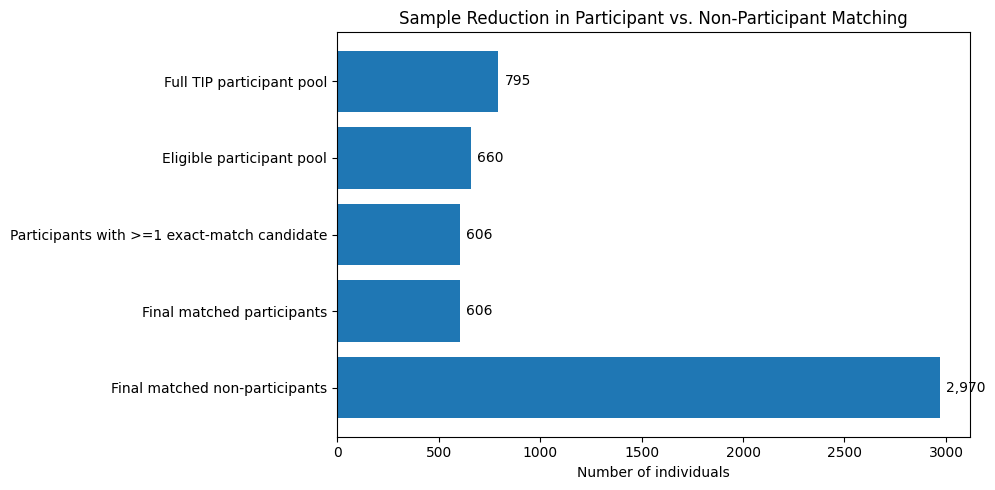

In [101]:
# --------------------------------------------------
# Block 1B: Plot simple sample-reduction chart
# --------------------------------------------------

import matplotlib.pyplot as plt

plot_df = sample_reduction_df.copy()

plt.figure(figsize=(10, 5))
plt.barh(plot_df["stage"], plot_df["count"])
plt.xlabel("Number of individuals")
plt.title("Sample Reduction in Participant vs. Non-Participant Matching")
plt.gca().invert_yaxis()

for i, v in enumerate(plot_df["count"]):
    plt.text(v + max(plot_df["count"]) * 0.01, i, f"{v:,}", va="center")

plt.tight_layout()
plt.show()

In [102]:
# --------------------------------------------------
# Block 2A: SMD for continuous variables
# --------------------------------------------------

smd_df = matched_outcome_df.copy()

continuous_vars = [
    "year_of_birth",
    "age_of_first_offense",
    "num_sentences_before_start",
    "num_offenses_before_start",
    "earnings_1yr_preTIP",
    "earnings_2yr_preTIP",
    "log_earnings_1yr_preTIP",
    "log_earnings_2yr_preTIP",
    "psm_distance"
]

def compute_smd_continuous(df, var, treat_col="treatment"):
    temp = df[[treat_col, var]].copy()
    temp[var] = pd.to_numeric(temp[var], errors="coerce")
    temp = temp.dropna()

    treat = temp[temp[treat_col] == 1][var]
    control = temp[temp[treat_col] == 0][var]

    mean_t = treat.mean()
    mean_c = control.mean()

    sd_t = treat.std(ddof=1)
    sd_c = control.std(ddof=1)

    pooled_sd = np.sqrt((sd_t**2 + sd_c**2) / 2)
    smd = np.nan if pooled_sd == 0 else (mean_t - mean_c) / pooled_sd

    return {
        "variable": var,
        "type": "continuous",
        "mean_treatment": mean_t,
        "mean_control": mean_c,
        "smd": smd,
        "abs_smd": abs(smd) if pd.notna(smd) else np.nan
    }

smd_cont_results = pd.DataFrame([
    compute_smd_continuous(smd_df, var)
    for var in continuous_vars
    if var in smd_df.columns
])

print(smd_cont_results.sort_values("abs_smd", ascending=False))

                     variable        type  mean_treatment  mean_control  \
8                psm_distance  continuous        0.000000      0.436489   
0               year_of_birth  continuous     1993.815182   1993.380135   
3   num_offenses_before_start  continuous        2.896040      2.793266   
4         earnings_1yr_preTIP  continuous     7089.056168   6851.775055   
2  num_sentences_before_start  continuous        2.678218      2.607071   
6     log_earnings_1yr_preTIP  continuous        4.036423      4.076813   
7     log_earnings_2yr_preTIP  continuous        3.347884      3.382027   
1        age_of_first_offense  continuous       22.506601     22.545118   
5         earnings_2yr_preTIP  continuous     4963.941486   4905.799133   

        smd   abs_smd  
8 -0.804740  0.804740  
0  0.051543  0.051543  
3  0.021685  0.021685  
4  0.017983  0.017983  
2  0.015049  0.015049  
6 -0.008918  0.008918  
7 -0.007866  0.007866  
1 -0.006108  0.006108  
5  0.005526  0.005526  


In [103]:
# --------------------------------------------------
# Block 2B: SMD for binary variables
# --------------------------------------------------

binary_vars = [
    "cohort_2022",
    "any_high_ogs_before_start",
    "job_right_before_tip",
    "employment_outcome",
    "offense_outcome",
    "recidivism_outcome"
]

def compute_smd_binary(df, var, treat_col="treatment"):
    temp = df[[treat_col, var]].copy()
    temp[var] = pd.to_numeric(temp[var], errors="coerce")
    temp = temp.dropna()

    treat = temp[temp[treat_col] == 1][var]
    control = temp[temp[treat_col] == 0][var]

    p_t = treat.mean()
    p_c = control.mean()

    pooled_sd = np.sqrt((p_t * (1 - p_t) + p_c * (1 - p_c)) / 2)
    smd = np.nan if pooled_sd == 0 else (p_t - p_c) / pooled_sd

    return {
        "variable": var,
        "type": "binary",
        "mean_treatment": p_t,
        "mean_control": p_c,
        "smd": smd,
        "abs_smd": abs(smd) if pd.notna(smd) else np.nan
    }

smd_binary_results = pd.DataFrame([
    compute_smd_binary(smd_df, var)
    for var in binary_vars
    if var in smd_df.columns
])

print(smd_binary_results.sort_values("abs_smd", ascending=False))

                    variable    type  mean_treatment  mean_control       smd  \
3         employment_outcome  binary        0.806931      0.516162  0.645729   
5         recidivism_outcome  binary        0.077558      0.027273  0.227082   
4            offense_outcome  binary        0.112211      0.149832 -0.111667   
0                cohort_2022  binary        0.453795      0.442761  0.022189   
1  any_high_ogs_before_start  binary        0.384488      0.377778  0.013818   
2       job_right_before_tip  binary        0.458746      0.457576  0.002348   

    abs_smd  
3  0.645729  
5  0.227082  
4  0.111667  
0  0.022189  
1  0.013818  
2  0.002348  


In [104]:
# --------------------------------------------------
# Block 2C: SMD for categorical variables via dummies
# --------------------------------------------------

categorical_vars = ["gender", "race"]

cat_smd_rows = []

for var in categorical_vars:
    if var in smd_df.columns:
        dummies = pd.get_dummies(smd_df[var], prefix=var, dummy_na=False)
        temp_df = pd.concat([smd_df[["treatment"]], dummies], axis=1)

        for dummy_var in dummies.columns:
            res = compute_smd_binary(temp_df, dummy_var, treat_col="treatment")
            res["source_variable"] = var
            cat_smd_rows.append(res)

smd_categorical_results = pd.DataFrame(cat_smd_rows)

print(smd_categorical_results.sort_values(["source_variable", "abs_smd"], ascending=[True, False]))

         variable    type  mean_treatment  mean_control       smd   abs_smd  \
1     gender_Male  binary        0.871287      0.870034  0.003735  0.003735   
0   gender_Female  binary        0.127063      0.128283 -0.003656  0.003656   
2  gender_Unknown  binary        0.001650      0.001684 -0.000817  0.000817   
4    race_Unknown  binary        0.008251      0.008418 -0.001833  0.001833   
5      race_White  binary        0.094059      0.093939  0.000411  0.000411   
3      race_Black  binary        0.897690      0.897643  0.000154  0.000154   

  source_variable  
1          gender  
0          gender  
2          gender  
4            race  
5            race  
3            race  


In [105]:
# --------------------------------------------------
# Block 2D: Combine all SMD results
# --------------------------------------------------

smd_all_results = pd.concat(
    [smd_cont_results, smd_binary_results, smd_categorical_results],
    ignore_index=True
).sort_values("abs_smd", ascending=False).reset_index(drop=True)

def smd_flag(x):
    if pd.isna(x):
        return "NA"
    elif x < 0.1:
        return "Good (<0.1)"
    elif x < 0.2:
        return "Moderate (0.1-0.2)"
    else:
        return "Poor (>=0.2)"

smd_all_results["balance_flag"] = smd_all_results["abs_smd"].apply(smd_flag)

print(smd_all_results)

                      variable        type  mean_treatment  mean_control  \
0                 psm_distance  continuous        0.000000      0.436489   
1           employment_outcome      binary        0.806931      0.516162   
2           recidivism_outcome      binary        0.077558      0.027273   
3              offense_outcome      binary        0.112211      0.149832   
4                year_of_birth  continuous     1993.815182   1993.380135   
5                  cohort_2022      binary        0.453795      0.442761   
6    num_offenses_before_start  continuous        2.896040      2.793266   
7          earnings_1yr_preTIP  continuous     7089.056168   6851.775055   
8   num_sentences_before_start  continuous        2.678218      2.607071   
9    any_high_ogs_before_start      binary        0.384488      0.377778   
10     log_earnings_1yr_preTIP  continuous        4.036423      4.076813   
11     log_earnings_2yr_preTIP  continuous        3.347884      3.382027   
12        ag

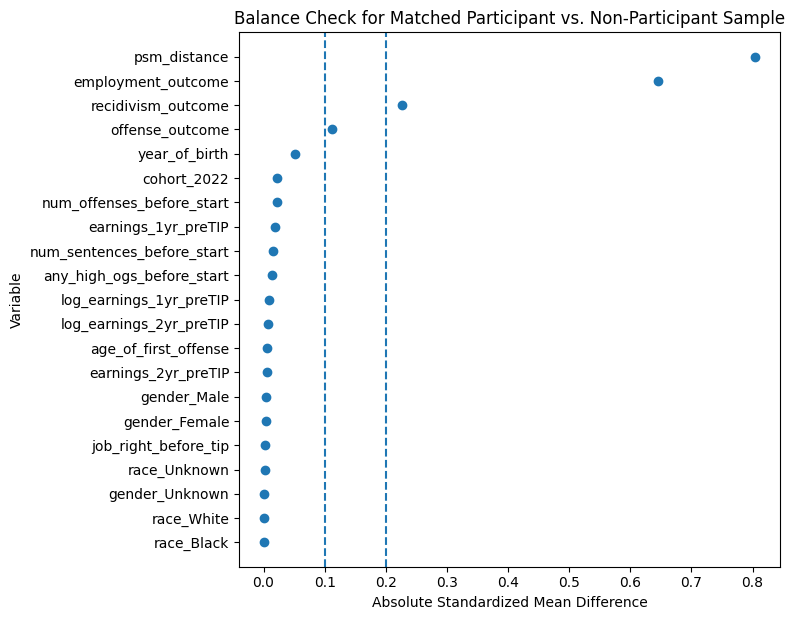

In [106]:
# --------------------------------------------------
# Block 2E: Love plot
# --------------------------------------------------

import matplotlib.pyplot as plt

plot_df = smd_all_results.dropna(subset=["abs_smd"]).copy()
plot_df = plot_df.sort_values("abs_smd", ascending=True)

plt.figure(figsize=(8, max(4, len(plot_df) * 0.3)))
plt.scatter(plot_df["abs_smd"], plot_df["variable"])
plt.axvline(0.1, linestyle="--")
plt.axvline(0.2, linestyle="--")
plt.xlabel("Absolute Standardized Mean Difference")
plt.ylabel("Variable")
plt.title("Balance Check for Matched Participant vs. Non-Participant Sample")
plt.tight_layout()
plt.show()

In [107]:
# --------------------------------------------------
# Block 3A: Build full TIP participant population and matched participant sample
# --------------------------------------------------

# Full TIP participant population
full_tip_participants = all_tip_data.loc[
    all_tip_data["Status"].isin(["Participant", "Graduated", "Non Graduated"])
].copy()

# Matched participant sample only
matched_participants = matched_outcome_df.loc[
    matched_outcome_df["treatment"] == 1
].copy()

# Keep only one row per participant
matched_participants = matched_participants.drop_duplicates(subset=["tip_id"]).copy()

# Make sure key columns are numeric
for df in [full_tip_participants, matched_participants]:
    if "cohort_2022" in df.columns:
        df["cohort_2022"] = pd.to_numeric(df["cohort_2022"], errors="coerce")
    if "earnings_1yr_preTIP" in df.columns:
        df["earnings_1yr_preTIP"] = pd.to_numeric(df["earnings_1yr_preTIP"], errors="coerce")
    if "num_offenses_before_start" in df.columns:
        df["num_offenses_before_start"] = pd.to_numeric(df["num_offenses_before_start"], errors="coerce")

In [108]:
# --------------------------------------------------
# Block 3B: Summary function for balance tables
# --------------------------------------------------

def participant_balance_summary(df):
    out = {}

    # % Black
    if "race" in df.columns:
        out["% Black participants"] = (df["race"].astype(str).str.contains("Black", case=False, na=False)).mean()

    # % Male
    if "gender" in df.columns:
        out["% Male participants"] = (df["gender"].astype(str).str.contains("Male", case=False, na=False)).mean()

    # % 24 years or younger
    if "Age_at_start" in df.columns:
        df["Age_at_start"] = pd.to_numeric(df["Age_at_start"], errors="coerce")
        out["% 24 years or younger"] = (df["Age_at_start"] <= 24).mean()

    # Average earnings 1 year pre-TIP
    if "earnings_1yr_preTIP" in df.columns:
        out["Average earnings 1 year pre-TIP"] = df["earnings_1yr_preTIP"].mean()

    # % with offense prior to TIP
    if "num_offenses_before_start" in df.columns:
        out["% with an offense prior to TIP"] = (df["num_offenses_before_start"] > 0).mean()

    return pd.Series(out)

In [109]:
# --------------------------------------------------
# Block 3C: Build cohort-specific balance tables
# --------------------------------------------------

# Pre-2022
full_pre22 = full_tip_participants[full_tip_participants["cohort_2022"] == 0].copy()
matched_pre22 = matched_participants[matched_participants["cohort_2022"] == 0].copy()

pre22_balance_table = pd.concat(
    [
        participant_balance_summary(full_pre22).rename("Full TIP participant population"),
        participant_balance_summary(matched_pre22).rename("Matched participant sample")
    ],
    axis=1
)

print("\n===== Pre-2022 balance table =====")
print(pre22_balance_table)

# Post-2022
full_post22 = full_tip_participants[full_tip_participants["cohort_2022"] == 1].copy()
matched_post22 = matched_participants[matched_participants["cohort_2022"] == 1].copy()

post22_balance_table = pd.concat(
    [
        participant_balance_summary(full_post22).rename("Full TIP participant population"),
        participant_balance_summary(matched_post22).rename("Matched participant sample")
    ],
    axis=1
)

print("\n===== Post-2022 balance table =====")
print(post22_balance_table)


===== Pre-2022 balance table =====
                                 Full TIP participant population  \
% Black participants                                    0.851765   
% Male participants                                     0.952941   
% 24 years or younger                                   0.355294   
Average earnings 1 year pre-TIP                      7548.217397   
% with an offense prior to TIP                          0.552941   

                                 Matched participant sample  
% Black participants                               0.879154  
% Male participants                                1.000000  
% 24 years or younger                                   NaN  
Average earnings 1 year pre-TIP                 6029.478161  
% with an offense prior to TIP                     0.728097  

===== Post-2022 balance table =====
                                 Full TIP participant population  \
% Black participants                                    0.856757   
% Male par

In [110]:
# --------------------------------------------------
# Block 3D: Format balance tables for display
# --------------------------------------------------

def format_balance_table(df):
    out = df.copy()

    for idx in out.index:
        if "%" in idx:
            out.loc[idx] = (out.loc[idx] * 100).round(1).astype(str) + "%"
        else:
            out.loc[idx] = out.loc[idx].round(0)

    return out

pre22_balance_table_fmt = format_balance_table(pre22_balance_table)
post22_balance_table_fmt = format_balance_table(post22_balance_table)

print("\n===== Formatted Pre-2022 balance table =====")
print(pre22_balance_table_fmt)

print("\n===== Formatted Post-2022 balance table =====")
print(post22_balance_table_fmt)


===== Formatted Pre-2022 balance table =====
                                Full TIP participant population  \
% Black participants                                      85.2%   
% Male participants                          95.29411764705881%   
% 24 years or younger                       35.529411764705884%   
Average earnings 1 year pre-TIP                     7548.217397   
% with an offense prior to TIP              55.294117647058826%   

                                Matched participant sample  
% Black participants                                 87.9%  
% Male participants                                 100.0%  
% 24 years or younger                                 nan%  
Average earnings 1 year pre-TIP                6029.478161  
% with an offense prior to TIP          72.80966767371602%  

===== Formatted Post-2022 balance table =====
                                Full TIP participant population  \
% Black participants                                      85.7%   
% Ma

C:\Users\13429\AppData\Local\Temp\ipykernel_27752\1651098544.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '85.2%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  out.loc[idx] = (out.loc[idx] * 100).round(1).astype(str) + "%"
C:\Users\13429\AppData\Local\Temp\ipykernel_27752\1651098544.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '87.9%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  out.loc[idx] = (out.loc[idx] * 100).round(1).astype(str) + "%"
C:\Users\13429\AppData\Local\Temp\ipykernel_27752\1651098544.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '85.7%' has dtype incompatible with float64, please explicitly cast to a compatible dtyp

In [111]:
# --------------------------------------------------
# Block 4: Export outputs
# --------------------------------------------------

sample_reduction_df.to_csv("sample_reduction_df.csv", index=False)
smd_all_results.to_csv("matched_sample_smd_table.csv", index=False)
pre22_balance_table.to_csv("pre22_participant_balance_table.csv")
post22_balance_table.to_csv("post22_participant_balance_table.csv")